# 有机锂中间体稳定性预测：全局 Arrhenius 方法

## 概述

**输入**: SMILES + 操作温度  
**输出**: t_max（最优停留时间）, t½（半衰期）, 反应器推荐（flash/flow/batch）

### 方法演变

| 版本 | 方法 | 局限 |
|---|---|---|
| v1 (旧) | 逐温度拟合 k_f, k_d → Arrhenius Ea_d → 描述符预测 Ea_d | Ea-lnA 补偿导致 t½ 不准; k_f 在高温不稳定 |
| **v2 (本 notebook)** | **全局 Arrhenius: 所有温度同时拟合 5 参数** → 类别特异描述符 | 数据量仍有限 (每类 7-8 个化合物) |

### 核心公式

$$\text{yield}(t_R, T) = y_{\max} \times \underbrace{(1 - e^{-k_f(T) \cdot t_R})}_{\text{生成}} \times \underbrace{e^{-k_d(T) \cdot t_R}}_{\text{分解}}$$

$$k_f(T) = A_f \cdot e^{-E_{a,f}/RT}, \quad k_d(T) = A_d \cdot e^{-E_{a,d}/RT}$$

$$t_{\max} = \frac{\ln(k_f/k_d)}{k_f - k_d}, \quad t_{1/2} = \frac{\ln 2}{k_d}$$


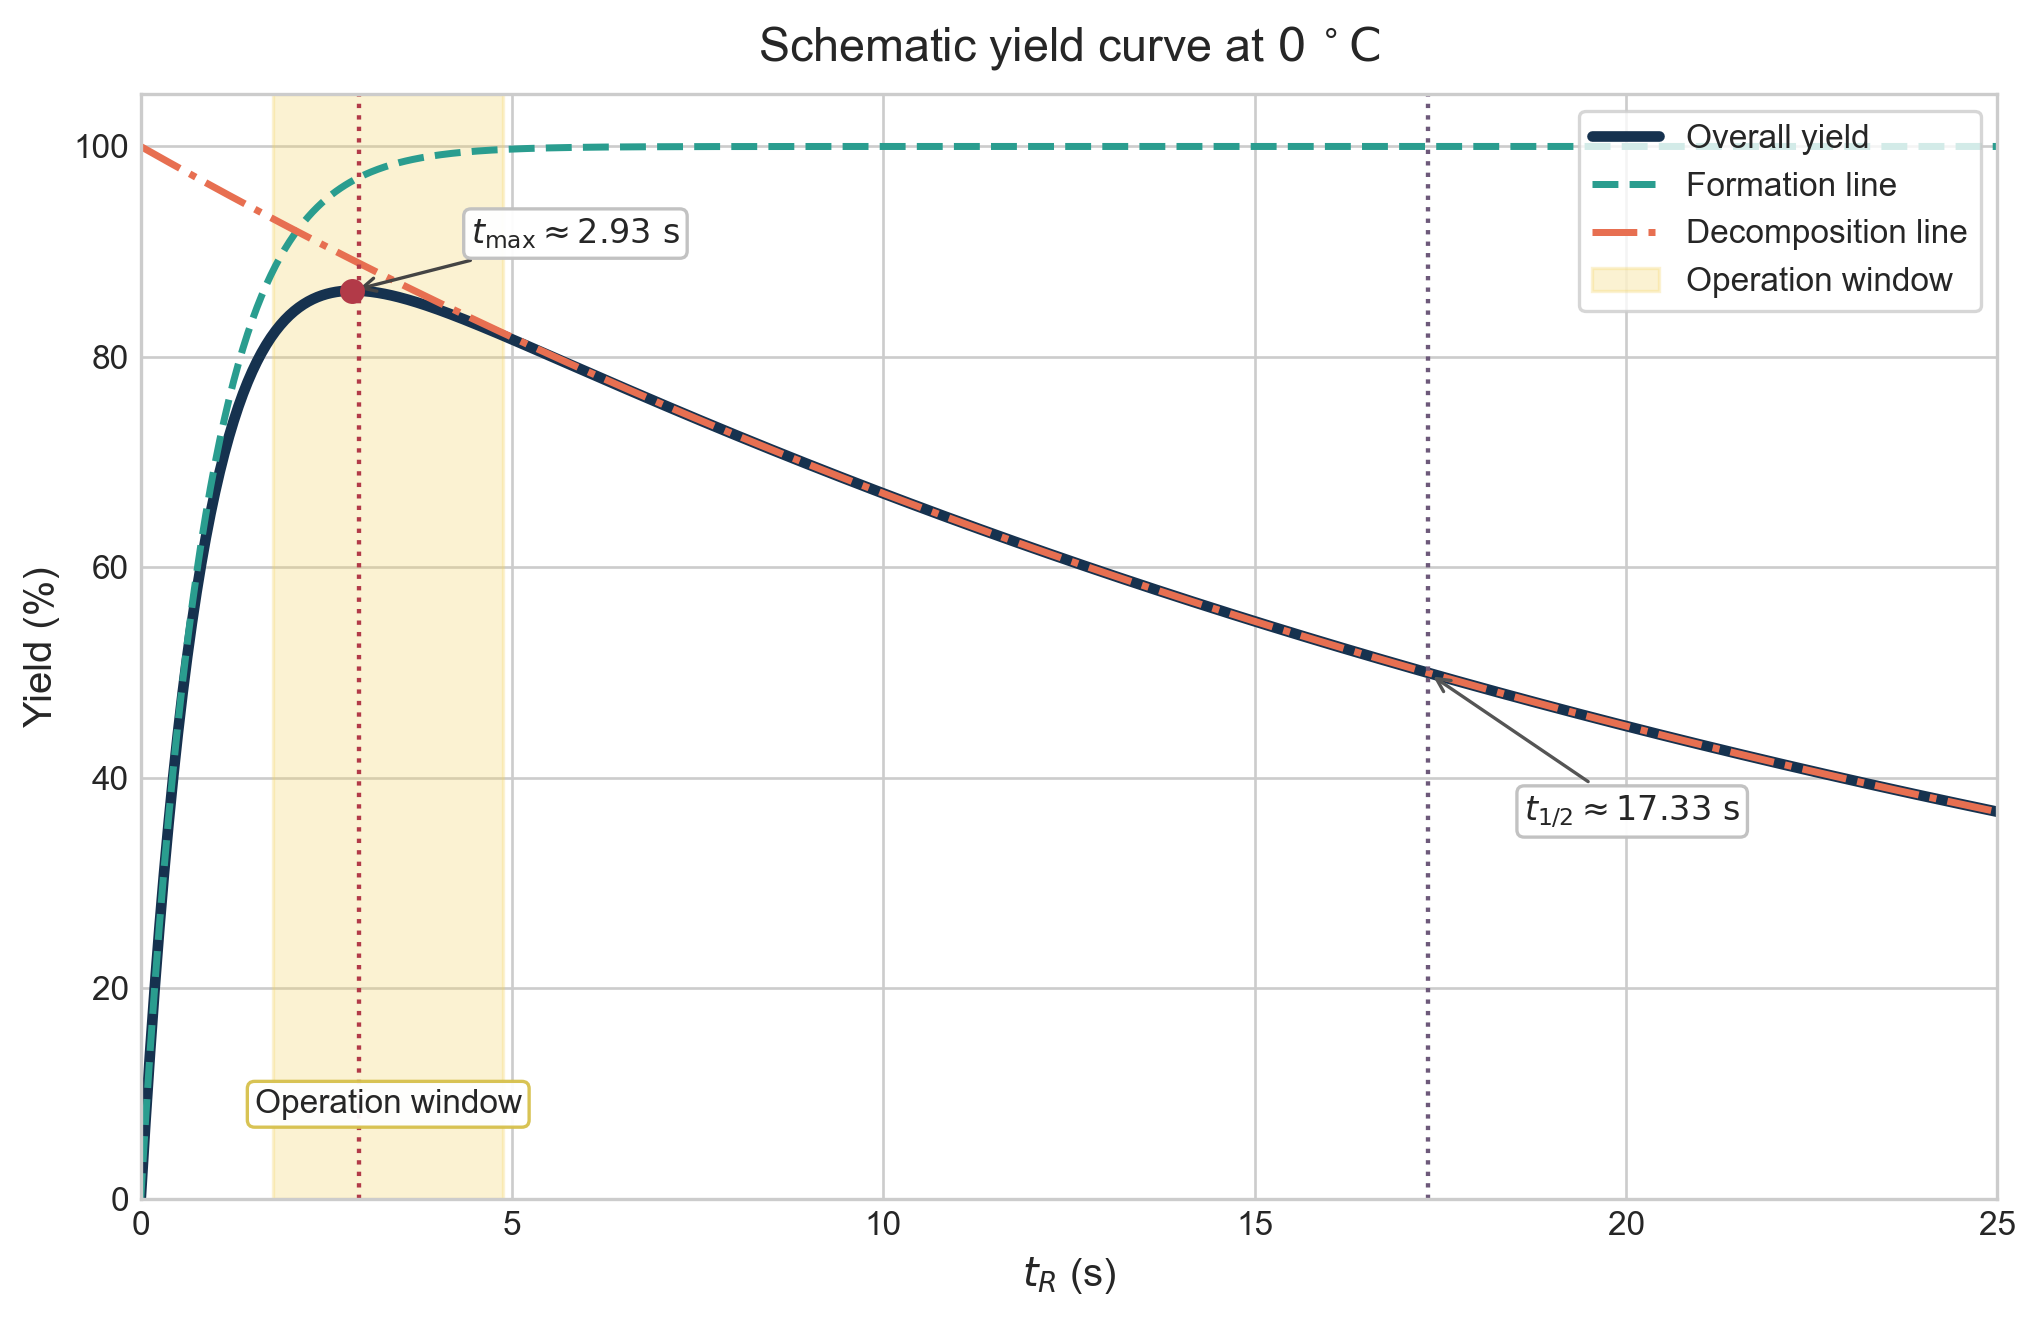

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

root = Path("/Users/zhaowenyuan/Projects/FlowFigTabMiner")
out_dir = root / "data/final_output/dataset_comparison"
out_dir.mkdir(parents=True, exist_ok=True)

T_c = 0.0
y_max = 100.0
kf = 1.20
kd = 0.040

tr = np.linspace(0, 25, 800)
formation = 1 - np.exp(-kf * tr)
decomposition = np.exp(-kd * tr)
yield_pct = y_max * formation * decomposition
t_max = np.log(kf / kd) / (kf - kd)
t_half = np.log(2) / kd
peak_idx = np.argmax(yield_pct)
peak_t = tr[peak_idx]
peak_y = yield_pct[peak_idx]
mask = yield_pct >= 0.95 * peak_y
left = tr[np.argmax(mask)]
right = tr[len(mask) - np.argmax(mask[::-1]) - 1]

plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8.6, 5.6), dpi=240)
ax.plot(tr, yield_pct, color="#16324f", lw=3.2, label="Overall yield")
ax.plot(tr, y_max * formation, color="#2a9d8f", lw=2.1, ls="--", label="Formation line")
ax.plot(tr, y_max * decomposition, color="#e76f51", lw=2.1, ls="-.", label="Decomposition line")
ax.axvspan(left, right, color="#f4d35e", alpha=0.28, label="Operation window")
ax.axvline(t_max, color="#b23a48", lw=1.3, ls=":")
ax.axvline(t_half, color="#6d597a", lw=1.3, ls=":")
ax.scatter([peak_t], [peak_y], color="#b23a48", s=42, zorder=5)
# 第一行：修正 \max 和 \mathrm 的花括号
ax.annotate(rf'$t_{{\max}} \approx {t_max:.2f}\ \mathrm{{s}}$', 
            xy=(peak_t, peak_y), xytext=(peak_t + 1.6, peak_y + 4.5), 
            arrowprops=dict(arrowstyle='->', lw=1.0, color='#444'), 
            fontsize=10, bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='#c0c0c0', alpha=0.96))

# 第二行：修正 t_{1/2} 的花括号，并确保计算 y 轴位置的逻辑正确
ax.annotate(rf'$t_{{1/2}} \approx {t_half:.2f}\ \mathrm{{s}}$', 
            xy=(t_half, y_max * np.exp(-kd * t_half)), xytext=(t_half + 1.3, 36), 
            arrowprops=dict(arrowstyle='->', lw=1.0, color='#555'), 
            fontsize=10, bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='#c0c0c0', alpha=0.96))

# 第三行：虽然没有 LaTeX 错误，但确保变量 left 和 right 已定义
ax.text((left + right)/2, 9, 'Operation window', 
        ha='center', va='center', fontsize=10, 
        bbox=dict(boxstyle='round,pad=0.22', fc='white', ec='#d6c04b', alpha=0.95))
ax.set_xlim(0, 25)
ax.set_ylim(0, 105)
ax.set_xlabel(r'$t_R$ (s)', fontsize=12)
ax.set_ylabel('Yield (%)', fontsize=12)
ax.set_title(r'Schematic yield curve at $0\,^\circ\mathrm{C}$', fontsize=14, pad=10)
ax.legend(frameon=True, fontsize=10, loc='upper right')
fig.tight_layout()
# fig.savefig(out_dir / "yield_tr_0C_schematic_clean.png", bbox_inches='tight')
# fig.savefig(out_dir / "yield_tr_0C_schematic_clean.pdf", bbox_inches='tight')
# plt.close(fig)
plt.show()


## Step 1: 读取原始数据

数据来自 Nagaki/Yoshida 等 12 篇流动化学文献 [De Gennaro 2014]。  
原始数据在 `dataset-manual-corrected.numbers` 中 (Apple Numbers 格式)，也可用 CSV 备份。

每行 = 一个实验点: 中间体 + 亲电体 + 温度 T + 停留时间 tR → 产率 yield%


In [2]:
# ===== 1.1 导入依赖 =====
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut
from rdkit import Chem
from rdkit.Chem import Draw, Descriptors
from collections import defaultdict
from itertools import combinations
import json, warnings, os
warnings.filterwarnings('ignore')

# 设置绘图参数
plt.rcParams['font.size'] = 18
plt.rcParams['figure.dpi'] = 200

print("依赖加载完成 ✓")


依赖加载完成 ✓


In [3]:
# ===== 1.2 读取数据 =====
# 优先从 .numbers 文件读取（需要 pip install numbers-parser）
# 如果不可用，从 CSV 备份读取

DATA_DIR = '.'  # 在 data/ml_lifetime/ 目录下运行
CSV_FILE = os.path.join(DATA_DIR, 'clean_organolithium_unified_descriptors.csv')
NUMBERS_FILE = os.path.join(DATA_DIR, 'dataset-manual-corrected.numbers')

try:
    import numbers_parser
    doc = numbers_parser.Document(NUMBERS_FILE)
    table = doc.sheets[0].tables[0]
    headers = [str(table.cell(0, c).value) for c in range(table.num_cols)]
    rows = []
    for r in range(1, table.num_rows):
        row = {headers[c]: table.cell(r, c).value for c in range(table.num_cols)}
        rows.append(row)
    df = pd.DataFrame(rows)
    print(f"✓ 从 .numbers 读取: {df.shape[0]} 行 × {df.shape[1]} 列")
except Exception as e:
    df = pd.read_csv(CSV_FILE)
    print(f"✓ 从 CSV 读取: {df.shape[0]} 行 × {df.shape[1]} 列")

# 类型转换（.numbers 读出来可能是字符串）
for col in ['tR1_s', 'T1_C', 'tR2_s', 'T2_C', 'yield_pct']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 基本统计
print(f"\n化合物数: {df['intermediate_smiles_canonical'].nunique()}")
print(f"论文数:   {df['paper_id'].nunique()}")
print(f"温度范围: {df['T1_C'].min():.0f} ~ {df['T1_C'].max():.0f} °C")
print(f"tR 范围:  {df['tR1_s'].min():.4f} ~ {df['tR1_s'].max():.1f} s")
print(f"\n类别分布:")
print(df['intermediate_class'].value_counts())


✓ 从 CSV 读取: 2357 行 × 50 列

化合物数: 75
论文数:   25
温度范围: -85 ~ 25 °C
tR 范围:  0.0013 ~ 95.2 s

类别分布:
intermediate_class
ArLi                1643
oxiranylLi           486
alkylLi               57
benzylLi              50
carbenoid             45
perfluoroalkylLi      28
aziridinylLi          24
vinylLi               18
carbanion              6
Name: count, dtype: int64


## Step 2: 数据可视化 — yield vs tR 曲线

选 3 个代表化合物展示不同稳定性:
- **不稳定**: yield 快速上升又下降 → 需要 flash mixer
- **中等**: 低温平坦，高温才出现衰减 → flow reactor
- **稳定**: 所有温度产率平坦 → batch 操作

颜色从蓝（低温）到红（高温）。


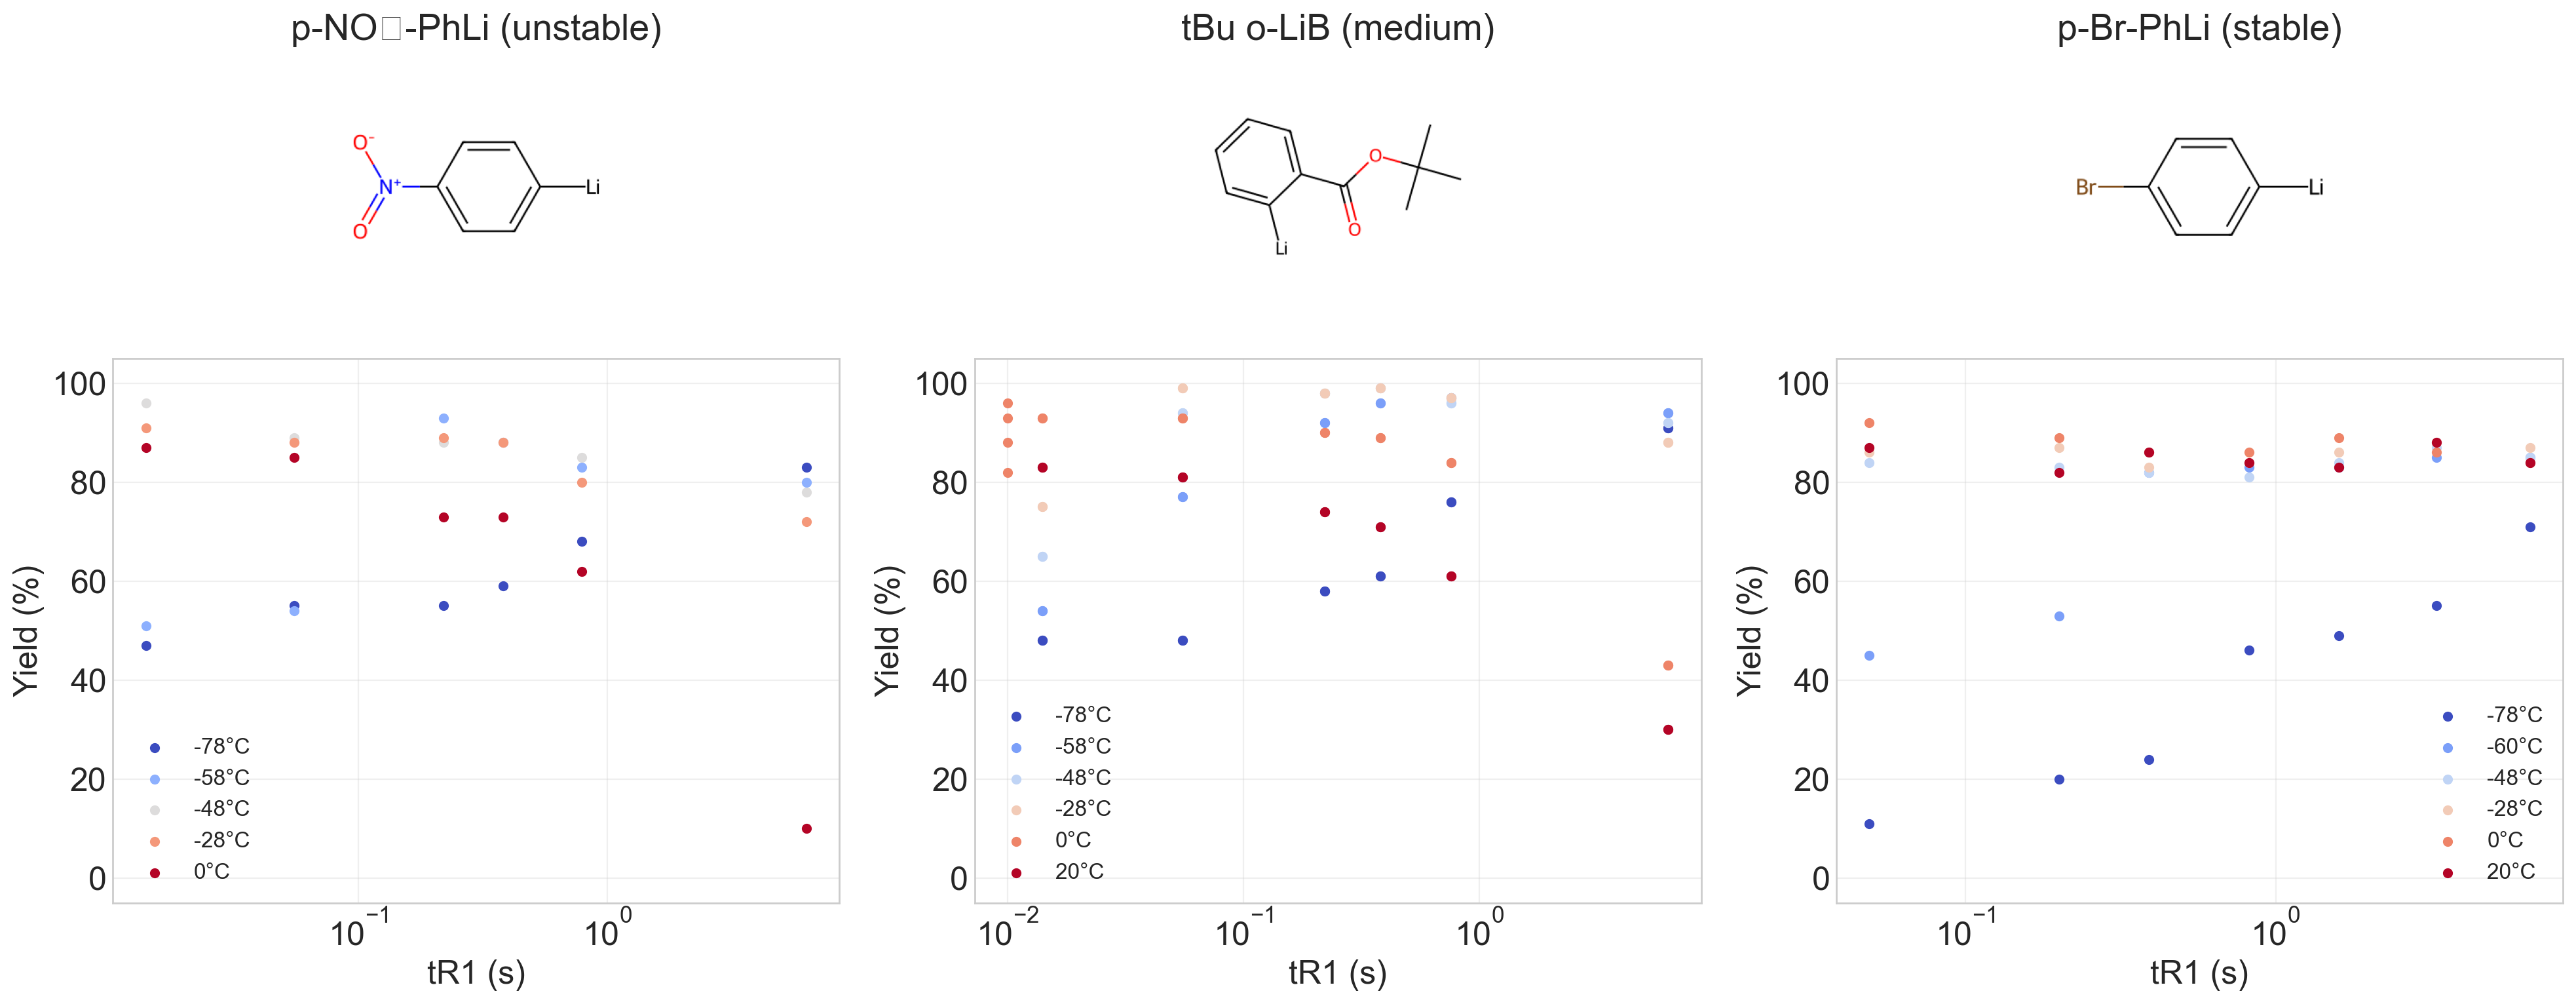

观察:
  左: 高温(红)产率先升后降 → 不稳定, 需要精确控制 tR
  中: 低温平坦, 只在高温出现衰减 → 中等稳定
  右: 所有温度全程平坦 → 在实验窗口内很稳定


In [4]:
# ===== 2.1 典型化合物的 yield-tR 曲线 =====
# 只用甲醇淬灭数据（最可靠的动力学探针）
methanol = df[df['electrophile'].str.contains('methanol', na=False, case=False)]

examples = {
    'p-NO₂-PhLi (unstable)': '[Li]c1ccc([N+](=O)[O-])cc1',
    'tBu o-LiB (medium)':    '[Li]c1ccccc1C(=O)OC(C)(C)C',
    'p-Br-PhLi (stable)':    '[Li]c1ccc(Br)cc1',
}

fig, axes = plt.subplots(2, 3, figsize=(20, 8), gridspec_kw={'height_ratios': [1, 2]})
for idx, (label, smi) in enumerate(examples.items()):
    ax_mol = axes[0, idx]
    ax = axes[1, idx]
    
    # Draw molecule
    mol = Chem.MolFromSmiles(smi)
    if mol:
        img = Draw.MolToImage(mol)
        ax_mol.imshow(img)
    ax_mol.axis('off')
    ax_mol.set_title(label, fontsize=20)

    sub = methanol[methanol['intermediate_smiles_canonical'] == smi]
    if len(sub) == 0:  # 如果甲醇数据不够，用全部数据
        sub = df[df['intermediate_smiles_canonical'] == smi]
    
    temps = sorted(sub['T1_C'].dropna().unique())
    clrs = plt.cm.coolwarm(np.linspace(0, 1, len(temps)))
    
    for T, c in zip(temps, clrs):
        t_data = sub[sub['T1_C'] == T].sort_values('tR1_s')
        ax.scatter(t_data['tR1_s'], t_data['yield_pct'], c=[c], s=20, label=f'{T:.0f}°C')
    
    ax.set_xscale('log')
    ax.set_xlabel('tR1 (s)'); ax.set_ylabel('Yield (%)')
    ax.legend(fontsize=12, loc='best')
    ax.set_ylim(-5, 105); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("观察:")
print("  左: 高温(红)产率先升后降 → 不稳定, 需要精确控制 tR")
print("  中: 低温平坦, 只在高温出现衰减 → 中等稳定")
print("  右: 所有温度全程平坦 → 在实验窗口内很稳定")


## Step 3: 全局 Arrhenius 拟合 — 核心新方法

### 为什么不逐温度拟合？

逐温度拟合的问题: 当 $k_f \gg k_d$ 时（高温），yield 曲线对 $k_f$ 不敏感——$k_f = 100$ 和 $k_f = 100000$ 给出几乎相同的曲线。导致 $k_f$ 不可靠（出现负 $E_{a,f}$）。

### 全局拟合的思想

将一个化合物在**所有温度**（通常 4-9 个）的 yield-vs-tR 数据**同时拟合**到 5 个参数:

| 参数 | 物理意义 |
|---|---|
| $E_{a,f}$ | 生成活化能 (卤素-金属交换) |
| $\ln A_f$ | 生成前指因子 |
| $E_{a,d}$ | 分解活化能 (中间体热分解) |
| $\ln A_d$ | 分解前指因子 |
| $y_{\max}$ | 理论最大产率 |

低温数据约束 $k_f$（生成慢），高温数据约束 $k_d$（分解快），**互相补充**。


In [5]:
# ===== 3.1 定义全局 Arrhenius 模型 =====
R_gas = 8.314e-3  # kJ/(mol·K)

def global_model(X, Ea_f, lnA_f, Ea_d, lnA_d, y_max):
    """
    全局 Arrhenius 模型
    
    参数:
        X: [tR, T_K] 的 2×N 数组
        Ea_f, lnA_f: 生成反应的 Arrhenius 参数
        Ea_d, lnA_d: 分解反应的 Arrhenius 参数
        y_max: 理论最大产率 (%)
    
    返回:
        yield(%) 的 N 维数组
    """
    tR, T_K = X[0], X[1]
    with np.errstate(over='ignore', under='ignore'):
        k_f = np.exp(lnA_f - Ea_f / (R_gas * T_K))  # 生成速率
        k_d = np.exp(lnA_d - Ea_d / (R_gas * T_K))  # 分解速率
        formation = 1.0 - np.exp(-k_f * tR)           # 生成项
        decay = np.exp(-k_d * tR)                       # 分解项
    return y_max * formation * decay

print("全局模型定义完成 ✓")
print("yield(tR, T) = y_max × (1 - exp(-k_f(T)·tR)) × exp(-k_d(T)·tR)")
print("k_f(T) = exp(lnA_f - Ea_f/RT)")
print("k_d(T) = exp(lnA_d - Ea_d/RT)")


全局模型定义完成 ✓
yield(tR, T) = y_max × (1 - exp(-k_f(T)·tR)) × exp(-k_d(T)·tR)
k_f(T) = exp(lnA_f - Ea_f/RT)
k_d(T) = exp(lnA_d - Ea_d/RT)


In [6]:
# ===== 3.2 对每个化合物执行全局拟合 =====
# 只用 tR1 步骤的数据（中间体的生成+分解在同一步）
tr1 = df[df['tR_step'].str.startswith('tR1', na=False)].copy()

global_results = []
n_success, n_fail = 0, 0

for smi in tr1['intermediate_smiles_canonical'].unique():
    sub = tr1[tr1['intermediate_smiles_canonical'] == smi]
    name = sub['intermediate'].iloc[0]
    
    # 策略: 甲醇淬灭数据优先（最可靠）
    methanol_sub = sub[sub['electrophile'].str.contains('methanol', na=False, case=False)]
    if len(methanol_sub) >= 10:
        sub = methanol_sub
    
    # 至少需要 3 个温度
    temps = sub['T1_C'].dropna().unique()
    if len(temps) < 3:
        continue
    
    # 收集所有数据点
    tR_all = sub['tR1_s'].values.astype(float)
    T_K_all = sub['T1_C'].values.astype(float) + 273.15
    y_all = sub['yield_pct'].values.astype(float)
    
    # 过滤无效值
    valid = np.isfinite(tR_all) & np.isfinite(T_K_all) & np.isfinite(y_all) & (tR_all > 0)
    tR_all, T_K_all, y_all = tR_all[valid], T_K_all[valid], y_all[valid]
    if len(tR_all) < 10:
        continue
    
    # 拟合
    X_data = np.array([tR_all, T_K_all])
    y_max_est = min(np.max(y_all) * 1.05, 100)
    
    try:
        popt, pcov = curve_fit(
            global_model, X_data, y_all,
            p0=[30, 15, 40, 15, y_max_est],                    # 初始猜测
            bounds=([0, -10, 0, -10, 10], [150, 50, 150, 50, 110]),  # 物理约束
            maxfev=50000, method='trf'
        )
        Ea_f, lnA_f, Ea_d, lnA_d, y_max = popt
        
        # 计算 R²
        y_pred = global_model(X_data, *popt)
        ss_res = np.sum((y_all - y_pred)**2)
        ss_tot = np.sum((y_all - np.mean(y_all))**2)
        r2 = 1 - ss_res/ss_tot if ss_tot > 0 else 0
        
        # 只保留物理合理的结果
        if r2 > 0.3 and Ea_f > 0 and Ea_d > 0:
            global_results.append({
                'intermediate': name, 'smi': smi,
                'Ea_f': round(Ea_f, 2), 'lnA_f': round(lnA_f, 2),
                'Ea_d': round(Ea_d, 2), 'lnA_d': round(lnA_d, 2),
                'y_max': round(y_max, 1), 'r2_global': round(r2, 4),
                'n_points': len(tR_all), 'n_temps': len(temps),
            })
            n_success += 1
        else:
            n_fail += 1
    except Exception as e:
        n_fail += 1

global_df = pd.DataFrame(global_results).sort_values('Ea_d')

print(f"=== 全局拟合结果 ===")
print(f"成功: {n_success} 化合物,  失败: {n_fail}")
print(f"R² 中位数: {global_df['r2_global'].median():.3f}")
print(f"R² 范围:   {global_df['r2_global'].min():.3f} ~ {global_df['r2_global'].max():.3f}")
print(f"Ea_f 范围: {global_df['Ea_f'].min():.1f} ~ {global_df['Ea_f'].max():.1f} kJ/mol (全部>0 ✓)")
print(f"Ea_d 范围: {global_df['Ea_d'].min():.1f} ~ {global_df['Ea_d'].max():.1f} kJ/mol")

# 展示前 10 个
global_df[['intermediate','Ea_f','Ea_d','lnA_f','lnA_d','r2_global','n_temps']].head(10)


=== 全局拟合结果 ===
成功: 45 化合物,  失败: 3
R² 中位数: 0.879
R² 范围:   0.438 ~ 0.993
Ea_f 范围: 0.0 ~ 72.1 kJ/mol (全部>0 ✓)
Ea_d 范围: 4.4 ~ 132.5 kJ/mol


,intermediate,Ea_f,Ea_d,lnA_f,lnA_d,r2_global,n_temps
17,p-propanoylbenzyllithium,18.03,4.42,22.85,-1.25,0.8591,5
42,2-pyridyllithium,18.99,19.73,11.66,7.02,0.8002,5
16,p-formylbenzyllithium,0.05,20.30,16.32,7.27,0.6114,5
22,m-cyanophenyllithium,34.69,27.30,22.11,9.08,0.9661,6
24,p-cyanophenyllithium,35.78,28.83,22.52,9.88,0.9036,6
12,3-(oxiran-2-yl)propyllithium,22.00,30.33,19.22,13.01,0.8412,5
19,"monolithiated 4,4'-dibromobiphenyl",20.33,38.00,13.97,9.33,0.9497,4
21,fluoroiodomethyllithium,7.22,38.85,8.91,19.33,0.9302,4
0,tert-butyl o-lithiobenzoate,17.19,39.58,13.65,15.04,0.6491,6
4,methyl m-lithiobenzoate,32.53,44.90,25.42,24.42,0.9354,5


## Step 4: 从 5 参数计算任意温度的 t_max, t½, 反应器推荐

有了 5 参数后，在**任意温度 T** 都可以计算:
- $t_{\max}$: 最优停留时间（产率峰值位置）
- $t_{1/2}$: 中间体半衰期
- 反应器类型: flash (<0.1s) / flow (0.1-60s) / batch (>60s)

**反应器边界基于设备物理限制，不随温度变化。温度改变的是 t_max 本身。**


In [7]:
# ===== 4.1 辅助函数 =====

def calc_tmax(Ea_f, lnA_f, Ea_d, lnA_d, T_C):
    """计算给定温度下的 t_max (最优停留时间)"""
    T_K = T_C + 273.15
    k_f = np.exp(lnA_f - Ea_f / (R_gas * T_K))
    k_d = np.exp(lnA_d - Ea_d / (R_gas * T_K))
    if k_f <= k_d or k_f <= 0 or k_d <= 0:
        return 1e6  # 无峰值 → batch
    return np.log(k_f / k_d) / (k_f - k_d)

def calc_thalf(Ea_d, lnA_d, T_C):
    """计算给定温度下的 t½ (分解半衰期)"""
    T_K = T_C + 273.15
    k_d = np.exp(lnA_d - Ea_d / (R_gas * T_K))
    return np.log(2) / k_d if k_d > 0 else 1e10

def classify_reactor(t):
    """根据 t_max 推荐反应器类型"""
    if t < 0.1:   return 'flash'   # 微混合器 (<100ms)
    elif t < 60:  return 'flow'    # 管式反应器 (0.1s - 1min)
    else:         return 'batch'   # 常规操作 (>1min)

def format_time(t):
    """格式化时间显示"""
    if t >= 86400: return f"{t/86400:.1f}d"
    if t >= 3600:  return f"{t/3600:.1f}h"
    if t >= 60:    return f"{t/60:.0f}min"
    if t >= 0.1:   return f"{t:.2f}s"
    return f"{t*1000:.1f}ms"

print("辅助函数定义完成 ✓")


辅助函数定义完成 ✓


In [8]:
# ===== 4.2 展示每个化合物在 4 个温度下的推荐 =====
# 这是"查表工具": 已知化合物直接从 5 参数计算

print(f"{'化合物':25s} {'Ea_f':>5s} {'Ea_d':>5s} {'R²':>5s} │", end='')
for T in [-78, -40, 0, 25]:
    print(f" {T:>5d}°C", end='')
print()
print("=" * 90)

for _, r in global_df[global_df['r2_global'] > 0.6].head(20).iterrows():
    print(f"{r['intermediate'][:25]:25s} {r['Ea_f']:5.1f} {r['Ea_d']:5.1f} {r['r2_global']:5.3f} │", end='')
    for T in [-78, -40, 0, 25]:
        tm = calc_tmax(r['Ea_f'], r['lnA_f'], r['Ea_d'], r['lnA_d'], T)
        rc = classify_reactor(tm)
        print(f" {rc:>5s}", end='')
    print()

# 统计各温度分布
print(f"\n各温度的 flash/flow/batch 分布:")
reliable = global_df[global_df['r2_global'] > 0.6]
for T in [-78, -40, 0, 25]:
    reactors = [classify_reactor(calc_tmax(r['Ea_f'],r['lnA_f'],r['Ea_d'],r['lnA_d'],T)) for _,r in reliable.iterrows()]
    print(f"  T={T:>5d}°C: flash={reactors.count('flash'):2d}, flow={reactors.count('flow'):2d}, batch={reactors.count('batch'):2d}")


化合物                        Ea_f  Ea_d    R² │   -78°C   -40°C     0°C    25°C
p-propanoylbenzyllithium   18.0   4.4 0.859 │ flash flash flash flash
2-pyridyllithium           19.0  19.7 0.800 │  flow  flow  flow flash
p-formylbenzyllithium       0.1  20.3 0.611 │ flash flash flash flash
m-cyanophenyllithium       34.7  27.3 0.966 │  flow  flow flash flash
p-cyanophenyllithium       35.8  28.8 0.904 │  flow  flow flash flash
3-(oxiran-2-yl)propyllith  22.0  30.3 0.841 │ flash flash flash flash
monolithiated 4,4'-dibrom  20.3  38.0 0.950 │  flow  flow flash flash
fluoroiodomethyllithium     7.2  38.9 0.930 │  flow flash flash flash
tert-butyl o-lithiobenzoa  17.2  39.6 0.649 │  flow flash flash flash
methyl m-lithiobenzoate    32.5  44.9 0.935 │ flash flash flash flash
methyl p-lithiobenzoate     9.1  45.6 0.962 │ flash flash flash flash
methyl o-lithiobenzoate    67.3  47.5 0.847 │  flow flash flash flash
isopropyl o-lithiobenzoat  22.8  47.9 0.769 │  flow flash flash flash
2-bromo-2'-l

## Step 5: 结构分类 + 描述符准备

### 基于 SMILES 结构分类（不是名字！）

| 类别 | SMILES 特征 | 分解机制 |
|---|---|---|
| o-ArLi | `[Li]c1ccccc1X` | 苯炔消除 / 螯合 |
| m-ArLi | `[Li]c1cccc(X)c1` | THF 溶剂裂解 |
| p-ArLi | `[Li]c1ccc(X)cc1` | THF 溶剂裂解 |
| oxiranylLi | 含 `CO1` 环氧 | 环氧开环 |

### 描述符来源

所有描述符已在原始数据集中（用 GFN2-xTB 预计算），从 SMILES 计算只需秒级。


In [9]:
# ===== 5.1 结构分类函数 =====
def classify_structure(smi):
    """基于 SMILES 结构分类有机锂中间体"""
    smi = str(smi)
    # oxiranylLi: 含三元环氧
    if any(p in smi for p in ['CO1', 'C1CO1', 'OC1', 'C1OC1']):
        return 'oxiranylLi'
    # ortho: [Li]c1ccccc1X (Li 和 X 在苯环 1,2 位)
    if '[Li]c1ccccc1' in smi and smi != '[Li]c1ccccc1':
        return 'o-ArLi'
    # para: [Li]c1ccc(X)cc1
    if '[Li]c1ccc(' in smi:
        return 'p-ArLi'
    # meta: [Li]c1cccc(X)c1
    if '[Li]c1cccc(' in smi:
        return 'm-ArLi'
    # 杂环芳基锂
    if '[Li]c1' in smi:
        return 'hetero-ArLi'
    return 'other'

# ===== 5.2 提取描述符表 =====
# 描述符映射: 简称 → 数据集列名
int_desc = {
    'q_C': 'dft_charge_C_ipso',      # C-Li 碳上 Mulliken 电荷
    'd_LiC': 'dft_LiC_bond_A',       # Li-C 键长 (Å)
    'BDE': 'dft_LiC_BDE_kJ',         # Li-C 键离解能 (kJ/mol)
    '%Vbur': 'buried_vol_Li',         # Li 周围埋藏体积
    'Gsolv': 'dft_Gsolv_kJ',         # THF 溶剂化自由能
    'HOMO': 'dft_HOMO_eV',           # 最高占据轨道能量
    'eta': 'HOMO_LUMO_gap_eV',       # 化学硬度 (LUMO-HOMO)/2
    'fukui': 'fukui_f_minus_C',      # Fukui 亲核函数
    'B1': 'sterimol_B1',             # Sterimol 最小宽度
    'B5': 'sterimol_B5',             # Sterimol 最大宽度
    'L': 'sterimol_L',               # Sterimol 长度
    'vol': 'mol_volume',             # 分子体积
    'dipole': 'dft_dipole_D',        # 偶极矩
    'sigma': 'sigma_hammett',         # Hammett 取代基常数
}

# 描述符从 CSV 加载 (包含 50 列完整描述符)
# .numbers 只有 43 列 (缺 sterimol/fukui/mol_volume 等), 不能用于描述符建模
desc_csv = pd.read_csv('clean_organolithium_unified_descriptors.csv')
unique = desc_csv.drop_duplicates(subset='intermediate_smiles_canonical')
desc_table = unique[['intermediate', 'intermediate_smiles_canonical', 'intermediate_class'] +
                     list(int_desc.values())].copy()
for col in int_desc.values():
    desc_table[col] = pd.to_numeric(desc_table[col], errors='coerce')

# ===== 5.3 合并: 全局拟合参数 + 描述符 + 分类 =====
# 使用 global_arrhenius.csv 中经过验证的 Arrhenius 参数
# (Cell 9 的实时拟合因初始值/收敛差异可能导致参数微调，描述符模型基于 CSV 参数优化)
global_df_validated = pd.read_csv('global_arrhenius.csv')
model_data = global_df_validated.merge(desc_table, left_on='smi',
    right_on='intermediate_smiles_canonical', how='inner', suffixes=('', '_d'))
model_data['class'] = model_data['smi'].apply(classify_structure)

# 只用可靠拟合 (R² > 0.6) 且 Ea_d 合理 (< 140 kJ/mol)
model_data = model_data[(model_data['r2_global'] > 0.6) & (model_data['Ea_d'] < 140)]

print(f"建模数据: {len(model_data)} 化合物 (R²>0.6, Ea_d<140)")
print(f"\n类别分布:")
print(model_data['class'].value_counts())


建模数据: 40 化合物 (R²>0.6, Ea_d<140)

类别分布:
class
o-ArLi         8
m-ArLi         7
p-ArLi         7
oxiranylLi     7
other          6
hetero-ArLi    5
Name: count, dtype: int64


## Step 6: 模型诊断 — 一级 vs stretched decay

测试一级模型是否足够，还是需要更复杂的分解机制。

**Stretched decay**: $\text{yield} = y_{\max} (1-e^{-k_f t_R}) e^{-k_d t_R^\beta}$
- β = 1: 退化为一级
- β < 1: sub-exponential (慢于一级衰减，可能反映聚集态缓冲)
- β > 1: super-exponential (加速衰减)


In [10]:
# ===== 6.1 开关: 是否做 Tier 分层 =====
# ★★★ 用户控制: 设为 True 剔除 Tier A+B (非一级化合物), 设为 False 用全部 ★★★
ENABLE_TIER_FILTERING = True  # ← 改这里

# ===== 6.2 定义 stretched decay 模型 (用于演示) =====
def model_stretched(X, Ea_f, lnA_f, Ea_d, lnA_d, y_max, beta):
    """Stretched exponential decay: exp(-k_d * tR^beta)"""
    tR, T_K = X[0], X[1]
    with np.errstate(over='ignore', under='ignore'):
        k_f = np.exp(lnA_f - Ea_f / (R_gas * T_K))
        k_d = np.exp(lnA_d - Ea_d / (R_gas * T_K))
        tR_safe = np.maximum(tR, 1e-10)
        return y_max * (1.0 - np.exp(-k_f * tR)) * np.exp(-k_d * tR_safe**beta)

# ===== 6.3 从预计算文件加载 Tier 分层结果 =====
# Tier 分层基于一级 vs stretched decay 的 AIC 对比 (见 GLOBAL_ARRHENIUS_METHOD.md)
# 直接加载保证结果一致, 不受 .numbers vs CSV 数据差异影响
tier_df = pd.read_csv('model_comparison_L1_L2.csv')

# 标准化 tier 列 (去掉中文后缀, 只保留 Tier A/B/C)
tier_df['tier_clean'] = tier_df['tier'].apply(
    lambda x: 'Tier A' if 'Tier A' in x else ('Tier B' if 'Tier B' in x else 'Tier C'))

print(f"=== Tier 分布 ===")
print(tier_df['tier_clean'].value_counts())
print(f"\n=== Tier A (强 stretched decay, 剔除) ===")
for _, r in tier_df[tier_df['tier_clean']=='Tier A'].iterrows():
    print(f"  {r['name'][:35]:35s} β={r['beta']:.3f}  ΔAIC={r['dAIC']:.1f}")

if ENABLE_TIER_FILTERING:
    excluded_smi = set(tier_df[tier_df['tier_clean'].isin(['Tier A', 'Tier B'])]['smi'])
    n_a = len(tier_df[tier_df['tier_clean']=='Tier A'])
    n_b = len(tier_df[tier_df['tier_clean']=='Tier B'])
    print(f"\n✓ 已剔除 {n_a} 个 Tier A + {n_b} 个 Tier B = {len(excluded_smi)} 个化合物")
    print(f"  Tier B (中等 stretched, ΔAIC 2-10):")
    for _, r in tier_df[tier_df['tier_clean']=='Tier B'].iterrows():
        print(f"    {r['name'][:40]:40s} β={r['beta']:.2f}  ΔAIC={r['dAIC']:.1f}")
else:
    excluded_smi = set()
    print(f"\n⚠ 未剔除任何化合物 (ENABLE_TIER_FILTERING=False)")

# Final modeling_set (used by Step 7c visualizations)
modeling_set = model_data[~model_data['smi'].isin(excluded_smi)].copy()
print(f"\n建模集 (modeling_set): {len(modeling_set)} 化合物")


=== Tier 分布 ===
tier_clean
Tier C    35
Tier A     6
Tier B     5
Name: count, dtype: int64

=== Tier A (强 stretched decay, 剔除) ===
  3-(oxiran-2-yl)propyllithium        β=0.348  ΔAIC=16.2
  p-formylbenzyllithium               β=0.200  ΔAIC=50.7
  lithium carbenoid                   β=0.692  ΔAIC=12.6
  o-bromophenyllithium                β=0.365  ΔAIC=42.4
  2,3-dibromo-4-lithiopyridine        β=0.416  ΔAIC=24.3
  2-pyridyllithium                    β=0.308  ΔAIC=20.5

✓ 已剔除 6 个 Tier A + 5 个 Tier B = 11 个化合物
  Tier B (中等 stretched, ΔAIC 2-10):
    methyl m-lithiobenzoate                  β=0.62  ΔAIC=4.2
    tert-butyl m-lithiobenzoate              β=0.64  ΔAIC=4.0
    3-lithio-2-methylbenzothiophene          β=0.39  ΔAIC=2.2
    2-methylbenzofuran-3-yllithium           β=0.67  ΔAIC=2.1
    p-propanoylbenzyllithium                 β=0.51  ΔAIC=3.2

建模集 (modeling_set): 30 化合物


## Step 7c: 分类可视化 — 结构 + yield 曲线 + 描述符机制

本节生成论文最终的图：

1. **每类一张结构总览图** (4 张) — 展示每类的 Tier C 预测化合物
2. **每类一张 yield vs tR 曲线图** (4 张) — 全局 Arrhenius 模型的原始数据 + 拟合
3. **描述符-机制映射热图** (1 张) — 四类的描述符选择对比


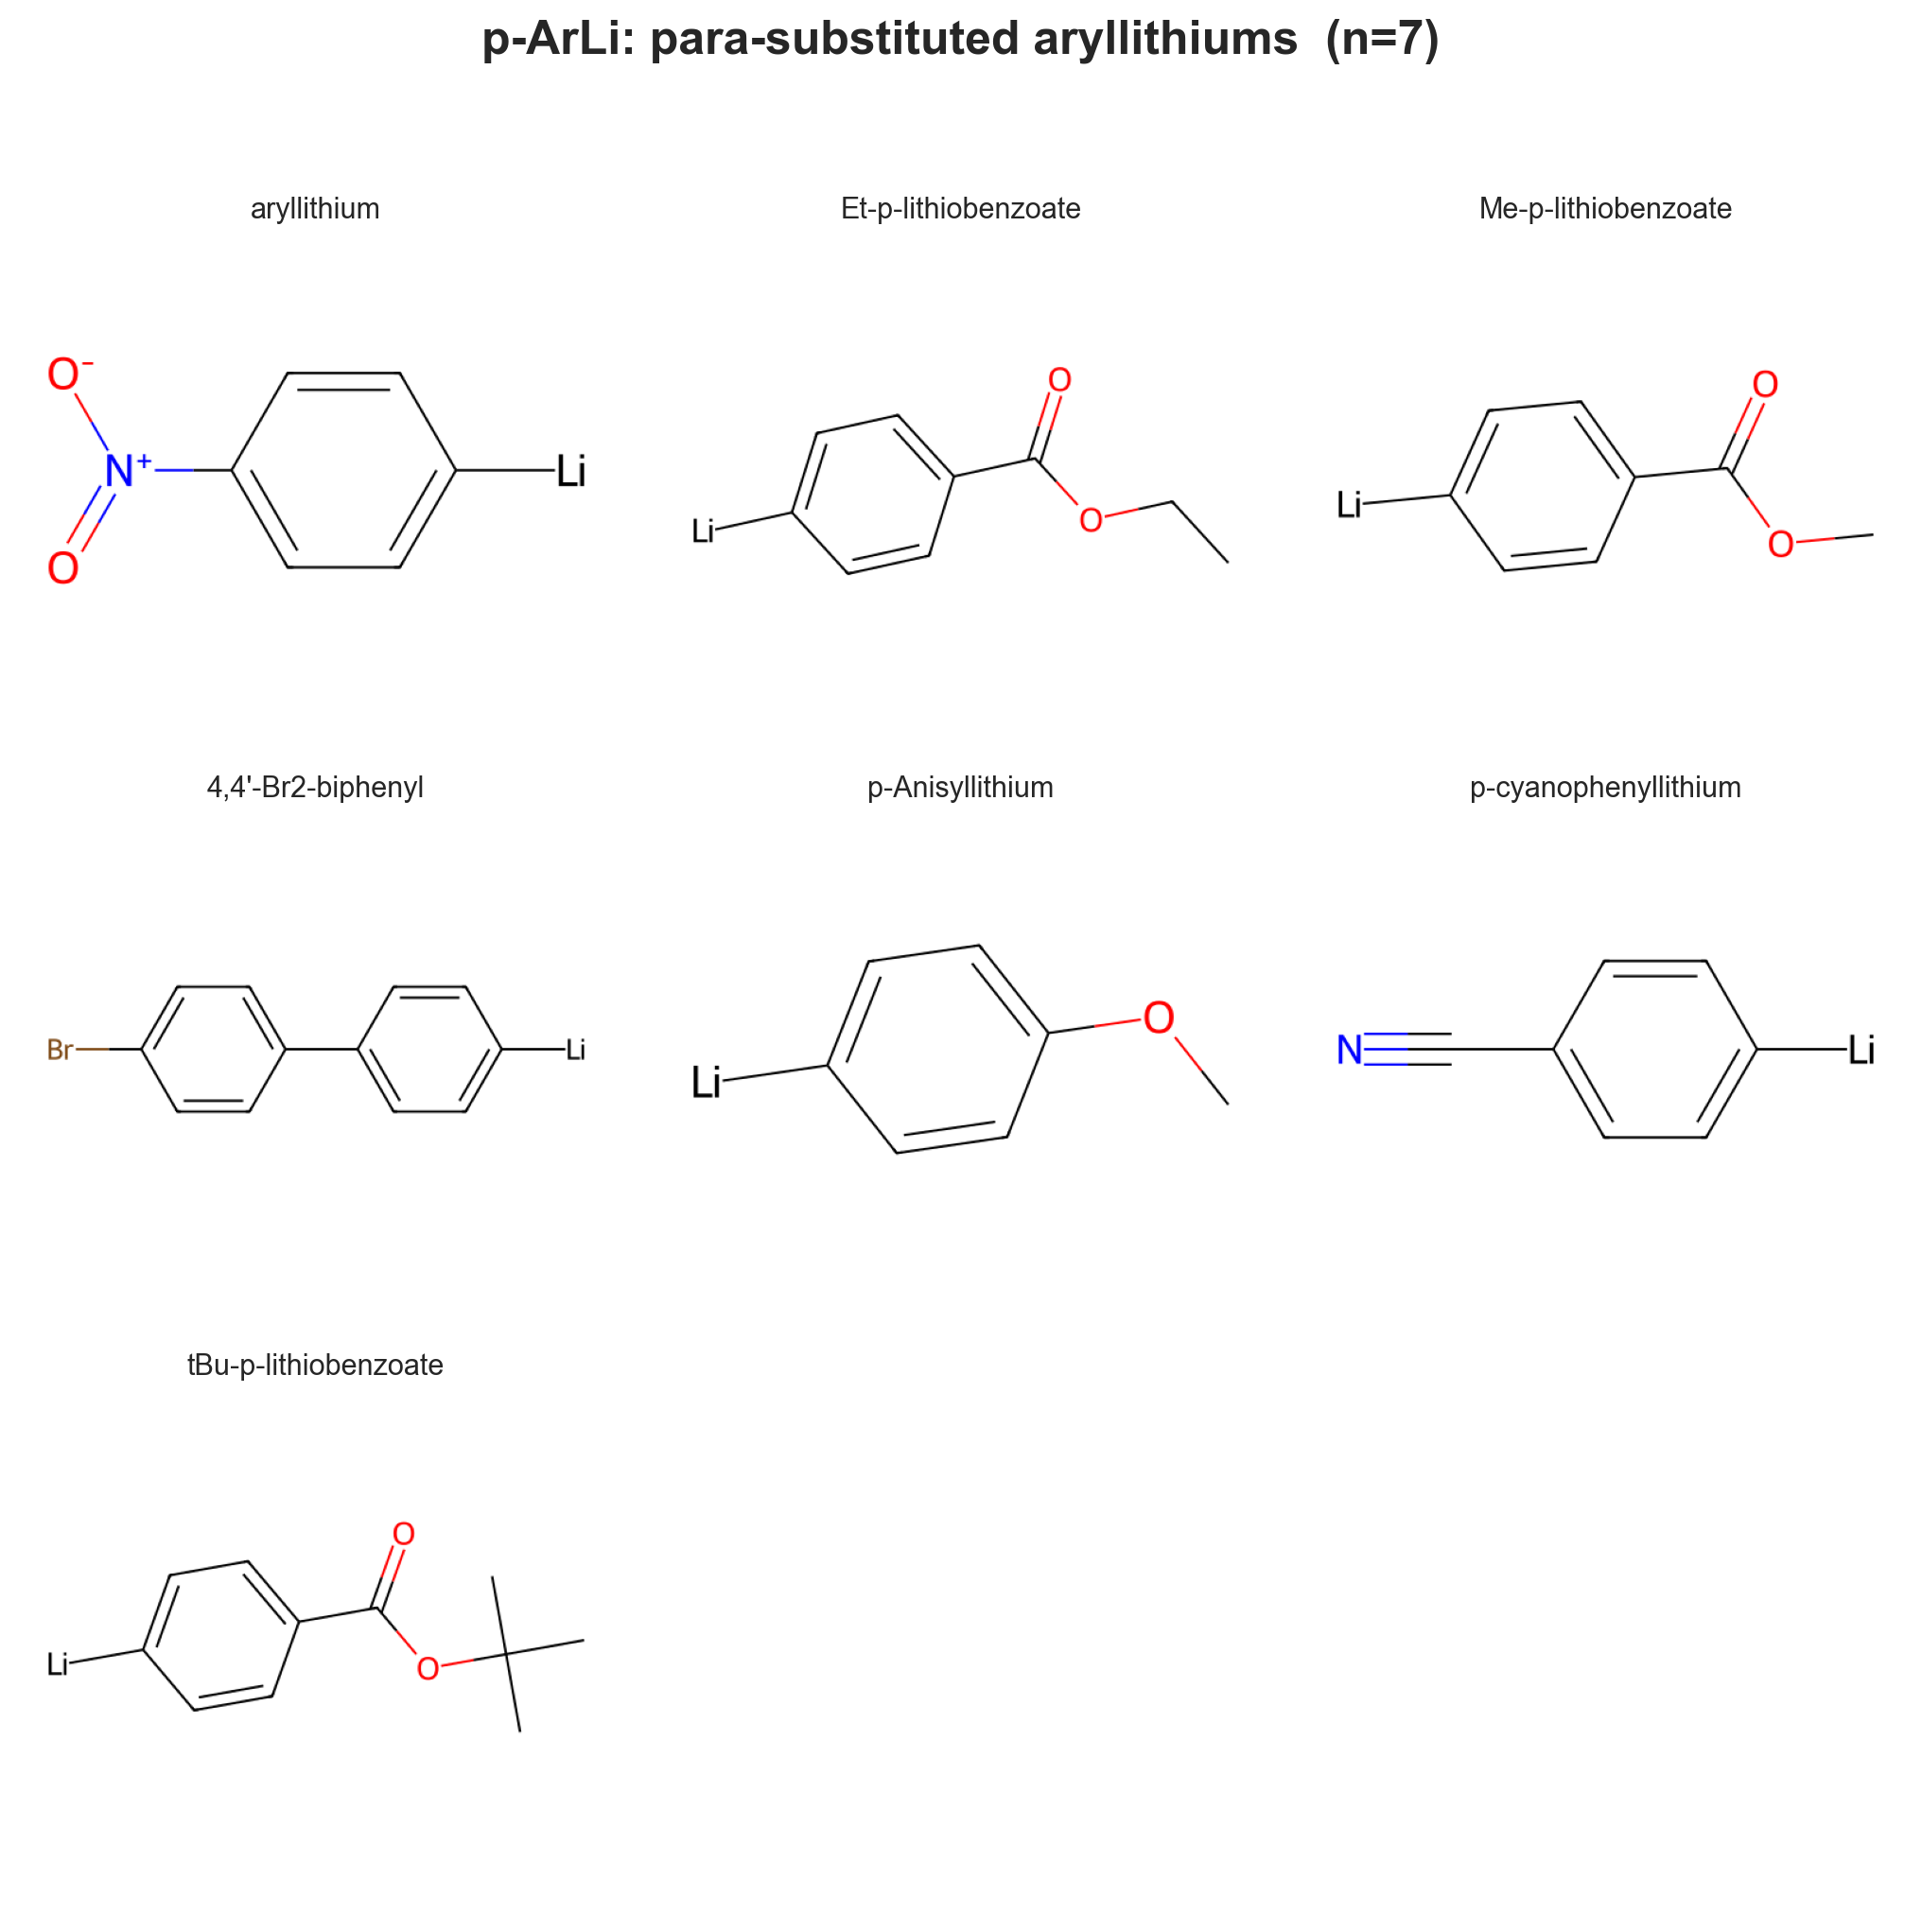

✓ p-ArLi: 7 → analysis_figures/class_p_ArLi.png


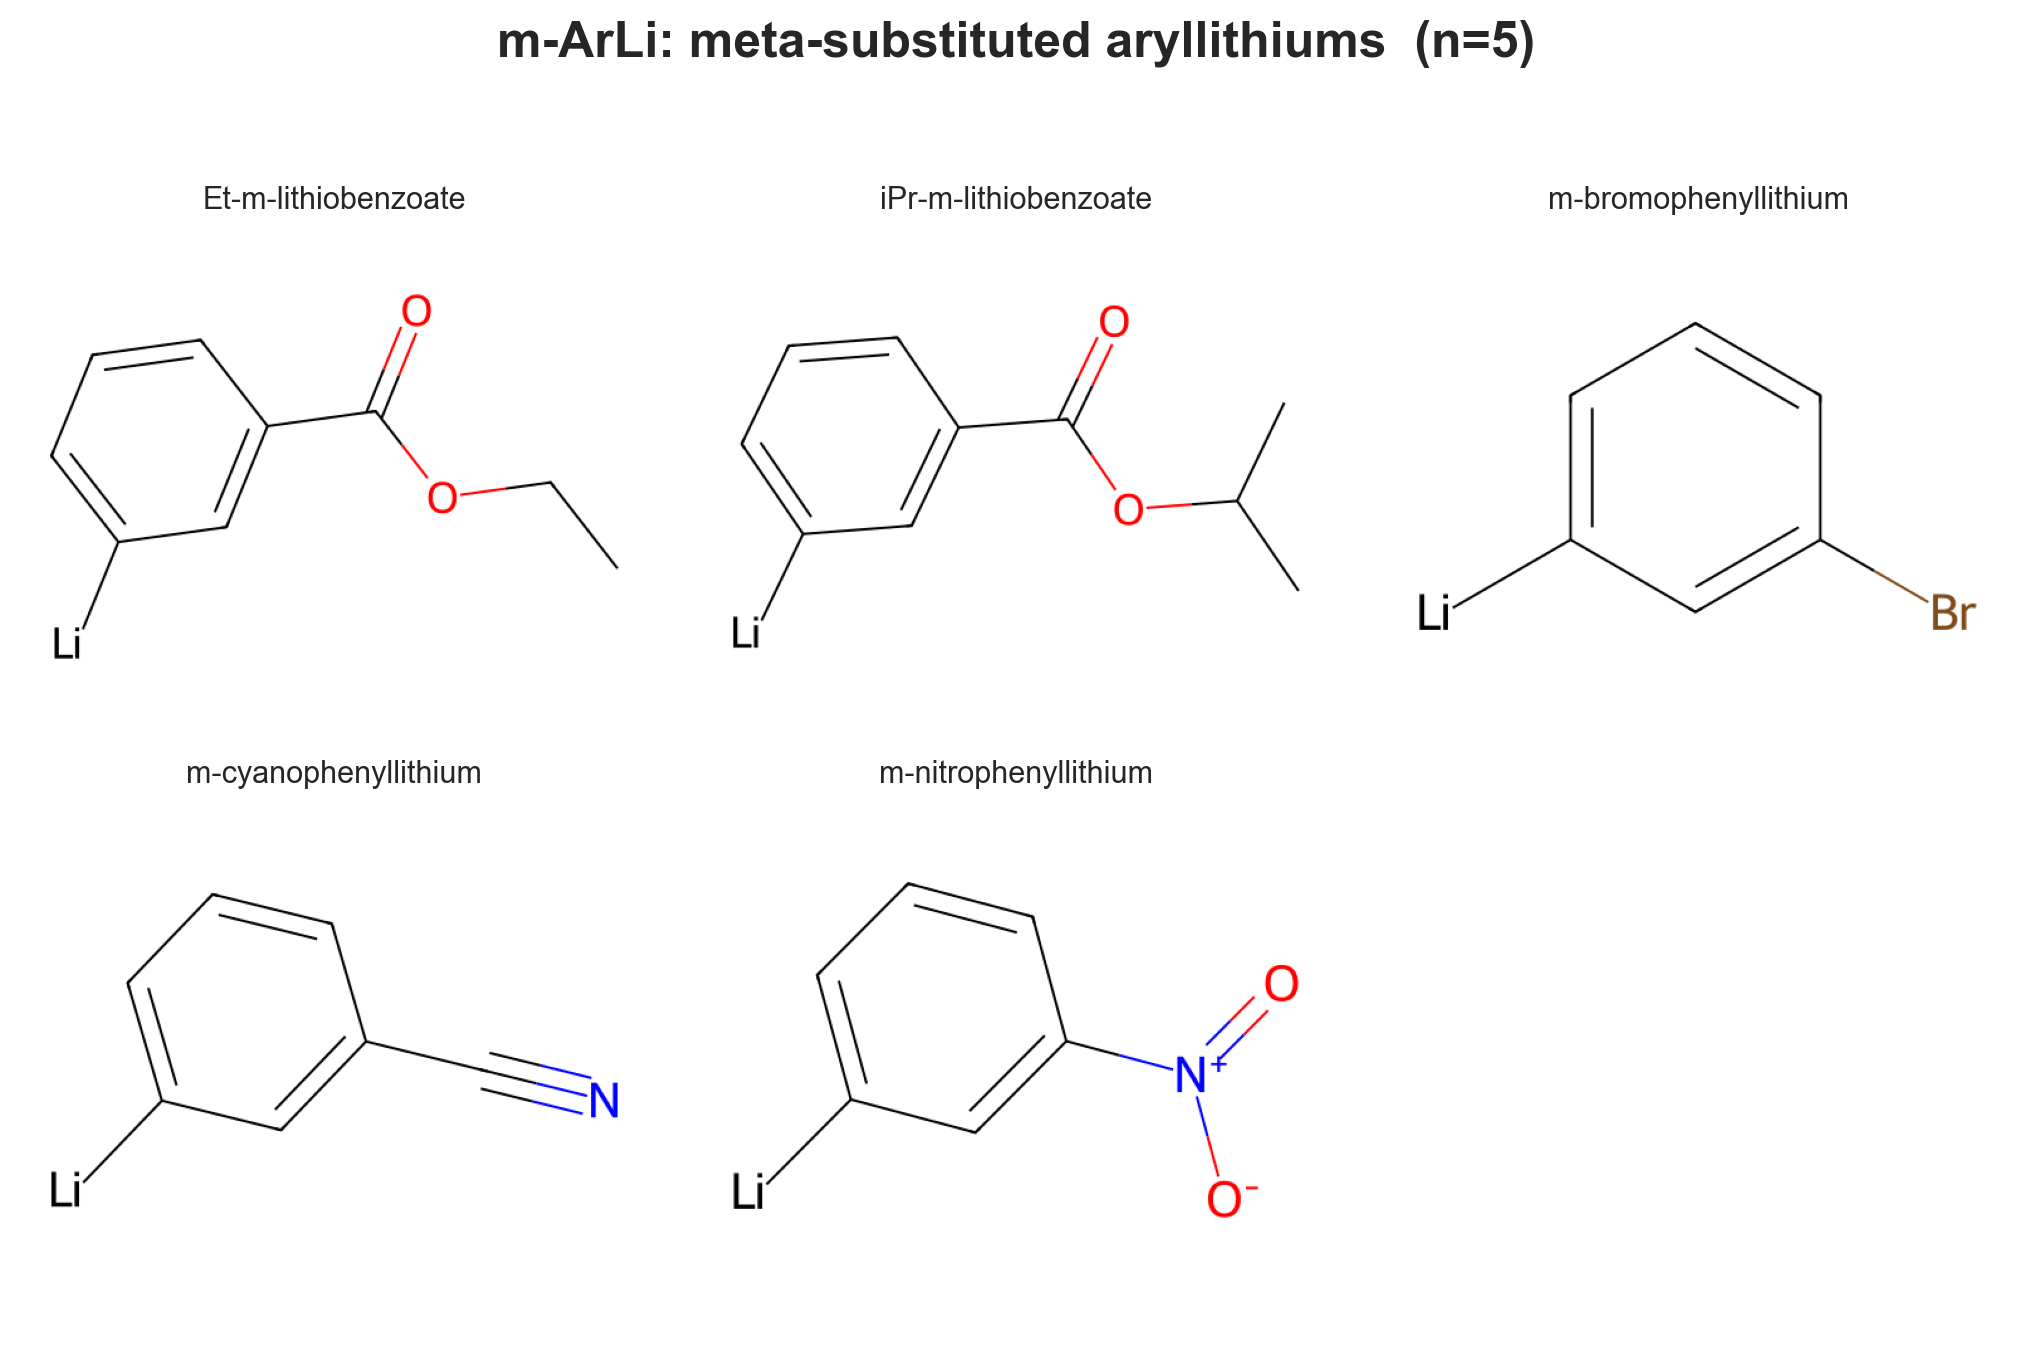

✓ m-ArLi: 5 → analysis_figures/class_m_ArLi.png


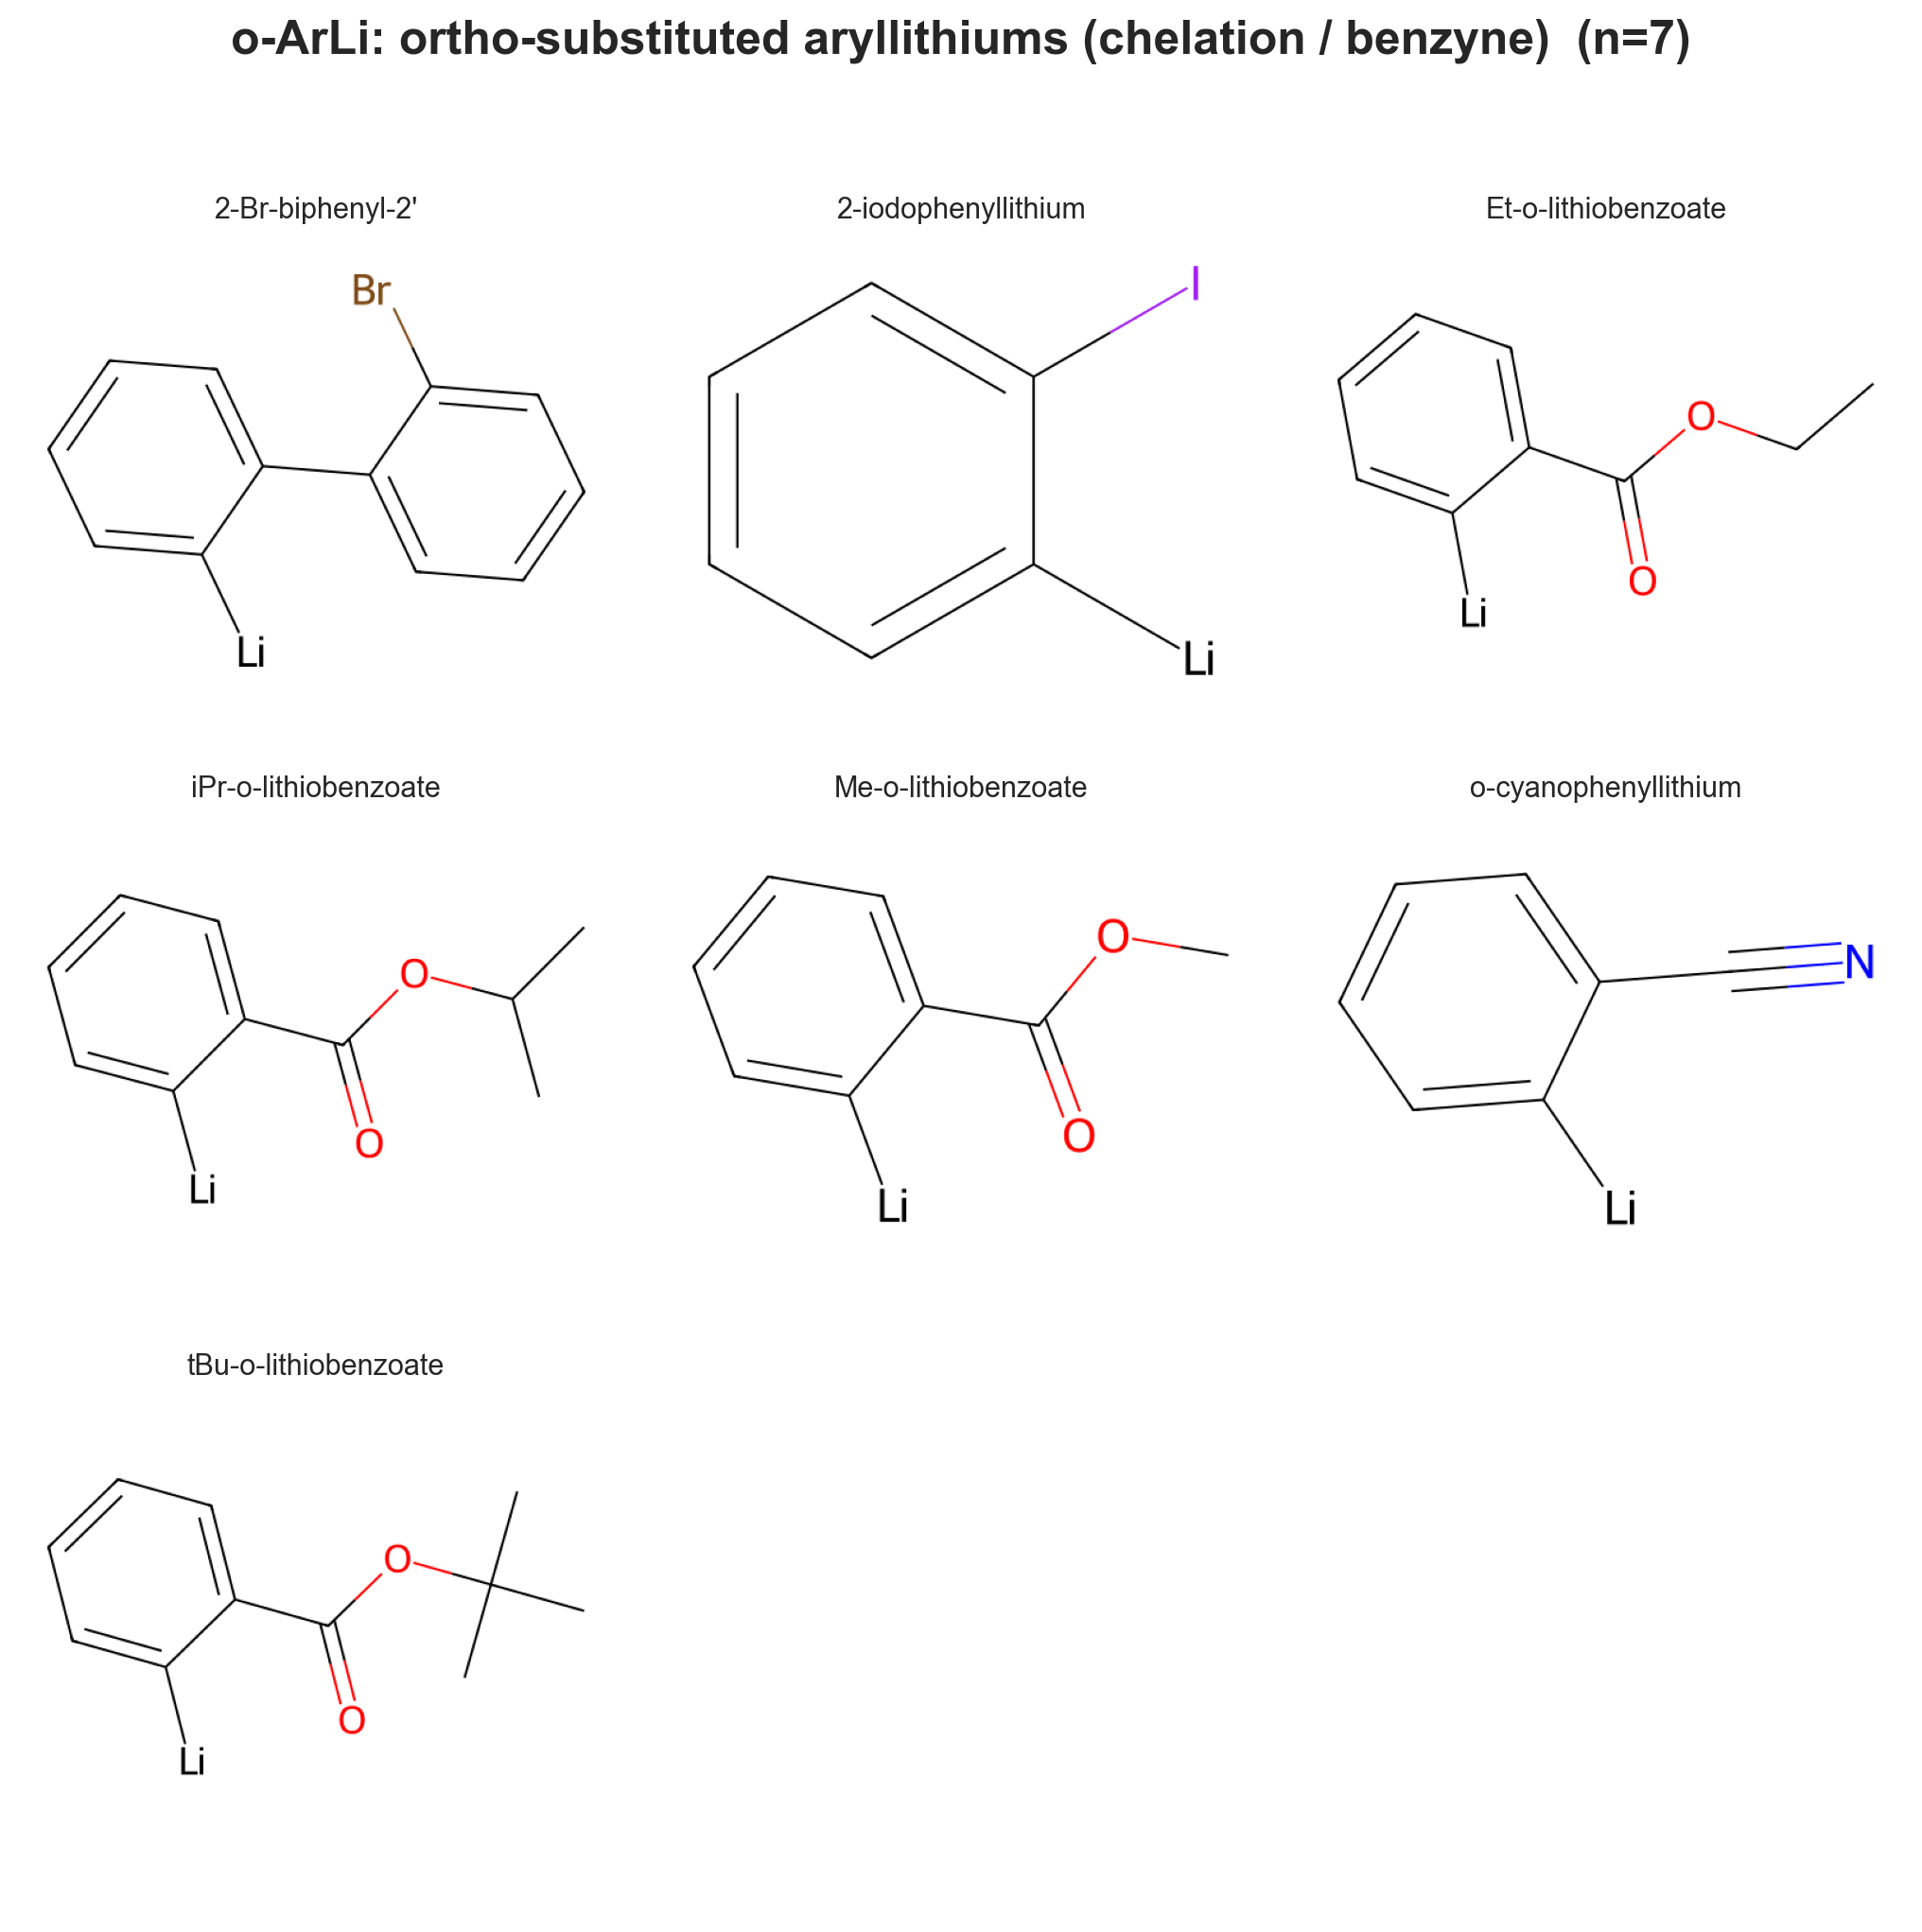

✓ o-ArLi: 7 → analysis_figures/class_o_ArLi.png


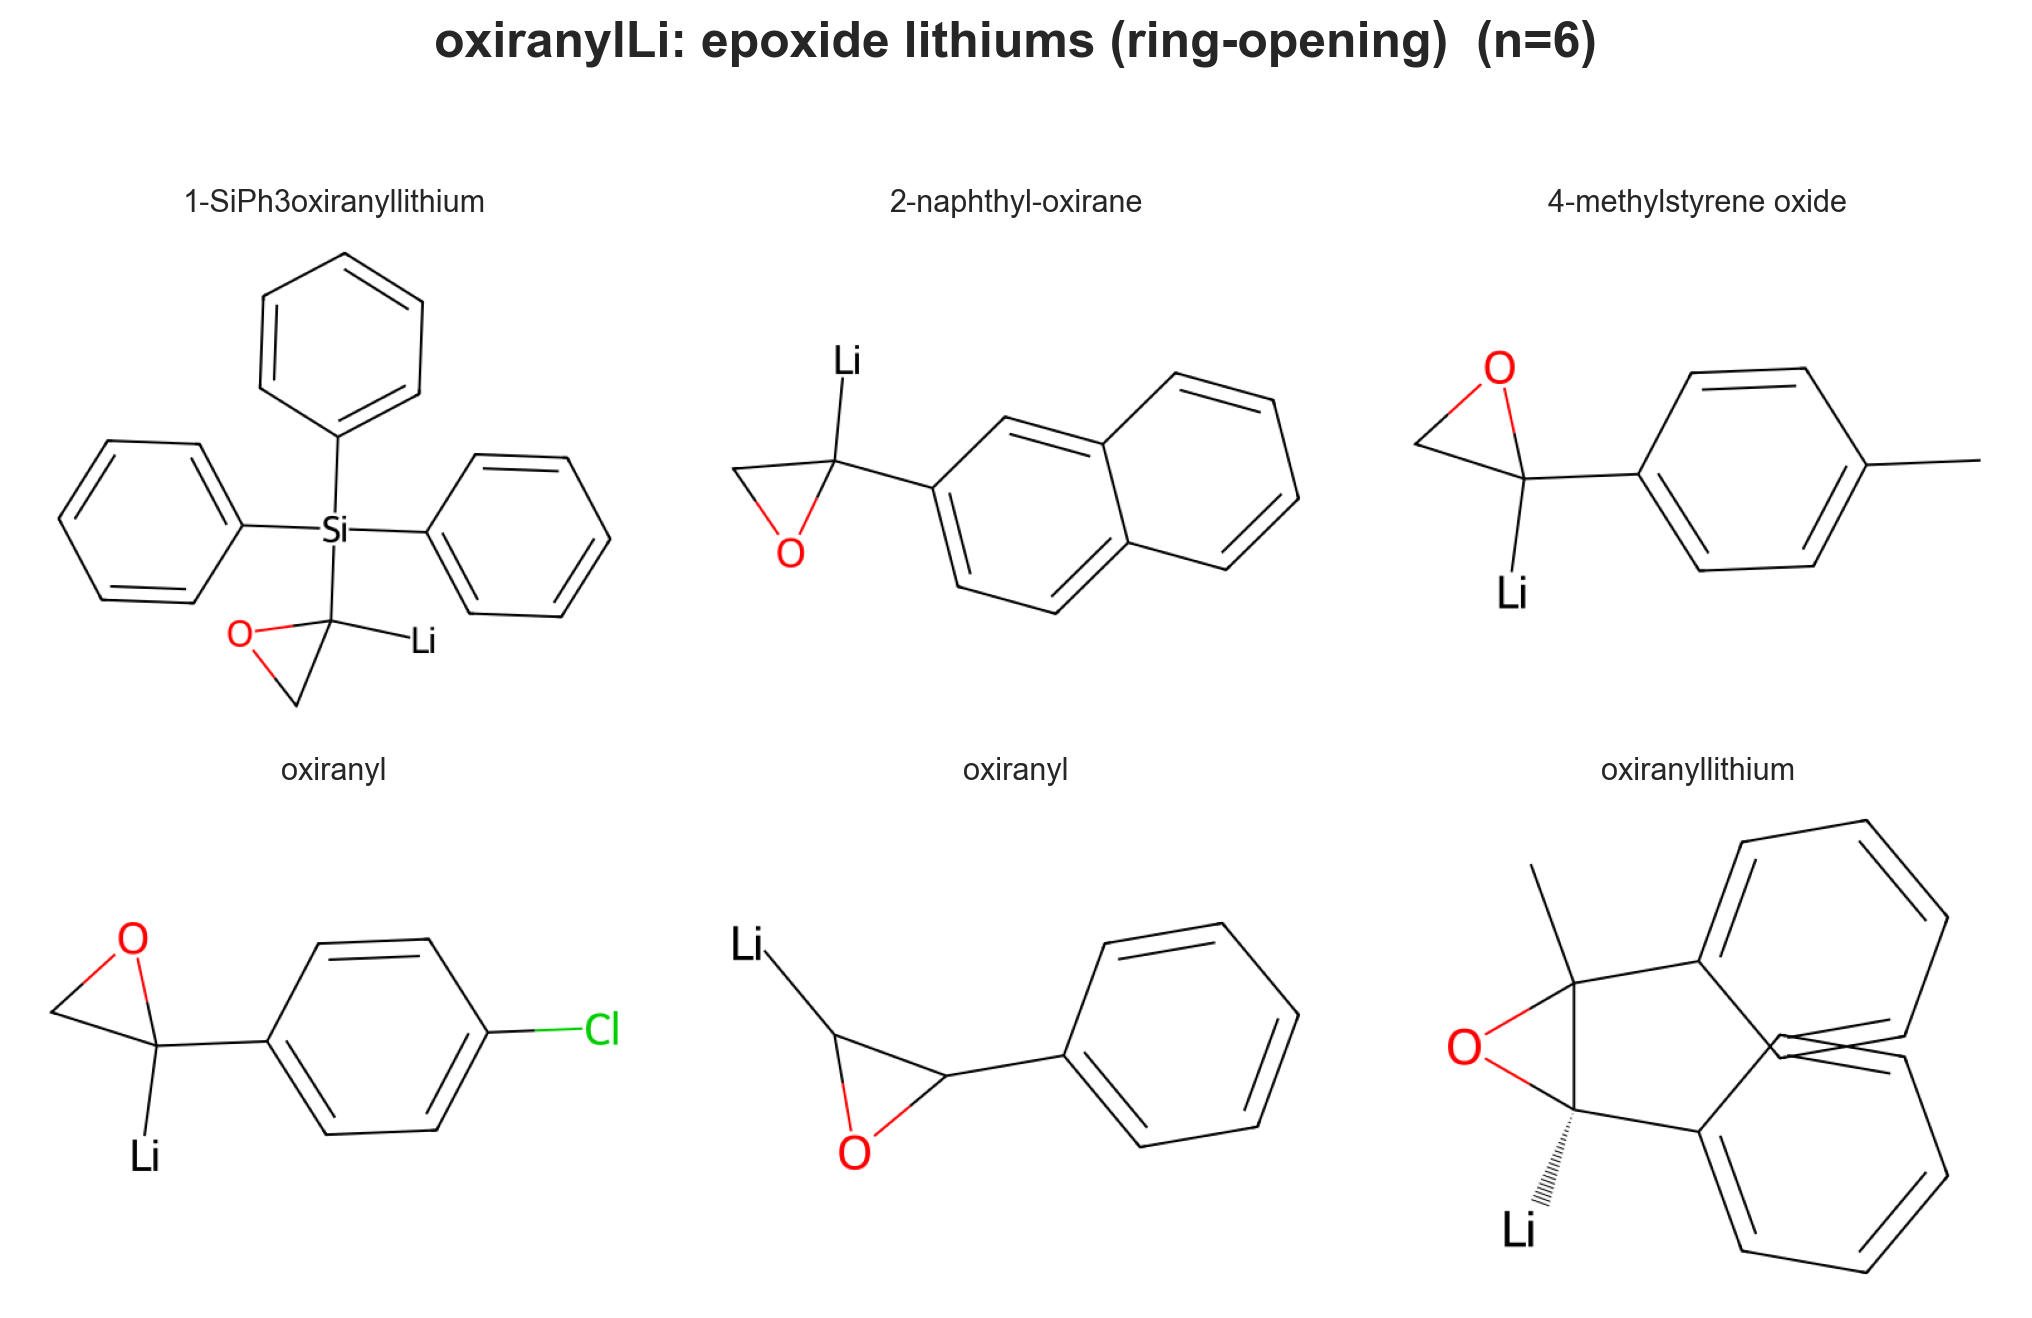

✓ oxiranylLi: 6 → analysis_figures/class_oxiranylLi.png


In [11]:
# ===== 7c.1  每类结构总览 =====
import math
from io import BytesIO
from PIL import Image
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D

def _short_label(name):
    name = str(name).strip()
    for k, v in [('monolithiated ', ''), (' anion', ''), (' intermediate', ''),
                 ('lithium ', ''), ('lithiated ', ''),
                 ("4,4'-dibromobiphenyl", "4,4'-Br2-biphenyl"),
                 ('2-(2-naphthyl)ethylene oxide', '2-naphthyl-oxirane'),
                 ('ethylene oxide', 'oxirane'),
                 ("2-bromo-2'-lithiobiphenyl", "2-Br-biphenyl-2'"),
                 ('methyl ', 'Me-'), ('ethyl ', 'Et-'),
                 ('isopropyl ', 'iPr-'), ('tert-butyl ', 'tBu-'),
                 ('triphenylsilyl', 'SiPh3')]:
        name = name.replace(k, v)
    return name

def _mol_image(smi, size=(500, 400)):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    d = rdMolDraw2D.MolDraw2DCairo(*size)
    d.drawOptions().bondLineWidth = 2
    d.drawOptions().padding = 0.05
    d.DrawMolecule(mol)
    d.FinishDrawing()
    return Image.open(BytesIO(d.GetDrawingText()))

class_configs = [
    ('p-ArLi',     'p-ArLi: para-substituted aryllithiums',
     'analysis_figures/class_p_ArLi.png'),
    ('m-ArLi',     'm-ArLi: meta-substituted aryllithiums',
     'analysis_figures/class_m_ArLi.png'),
    ('o-ArLi',     'o-ArLi: ortho-substituted aryllithiums (chelation / benzyne)',
     'analysis_figures/class_o_ArLi.png'),
    ('oxiranylLi', 'oxiranylLi: epoxide lithiums (ring-opening)',
     'analysis_figures/class_oxiranylLi.png'),
]

os.makedirs('analysis_figures', exist_ok=True)

for cls_code, title, outpath in class_configs:
    sub = modeling_set[modeling_set['class'] == cls_code].sort_values('intermediate').reset_index(drop=True)
    if len(sub) == 0: continue
    ncols = 3
    nrows = math.ceil(len(sub) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.5*ncols, 3.5*nrows))
    axes = np.array(axes).reshape(nrows, ncols)
    fig.suptitle(f'{title}  (n={len(sub)})', fontsize=18, fontweight='bold')
    for i, row in sub.iterrows():
        ax = axes[i // ncols, i % ncols]
        img = _mol_image(row['smi'])
        if img is not None:
            ax.imshow(img)
        ax.set_title(_short_label(row['intermediate']), fontsize=11, pad=6)
        ax.axis('off')
    for j in range(len(sub), nrows*ncols):
        axes[j // ncols, j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(outpath, dpi=200, bbox_inches='tight')
    plt.show()
    print(f'✓ {cls_code}: {len(sub)} → {outpath}')


Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6210' [U+6210], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


...

Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6210' [U+6210], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


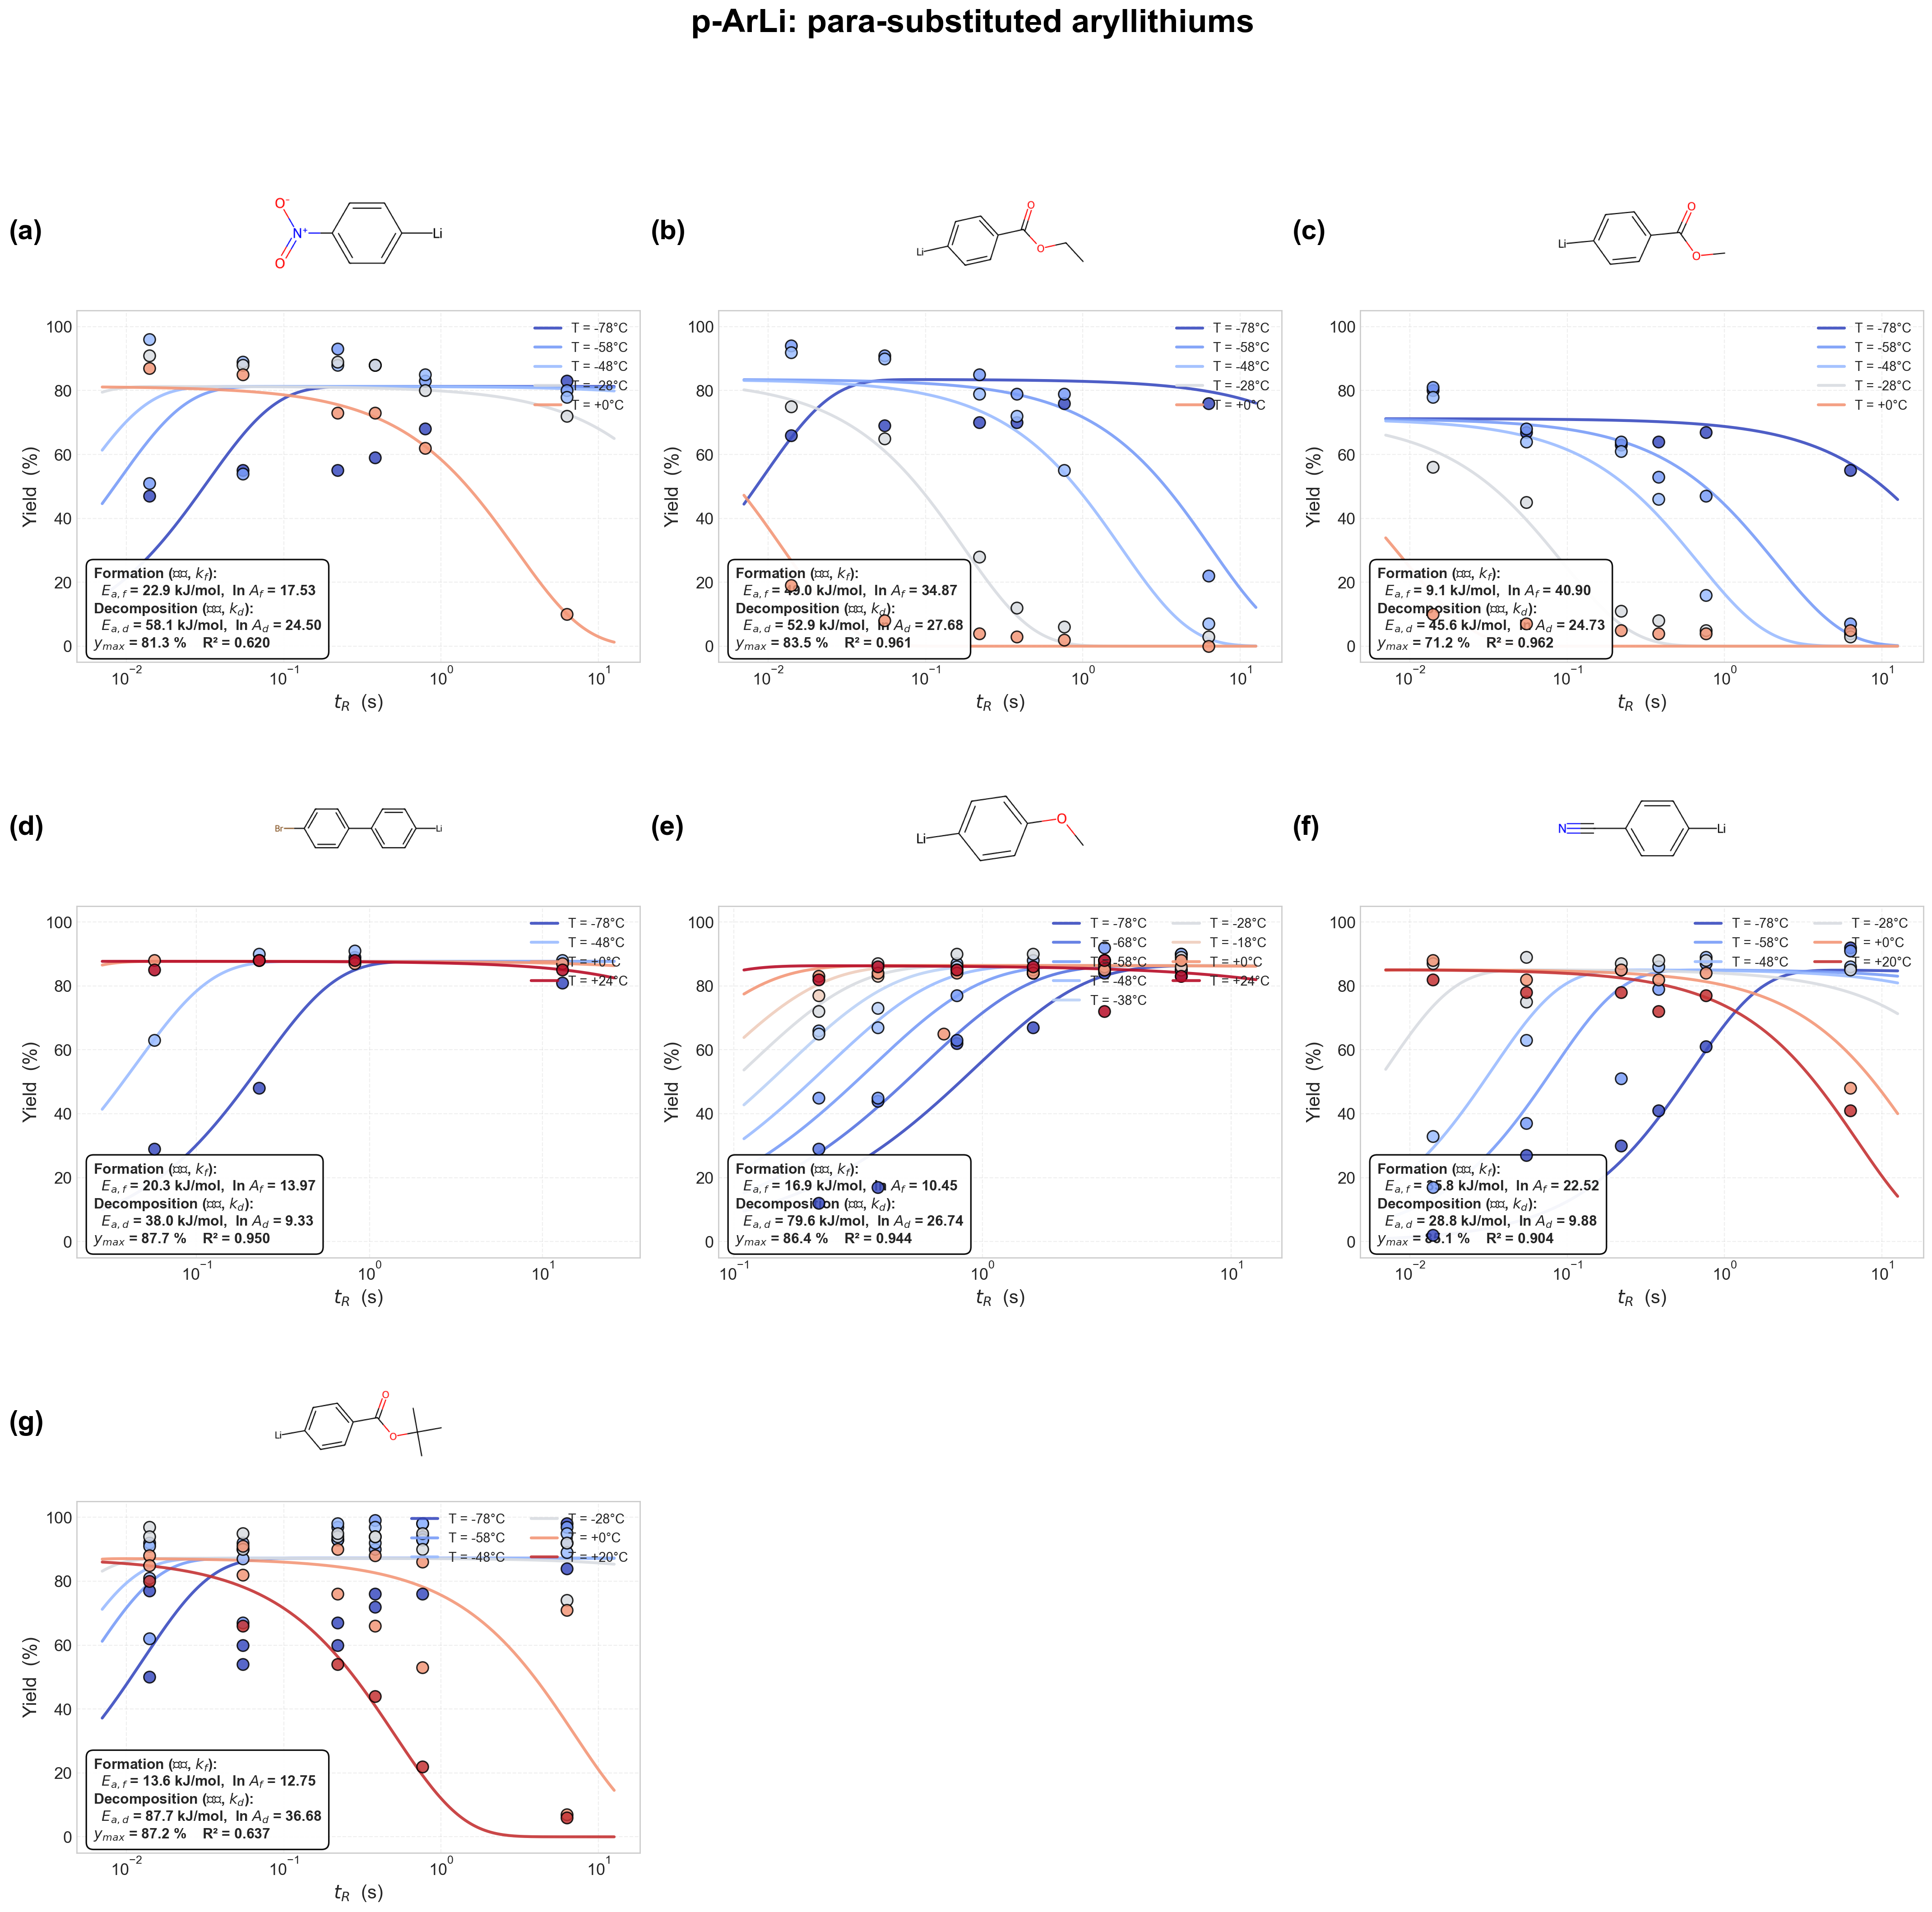

Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6210' [U+6210], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


✓ p-ArLi: 7 → analysis_figures/yield_curves_p_ArLi.png


...

Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6210' [U+6210], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


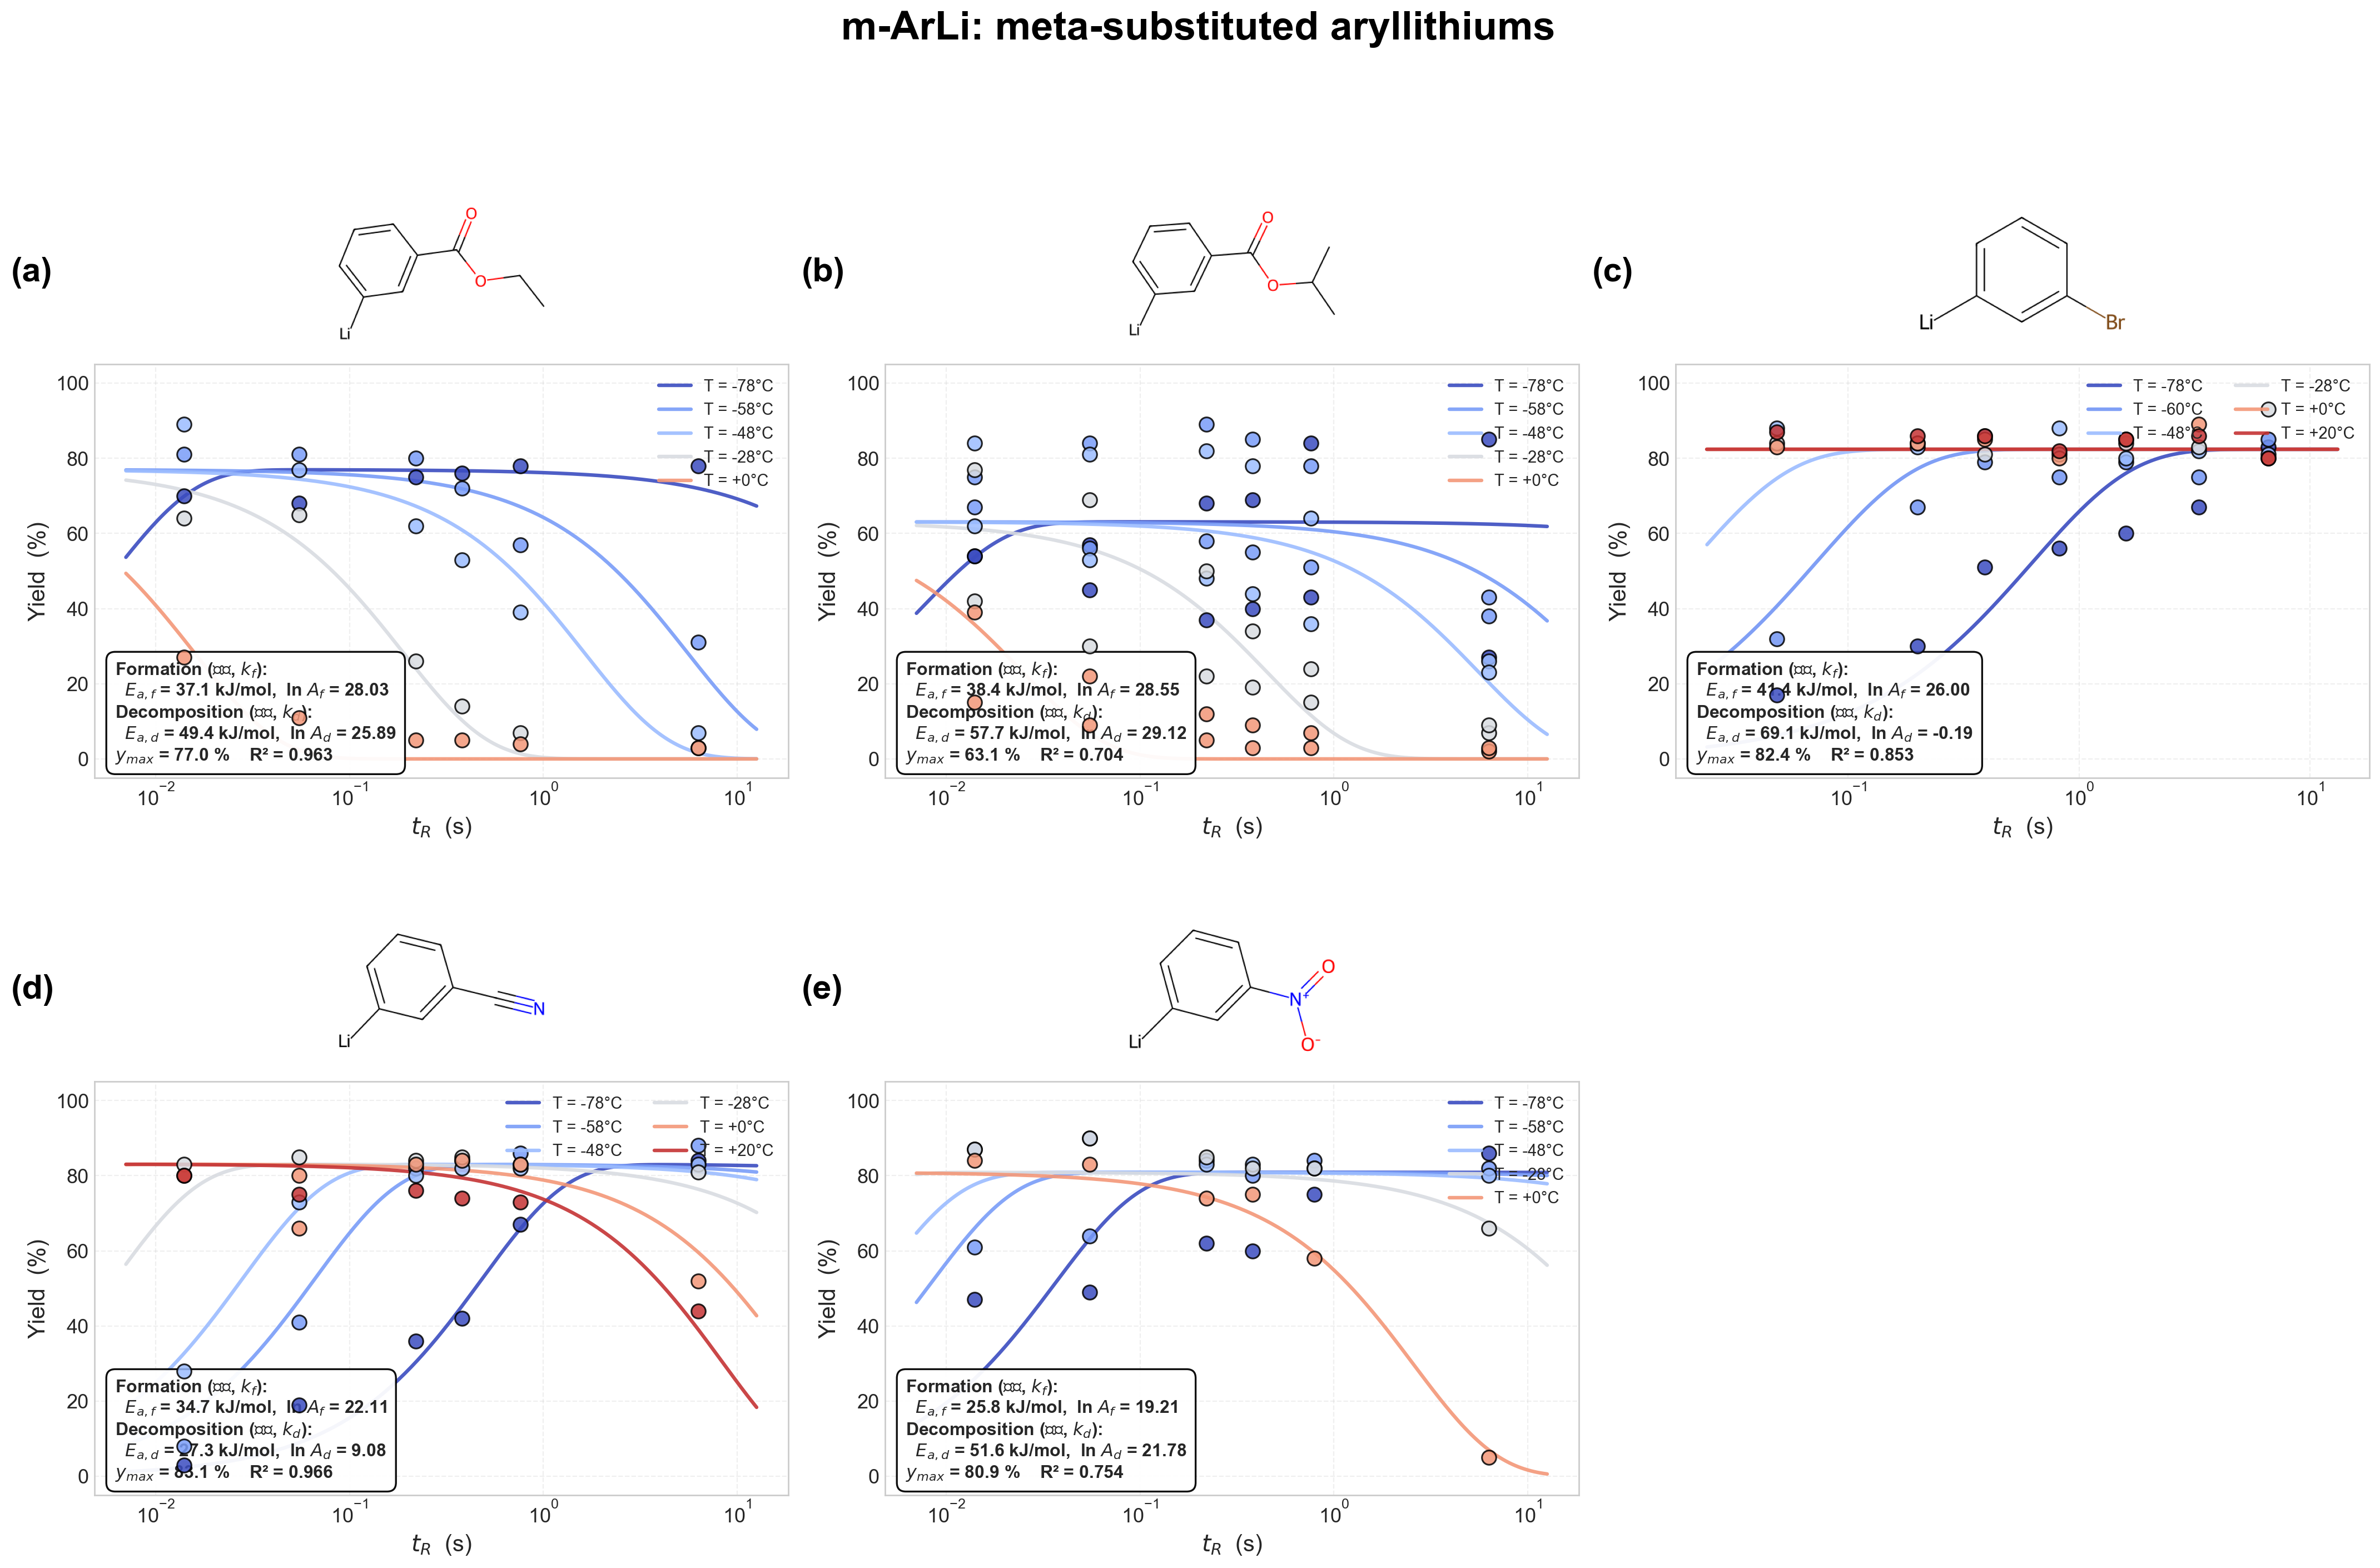

Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6210' [U+6210], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


✓ m-ArLi: 5 → analysis_figures/yield_curves_m_ArLi.png


...

Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6210' [U+6210], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


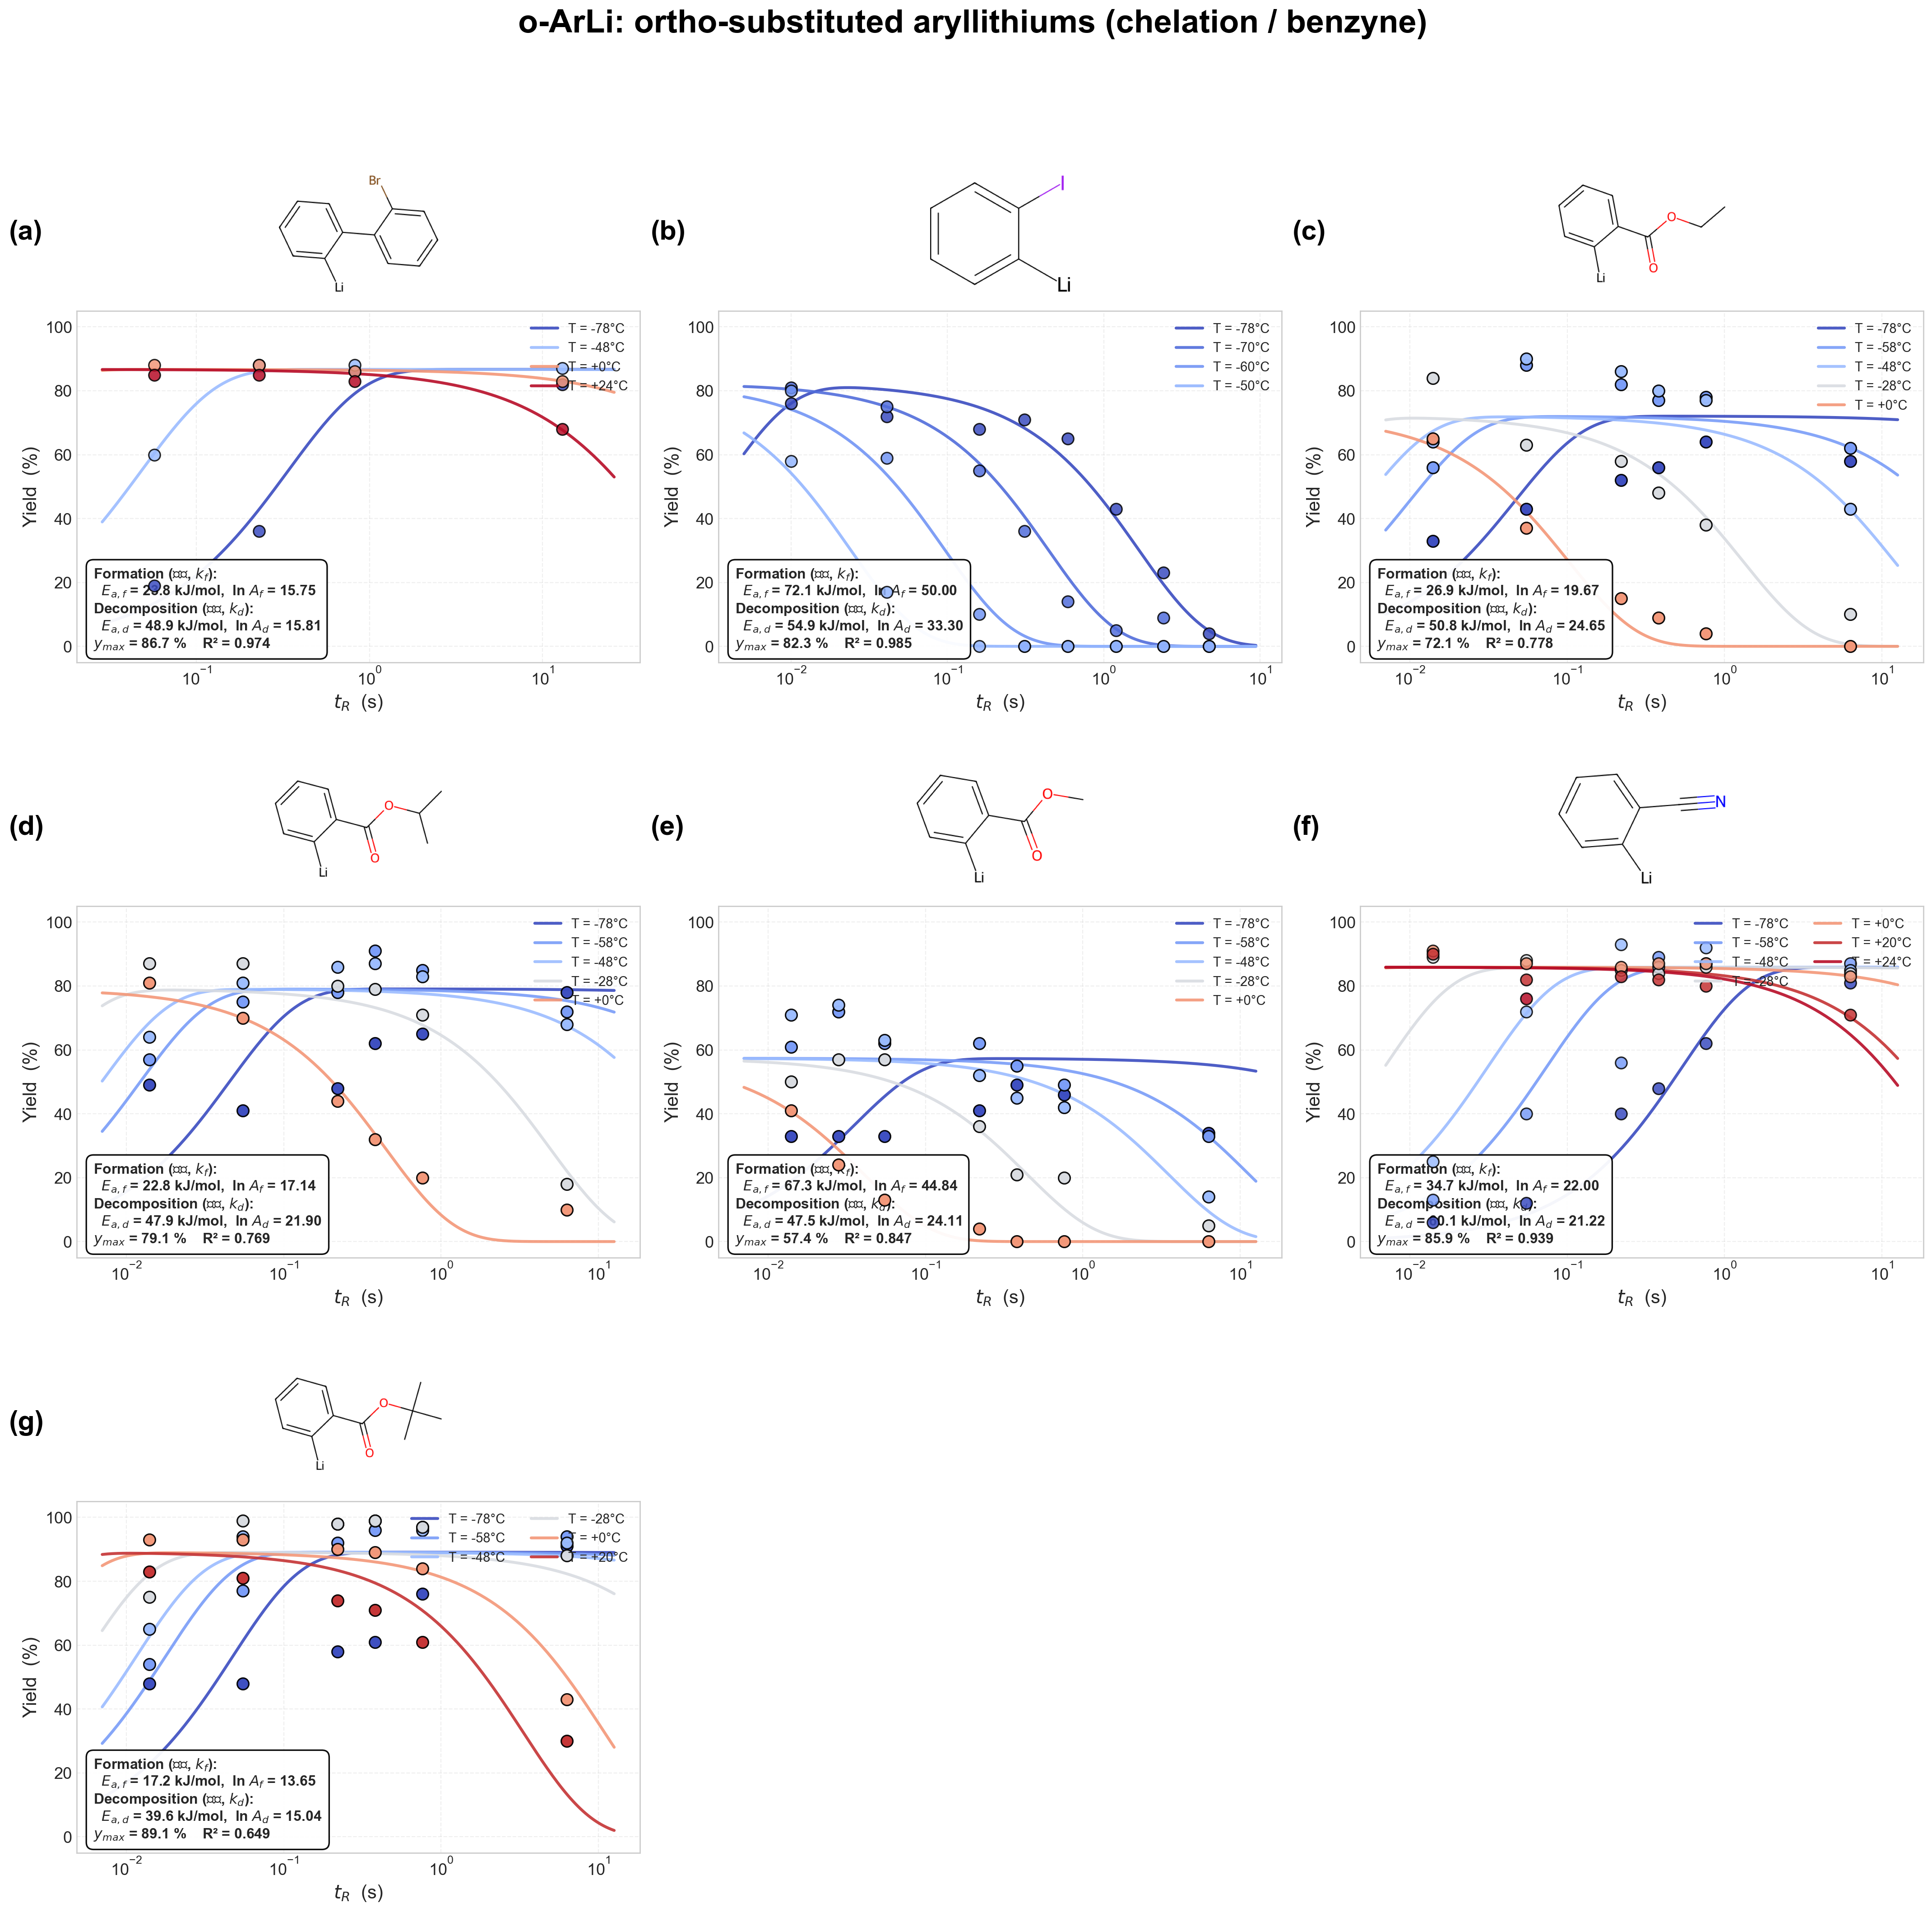

Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6210' [U+6210], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


✓ o-ArLi: 7 → analysis_figures/yield_curves_o_ArLi.png


...

Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u751f' [U+751f], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u6210' [U+6210], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5206' [U+5206], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u89e3' [U+89e3], substituting with a dummy symbol.


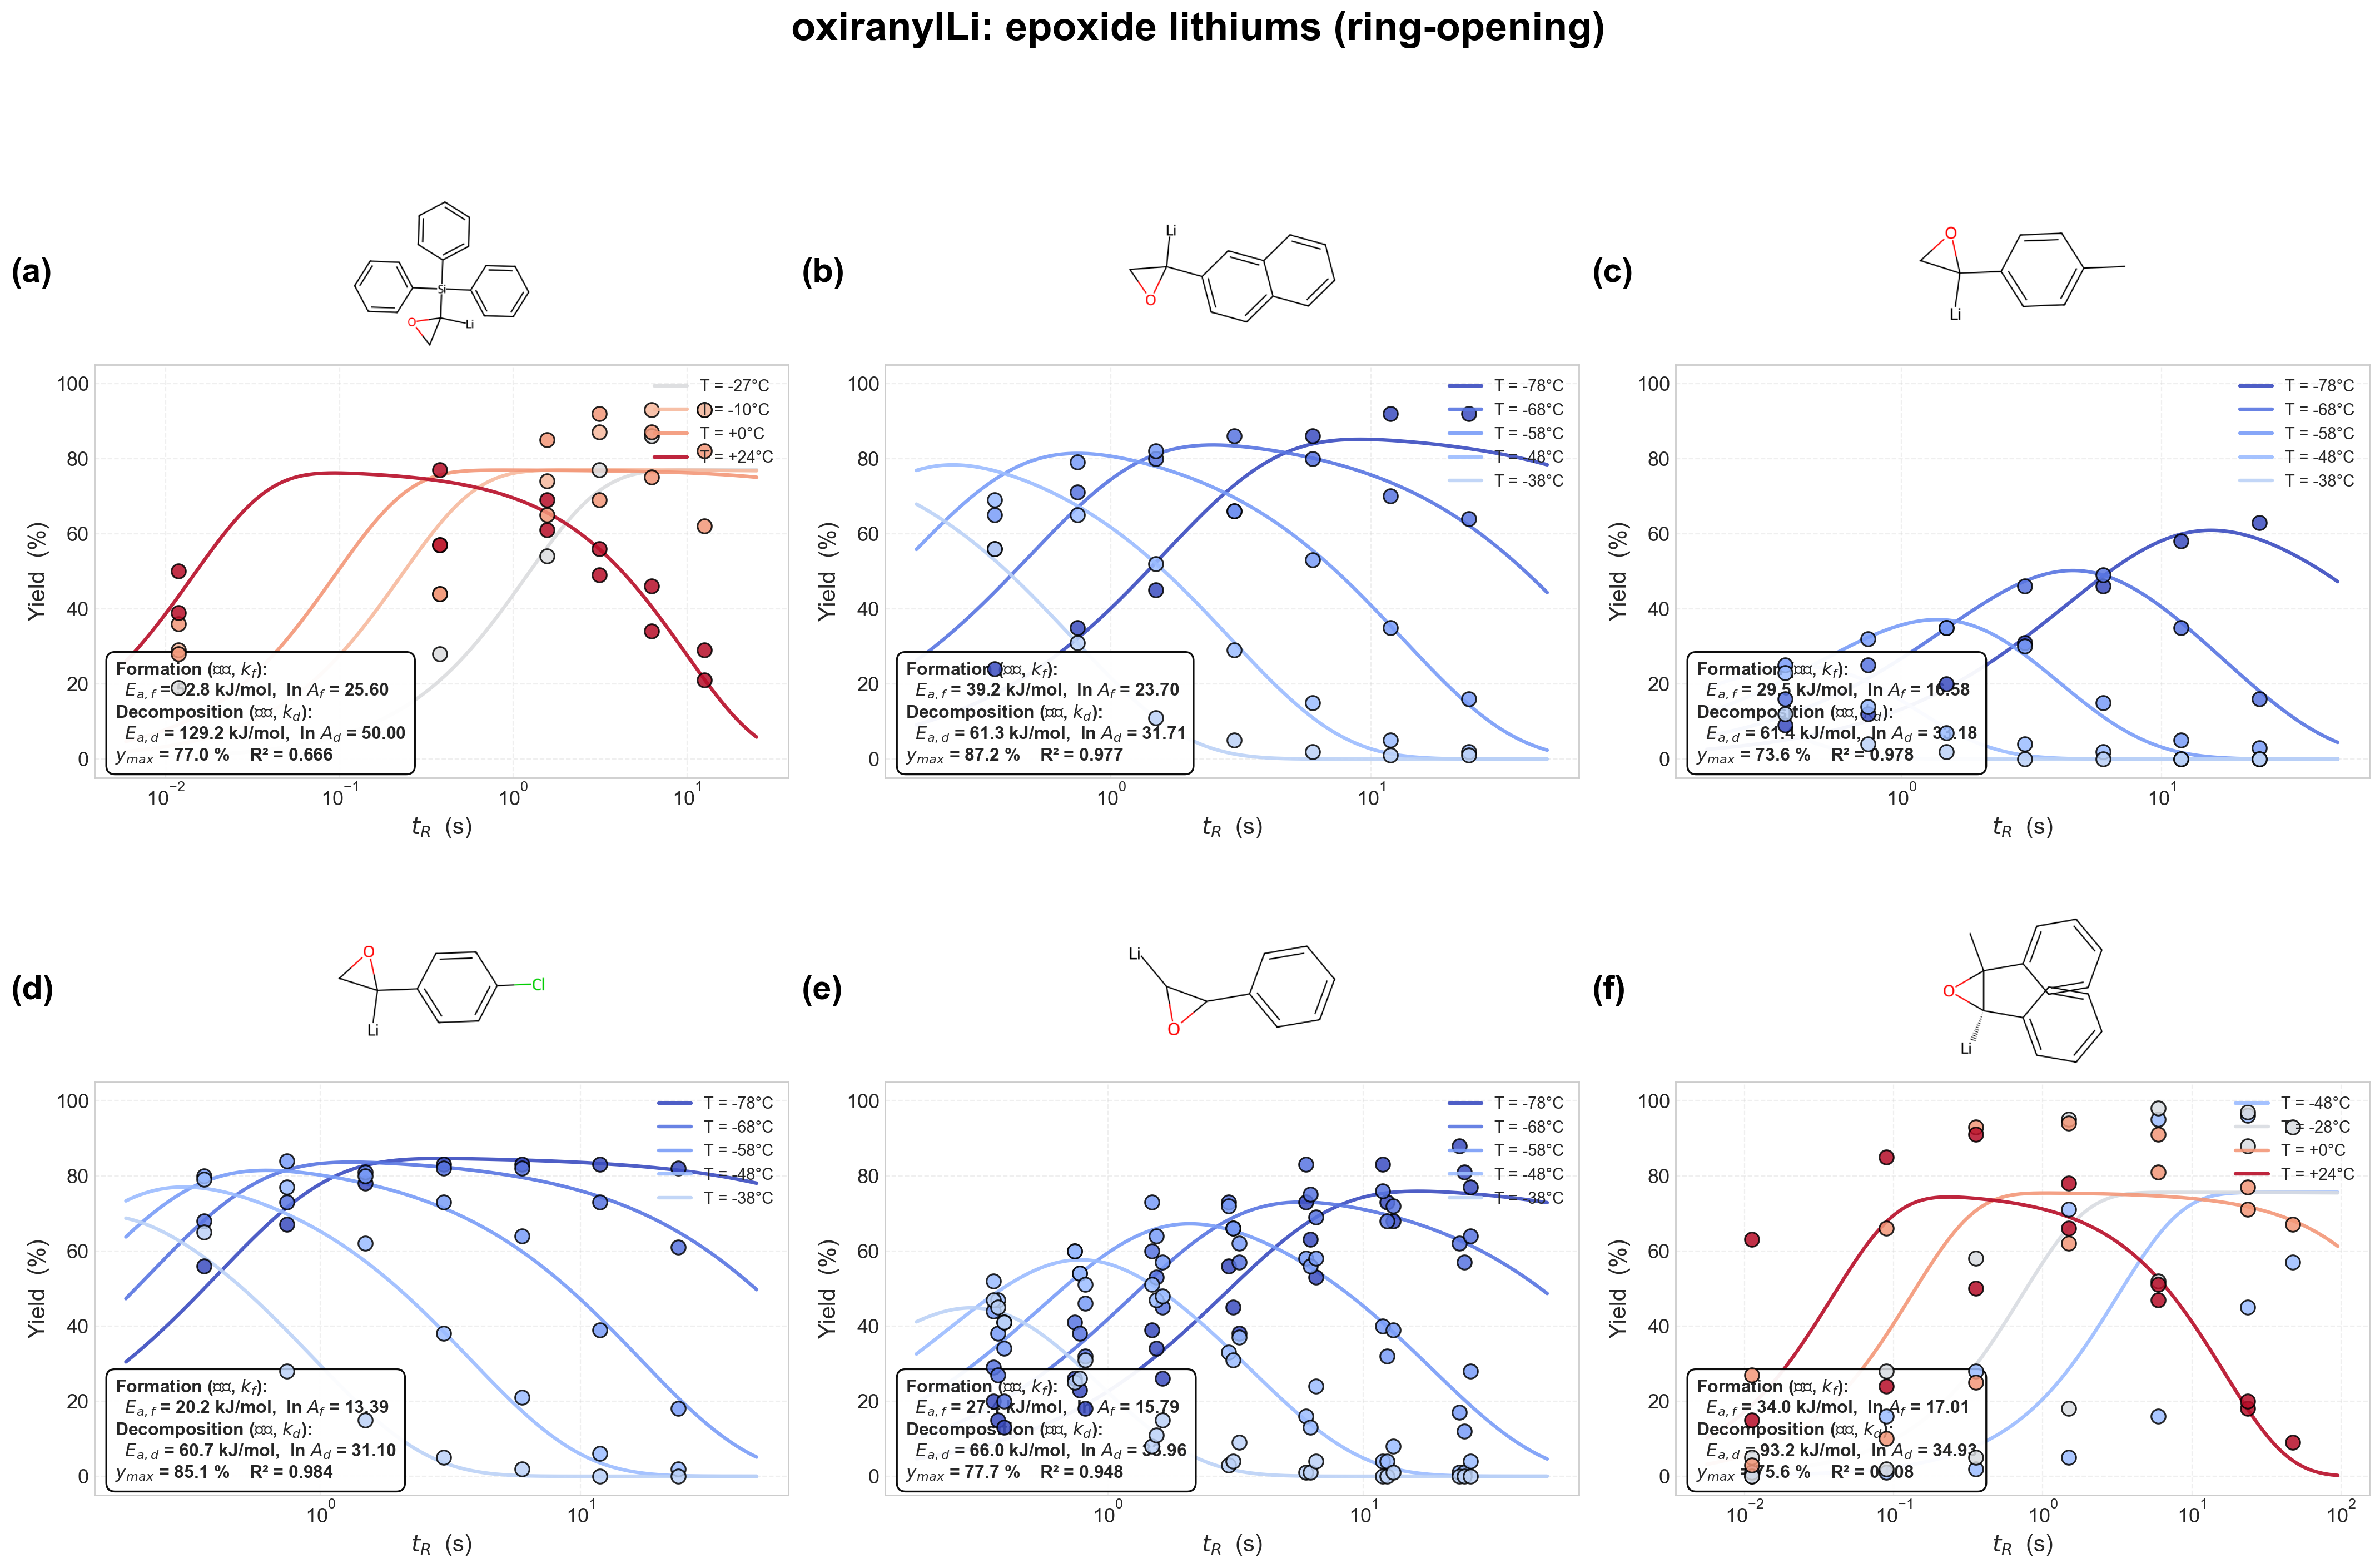

✓ oxiranylLi: 6 → analysis_figures/yield_curves_oxiranylLi.png


In [12]:
# ===== 7c.2  每类 yield-vs-tR 曲线 (全局 Arrhenius 模型拟合) =====
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib import cm
from matplotlib.colors import Normalize

R_GAS = 8.314e-3  # kJ/(mol·K)

raw = pd.read_csv('clean_organolithium_unified.csv')

def _yield_model(tR, T_K, Ea_f, lnA_f, Ea_d, lnA_d, y_max):
    k_f = np.exp(lnA_f - Ea_f/(R_GAS*T_K))
    k_d = np.exp(lnA_d - Ea_d/(R_GAS*T_K))
    return y_max * (1 - np.exp(-k_f*tR)) * np.exp(-k_d*tR)

yield_configs = [
    ('p-ArLi',     'p-ArLi: para-substituted aryllithiums',
     'analysis_figures/yield_curves_p_ArLi.png'),
    ('m-ArLi',     'm-ArLi: meta-substituted aryllithiums',
     'analysis_figures/yield_curves_m_ArLi.png'),
    ('o-ArLi',     'o-ArLi: ortho-substituted aryllithiums (chelation / benzyne)',
     'analysis_figures/yield_curves_o_ArLi.png'),
    ('oxiranylLi', 'oxiranylLi: epoxide lithiums (ring-opening)',
     'analysis_figures/yield_curves_oxiranylLi.png'),
]

norm = Normalize(vmin=-78, vmax=25)
cmap = plt.get_cmap('coolwarm')

for cls_code, title, outpath in yield_configs:
    sub = modeling_set[modeling_set['class'] == cls_code].sort_values('intermediate').reset_index(drop=True)
    if len(sub) == 0: continue
    ncols = 3
    nrows = math.ceil(len(sub) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(7.2*ncols, 7.1*nrows))
    axes = np.array(axes).reshape(nrows, ncols)
    fig.suptitle(title, fontsize=26, fontweight='bold', color='black', y=0.998)

    for i, row in sub.iterrows():
        ax = axes[i // ncols, i % ncols]
        smi = row['smi']
        Ea_f, lnA_f = row['Ea_f'], row['lnA_f']
        Ea_d, lnA_d = row['Ea_d'], row['lnA_d']
        y_max = row['y_max']
        r2g = row.get('r2_global', np.nan)

        rd = raw[raw['intermediate_smiles_canonical'] == smi][['tR1_s','T1_C','yield_pct']].dropna()
        rd = rd[(rd['tR1_s'] > 0) & rd['yield_pct'].notna()]

        temps = sorted(rd['T1_C'].unique())
        for T in temps:
            d_T = rd[rd['T1_C'] == T]
            color = cmap(norm(T))
            ax.scatter(d_T['tR1_s'], d_T['yield_pct'],
                       s=85, color=color, edgecolor='black', linewidth=1.1,
                       alpha=0.85, zorder=5)

        if len(rd) > 0:
            tR_min = max(rd['tR1_s'].min()*0.5, 1e-4)
            tR_max = rd['tR1_s'].max()*2
        else:
            tR_min, tR_max = 1e-3, 100
        tR_fit = np.logspace(np.log10(tR_min), np.log10(tR_max), 200)
        for T in temps:
            y_fit = _yield_model(tR_fit, T+273.15, Ea_f, lnA_f, Ea_d, lnA_d, y_max)
            ax.plot(tR_fit, y_fit, '-', color=cmap(norm(T)), lw=2.3, alpha=0.9,
                    label=f'T = {T:+.0f}°C')

        ax.set_xscale('log')
        ax.set_xlabel(r'$t_R$  (s)', fontsize=15)
        ax.set_ylabel('Yield  (%)', fontsize=15)
        ax.set_ylim(-5, 105)
        ax.tick_params(axis='both', labelsize=13)
        ax.grid(alpha=0.3, linestyle='--')

        # 子图编号
        ax.text(-0.12, 1.26, f'({chr(ord("a")+i)})', transform=ax.transAxes,
                fontsize=22, fontweight='bold', verticalalignment='top',
                horizontalalignment='left', color='black')

        # 参数标注
        r2txt = f'R² = {r2g:.3f}' if not np.isnan(r2g) else 'R² = N/A'
        txt = (f'Formation (生成, $k_f$):\n'
               f'  $E_{{a,f}}$ = {Ea_f:.1f} kJ/mol,  ln $A_f$ = {lnA_f:.2f}\n'
               f'Decomposition (分解, $k_d$):\n'
               f'  $E_{{a,d}}$ = {Ea_d:.1f} kJ/mol,  ln $A_d$ = {lnA_d:.2f}\n'
               f'$y_{{max}}$ = {y_max:.1f} %    {r2txt}')
        ax.text(0.03, 0.03, txt, transform=ax.transAxes, fontsize=11.5,
                verticalalignment='bottom', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                          edgecolor='black', linewidth=1.2, alpha=0.95))

        # 图例
        if len(temps) >= 1:
            ax.legend(loc='upper right', fontsize=10.5, framealpha=0.85,
                      ncol=1 if len(temps) <= 5 else 2)

        # 分子结构 inset (上方 350 px)
        img = _mol_image(smi, size=(350, 245))
        if img is not None:
            ab = AnnotationBbox(OffsetImage(img, zoom=0.42), (0.5, 1.22),
                                xycoords='axes fraction', frameon=False,
                                box_alignment=(0.5, 0.5))
            ax.add_artist(ab)

        if len(temps) < 3:
            for sp in ax.spines.values():
                sp.set_edgecolor('black'); sp.set_linewidth(2.5); sp.set_linestyle('--')

    for j in range(len(sub), nrows*ncols):
        axes[j // ncols, j % ncols].axis('off')
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(outpath, dpi=170, bbox_inches='tight')
    plt.show()
    print(f'✓ {cls_code}: {len(sub)} → {outpath}')


## Step 11: 实验验证 — 5-参数模型在 3 组实验数据上的表现

用统一的 **5-参数 bell-curve** 模型 (即 Zhao 之前构建的模型) 拟合三组 in-house flow 数据，看模型的**适用范围与失效模式**:

$$\text{yield}(t_R, T)\ [\%] = y_{\max}\cdot \underbrace{[1 - e^{-k_f(T)\,t_R}]}_{\text{生成}}\cdot \underbrace{e^{-k_d(T)\,t_R}}_{\text{分解}}$$

$$k_f(T) = e^{\ln A_f - E_{a,f}/(RT)}, \quad k_d(T) = e^{\ln A_d - E_{a,d}/(RT)}$$

$$t_{\max} = \frac{\ln(k_f/k_d)}{k_f - k_d}, \quad t_{1/2} = \frac{\ln 2}{k_d}$$

**5 个参数**: Ea_f, lnA_f, Ea_d, lnA_d, **y_max**

`y_max` 物理意义: 反应/quench 体系的产率 ceiling（不一定 = 100%，因为有 selectivity 损失、quench inefficiency、非 ArLi-pool 副反应等）。

| Case | Substrate | Quencher | 数据类型 | n |
|---|---|---|---|---:|
| **A** | 4-Br-fluorobenzene | **MeOH** (proto-de-Li) | 只有 conversion (按 100% selectivity 当 yield) | 22 |
| **B** | 4-Br-fluorobenzene | **PhCHO** (carbonyl addition) | 完整 trap yield | 30 |
| **C** | 3,5-Dibromobenzonitrile (m-ArLi) | **TMSCl** (silyl trap) | 完整 trap yield (TMS-only) | 24 |
| **C'** | 同上 | 同上 | (TMS+ArH)/total = ArLi pool deconvolved | 24 |

约束: Ea_f, Ea_d ≥ 0 (活化能不能为负), y_max ∈ [30, 110]%。明天还会做 **MeOD 实验** (Case D) 完善这套验证。


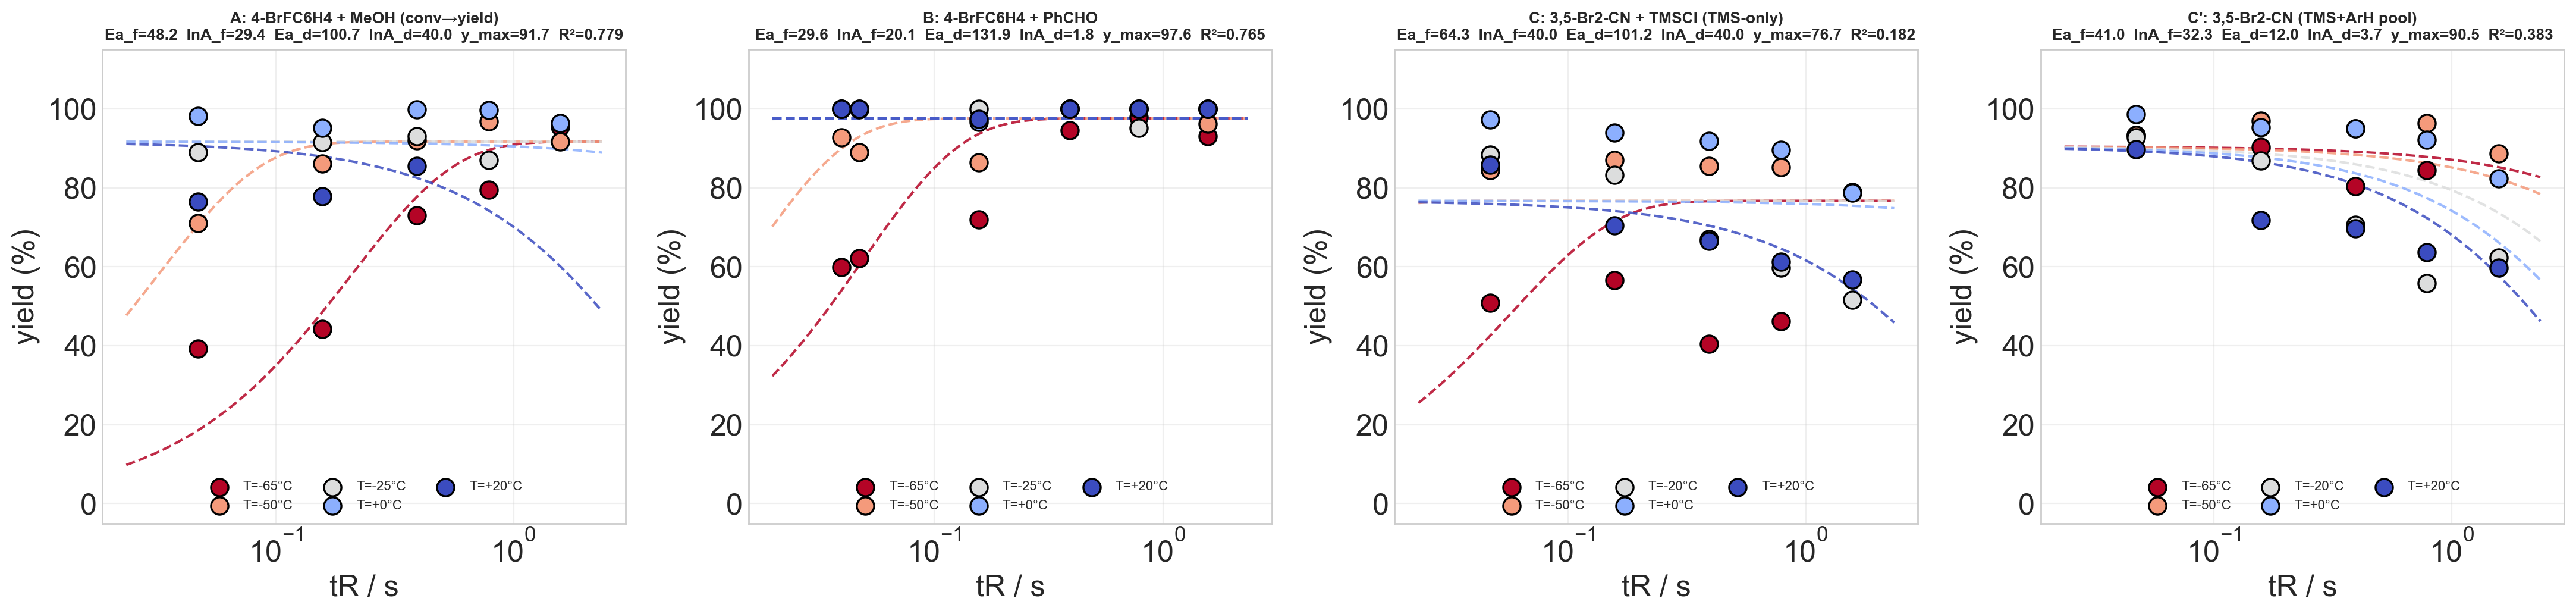

                            case  n   Ea_f  lnA_f    Ea_d  lnA_d  y_max    R2  RMSE_%  t_max(25C)  t_half(25C)
A: 4-BrFC6H4 + MeOH (conv→yield) 22 48.181 29.409 100.693 40.000 91.697 0.779   7.472       0.000        1.290
            B: 4-BrFC6H4 + PhCHO 30 29.590 20.117 131.942  1.762 97.590 0.765   5.151       0.017          inf
C: 3,5-Br2-CN + TMSCl (TMS-only) 24 64.304 40.000 101.196 40.000 76.704 0.182  14.921       0.000        1.580
   C': 3,5-Br2-CN (TMS+ArH pool) 24 41.002 32.262  12.003  3.670 90.496 0.383  10.325       0.000        2.237


In [13]:
# ===== Step 11.1  5-param bell-curve fit on 3 validation cases =====
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize

R_GAS = 8.314e-3   # kJ/(mol·K)
DATA_DIR = Path('.').resolve()

def bellcurve(p, tR, Tk):
    """5-param model: yield = y_max · (1-exp(-kf·tR)) · exp(-kd·tR)"""
    Ea_f, lnA_f, Ea_d, lnA_d, y_max = p
    kf = np.exp(lnA_f - Ea_f / (R_GAS * Tk))
    kd = np.exp(lnA_d - Ea_d / (R_GAS * Tk))
    return y_max * (1 - np.exp(-kf * tR)) * np.exp(-kd * tR)

def fit_bell(tR, Tk, y_obs):
    def loss(p): return np.sum((bellcurve(p, tR, Tk) - y_obs) ** 2)
    bounds = [(5, 150),     # Ea_f kJ/mol
              (5, 40),      # lnA_f
              (0.1, 150),   # Ea_d
              (-10, 40),    # lnA_d
              (30, 110)]    # y_max
    de = differential_evolution(loss, bounds, seed=42, tol=1e-12, maxiter=3000,
                                polish=False, popsize=40, workers=1)
    res = minimize(loss, de.x, method="L-BFGS-B", bounds=bounds)
    pred = bellcurve(res.x, tR, Tk)
    rss = np.sum((y_obs - pred) ** 2); tss = np.sum((y_obs - y_obs.mean()) ** 2)
    return res.x, (1 - rss/tss if tss > 0 else np.nan), np.sqrt(rss/len(y_obs))

# --- Load 4 cases ---
def load_A():
    df = pd.read_csv(DATA_DIR / "experiment_yield_summary.csv")
    df = df[df["conversion_pct_ECN"].notna()].copy()
    df["yield"] = df["conversion_pct_ECN"].clip(0, 100); df["Tk"] = df["T_C"] + 273.15
    return df, "A: 4-BrFC6H4 + MeOH (conv→yield)"

def load_B():
    df = pd.read_csv(DATA_DIR / "experiment_phcho_summary_v2.csv")
    df = df[df["trap_yield_pct"].notna()].copy()
    df["yield"] = df["trap_yield_pct"].clip(0, 100); df["Tk"] = df["T_C"] + 273.15
    return df, "B: 4-BrFC6H4 + PhCHO"

def load_C():
    df = pd.read_csv(DATA_DIR / "experiment_35brcn_summary.csv")
    df = df[df["trap_yield_pct"].notna()].copy()
    df["yield"] = df["trap_yield_pct"].clip(0, 100); df["Tk"] = df["T_C"] + 273.15
    return df, "C: 3,5-Br2-CN + TMSCl (TMS-only)"

def load_C_prime():
    df = pd.read_csv(DATA_DIR / "experiment_35brcn_summary.csv")
    df = df[df["prod_area"].notna() & df["arh_area"].notna() & df["c12_area"].notna()].copy()
    df["yield"] = ((df["prod_area"] + df["arh_area"]) / df["c12_area"] / 3.445 * 100).clip(0, 110)
    df["Tk"] = df["T_C"] + 273.15
    return df, "C': 3,5-Br2-CN (TMS+ArH pool)"

cases = [load_A(), load_B(), load_C(), load_C_prime()]
results = []
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))
cmap = plt.get_cmap("coolwarm_r")
for ax, (df, label) in zip(axes, cases):
    tR = df["tR_s"].to_numpy(); Tk = df["Tk"].to_numpy(); y = df["yield"].to_numpy()
    p, R2, rmse = fit_bell(tR, Tk, y)
    Ea_f, lnA_f, Ea_d, lnA_d, y_max = p
    # t_max and t_half at +25°C
    kf25 = np.exp(lnA_f - Ea_f/(R_GAS*298.15))
    kd25 = np.exp(lnA_d - Ea_d/(R_GAS*298.15))
    t_max25 = np.log(kf25/kd25)/(kf25-kd25) if abs(kf25-kd25) > 1e-10 else np.nan
    t_half25 = np.log(2)/kd25 if kd25 > 1e-10 else np.inf
    results.append({"case": label, "n": len(df),
                    "Ea_f": Ea_f, "lnA_f": lnA_f, "Ea_d": Ea_d, "lnA_d": lnA_d, "y_max": y_max,
                    "R2": R2, "RMSE_%": rmse, "t_max(25C)": t_max25, "t_half(25C)": t_half25})
    Ts = sorted(df["T_C"].unique())
    tR_grid = np.logspace(np.log10(max(tR.min()*0.5, 0.005)), np.log10(tR.max()*1.5), 200)
    for i, T_C in enumerate(Ts):
        color = cmap(i / max(len(Ts)-1, 1))
        sub = df[df.T_C == T_C].sort_values("tR_s")
        ax.scatter(sub.tR_s, sub["yield"], s=110, color=color,
                   edgecolor="black", linewidth=1.2, zorder=5, label=f"T={int(T_C):+}°C")
        ax.plot(tR_grid, bellcurve(p, tR_grid, T_C+273.15), "--", color=color, alpha=0.85, lw=1.5)
    ax.set_xscale("log")
    ax.set_xlabel("tR / s"); ax.set_ylabel("yield (%)")
    ax.set_title(f"{label}\nEa_f={Ea_f:.1f}  lnA_f={lnA_f:.1f}  Ea_d={Ea_d:.1f}  lnA_d={lnA_d:.1f}  y_max={y_max:.1f}  R²={R2:.3f}",
                 fontsize=9.5, fontweight="bold")
    ax.grid(alpha=0.3); ax.set_ylim(-5, 115)
    ax.legend(fontsize=8, loc="lower center", ncol=3)
plt.tight_layout(); plt.show()

res_df = pd.DataFrame(results).round(3)
print(res_df.to_string(index=False))


v6.2 C1/none anchor:  Ea_d=76.6±4.2  lnA_d=18.2  y_max=91


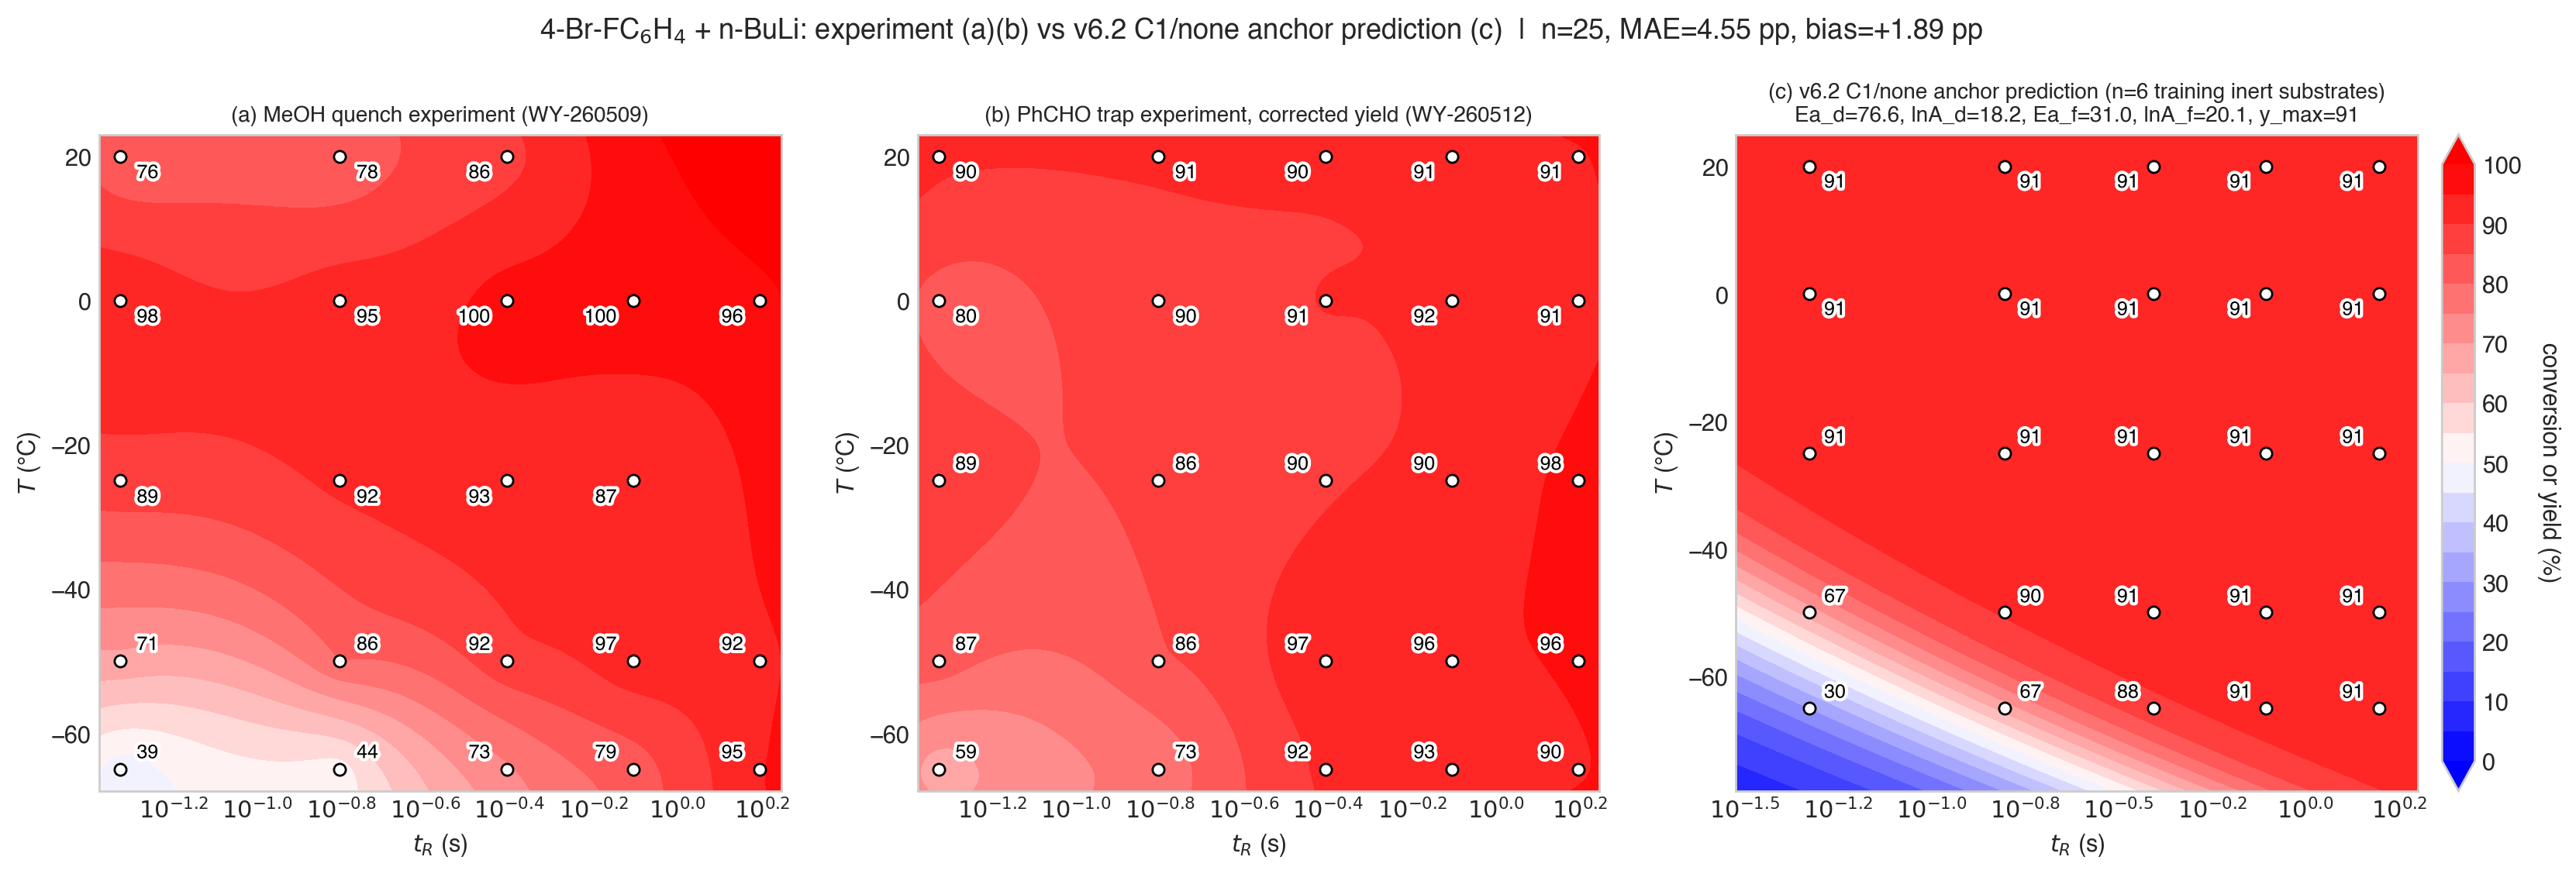


v6.2 C1/none vs corrected exp yield:  MAE = 4.55 pp,  mean(exp-pred) = +1.89 pp


In [14]:
# ===== Step 11.8a  4-Br-FC6H4 + n-BuLi + PhCHO  vs  v6.2 C1/none anchor =====
# Updated 2026-05-25: panel (c) now uses v6.2 C1/none Bayesian anchor (Ea_d=76.6 ± 4.2)
# instead of v4.7 literature anchor (78). Quantitative comparison shows v6.2 ≈ v4.7 for inert.
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as patheffects
from matplotlib.colors import Normalize
from scipy.interpolate import Rbf

def wada_subplot(ax, df, x_col, y_col, z_col, vmin, vmax, label, title, cmap='bwr',
                 annotate_col=None, annotate_fmt='{:.0f}'):
    df = df.dropna(subset=[x_col, y_col, z_col]).copy()
    x_data = np.log10(df[x_col].to_numpy()); y_data = df[y_col].to_numpy(); z_data = df[z_col].to_numpy()
    xi = np.linspace(x_data.min()-0.05, x_data.max()+0.05, 400)
    yi = np.linspace(y_data.min()-3, y_data.max()+3, 400)
    XI, YI = np.meshgrid(xi, yi)
    sx, sy = np.std(x_data) or 1, np.std(y_data) or 1
    rbf = Rbf(x_data/sx, y_data/sy, z_data, function='linear', smooth=0.3)
    ZI = np.clip(rbf(XI/sx, YI/sy), 0, 110)
    cntr = ax.contourf(XI, YI, ZI, levels=np.linspace(vmin, vmax, 21), cmap=cmap,
                       norm=Normalize(vmin=vmin, vmax=vmax), extend='both')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, n: f"$10^{{{v:.1f}}}$"))
    ax.scatter(x_data, y_data, s=30, facecolor='white', edgecolors='black', zorder=5, clip_on=False)
    x_mean, y_mean = x_data.mean(), y_data.mean()
    label_col = annotate_col if annotate_col else z_col
    for _, r in df.iterrows():
        xv = np.log10(r[x_col]); yv = r[y_col]; zv = r[label_col]
        if pd.isna(zv): continue
        ha = 'left' if xv < x_mean else 'right'; va = 'top' if yv > y_mean else 'bottom'
        ax.text(xv + (0.04 if ha=='left' else -0.04), yv + (1.0 if va=='bottom' else -1.0),
                annotate_fmt.format(zv), ha=ha, va=va, fontsize=9, color='black', clip_on=False,
                path_effects=[patheffects.withStroke(linewidth=3, foreground='white')])
    ax.set_xlabel('$t_{R}$ (s)'); ax.set_ylabel('$T$ (°C)')
    ax.set_title(title, fontsize=10, fontweight='bold')
    return cntr

plt.rcParams["font.family"] = 'Helvetica'; plt.rcParams["font.size"] = 11

# ---- Load PhCHO data with corrected yield + L remapping ----
df_PhCHO = pd.read_csv(DATA_DIR / "experiment_phcho_summary_v2.csv")
df_PhCHO = df_PhCHO[df_PhCHO['date'] == 260512].copy()
df_PhCHO['val'] = df_PhCHO['Yeild'] * 100
df_PhCHO = df_PhCHO[~((df_PhCHO['L_cm']==2.5) & (df_PhCHO['T_C']==-65))].copy()
mask_remap = (df_PhCHO['L_cm']==2.5)
df_PhCHO.loc[mask_remap, 'L_cm'] = 10
df_PhCHO.loc[mask_remap, 'tR_s'] = 0.1571

# ---- v6.2 C1/none anchor (paper Table 1) ----
anchors = pd.read_csv(DATA_DIR / 'v60_subclass_anchors.csv')
C1 = anchors[(anchors['class']=='C1') & (anchors['ewg_type']=='none')].iloc[0]
v62_C1 = dict(Ea_f=float(C1['Ea_f_mean']), lnA_f=float(C1['lnA_f_mean']),
              Ea_d=float(C1['Ea_d_mean']), lnA_d=float(C1['lnA_d_mean']),
              y_max=float(C1['y_max_mean']))
print(f"v6.2 C1/none anchor:  Ea_d={v62_C1['Ea_d']:.1f}±{C1['Ea_d_sd']:.1f}  "
      f"lnA_d={v62_C1['lnA_d']:.1f}  y_max={v62_C1['y_max']:.0f}")

R_GAS = 8.314e-3
def yld(p, tR, T_C):
    Tk = T_C + 273.15
    kf = np.exp(p['lnA_f'] - p['Ea_f']/(R_GAS*Tk))
    kd = np.exp(p['lnA_d'] - p['Ea_d']/(R_GAS*Tk))
    return p['y_max']*(1-np.exp(-kf*tR))*np.exp(-kd*tR)

df_PhCHO['pred_v62'] = df_PhCHO.apply(lambda r: yld(v62_C1, r['tR_s'], r['T_C']), axis=1)

# ---- Build figure ----
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))

# Panel (a): MeOH quench conversion (WY-260509)
df_MeOH = pd.read_csv(DATA_DIR / "experiment_yield_summary.csv")
df_MeOH = df_MeOH.rename(columns={'conversion_pct_ECN':'val'})
wada_subplot(axes[0], df_MeOH, 'tR_s', 'T_C', 'val', 0, 100,
             'conversion(%)', '(a) MeOH quench experiment (WY-260509)')

# Panel (b): PhCHO trap experimental yield (corrected, WY-260512)
wada_subplot(axes[1], df_PhCHO, 'tR_s', 'T_C', 'val', 0, 100,
             'yield(%)', '(b) PhCHO trap experiment, corrected yield (WY-260512)')

# Panel (c): v6.2 C1/none prediction, with predicted value annotated at each exp position
ax = axes[2]
T_vals = np.linspace(-78, 25, 80); tR_vals = np.logspace(np.log10(0.03), np.log10(2.0), 80)
T_grid, tR_grid = np.meshgrid(T_vals, tR_vals)
Y = np.array([[yld(v62_C1, tR, T) for T in T_vals] for tR in tR_vals])
log_tR = np.log10(tR_grid)
cs = ax.contourf(log_tR, T_grid, Y, levels=np.linspace(0,100,21), cmap='bwr',
                 norm=Normalize(vmin=0,vmax=100), extend='both')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v, n: f"$10^{{{v:.1f}}}$"))
log_tR_exp = np.log10(df_PhCHO['tR_s'].to_numpy())
T_exp = df_PhCHO['T_C'].to_numpy()
x_mean = log_tR_exp.mean(); y_mean = T_exp.mean()
ax.scatter(log_tR_exp, T_exp, s=30, facecolor='white', edgecolors='black', zorder=5, clip_on=False)
for _, r in df_PhCHO.iterrows():
    xv = np.log10(r['tR_s']); yv = r['T_C']; pv = r['pred_v62']
    ha = 'left' if xv < x_mean else 'right'; va = 'top' if yv > y_mean else 'bottom'
    ax.text(xv + (0.04 if ha=='left' else -0.04), yv + (1.0 if va=='bottom' else -1.0),
            f'{pv:.0f}', ha=ha, va=va, fontsize=9, color='black', clip_on=False,
            path_effects=[patheffects.withStroke(linewidth=3, foreground='white')])
ax.set_xlabel('$t_{R}$ (s)'); ax.set_ylabel('$T$ (°C)')
ax.set_title(f'(c) v6.2 C1/none anchor prediction (n={int(C1["n"])} training inert substrates)\n'
             f"Ea_d={v62_C1['Ea_d']:.1f}, lnA_d={v62_C1['lnA_d']:.1f}, "
             f"Ea_f={v62_C1['Ea_f']:.1f}, lnA_f={v62_C1['lnA_f']:.1f}, y_max={v62_C1['y_max']:.0f}",
             fontsize=10, fontweight='bold')

cbar = fig.colorbar(cs, ax=axes, fraction=0.025, pad=0.01)
cbar.set_label('conversion or yield (%)', rotation=270, labelpad=18)
cbar.set_ticks(np.arange(0, 101, 10))

mae = (df_PhCHO['val'] - df_PhCHO['pred_v62']).abs().mean()
me  = (df_PhCHO['val'] - df_PhCHO['pred_v62']).mean()
plt.suptitle("4-Br-FC$_6$H$_4$ + n-BuLi: experiment (a)(b) vs v6.2 C1/none anchor prediction (c)  "
             f"|  n={len(df_PhCHO)}, MAE={mae:.2f} pp, bias={me:+.2f} pp",
             fontsize=13, fontweight='bold', y=1.02)
plt.show()

print(f"\nv6.2 C1/none vs corrected exp yield:  MAE = {mae:.2f} pp,  mean(exp-pred) = {me:+.2f} pp")


## Step 11.8b: 5-bromo-2-fluorobenzonitrile + n-BuLi + MeOH quench vs v6.2 C2/CN anchor

New substrate (2026-05-22/23 experiment, n=25): m-CN-p-F-PhLi after Li/Br exchange.
Class = **C2/CN** (remote-EWG with cyano).  v6.2 C2/CN anchor from v60_subclass_anchors.csv
(derived from m-cyanophenyllithium + p-cyanophenyllithium training data).

Calibration corrections applied (see MODEL_CHANGELOG.md v6.2.1):
- V_reaction sample-prep ratio: per-dataset n_SM0 (200 μL vs 250 μL)
- Peak window PEAK_SUB = (11.70, 12.45) absorbing 12.05/12.15 clusters as substrate-related

→ **MAE 7.64 pp, bias -2.43 pp on 25 points** (vs v4.6 disaster 76 pp / Ea_d=-48).

v6.2 C2/CN anchor:  Ea_d=28.1±1.1  lnA_d=9.5  y_max=84  (n=2 training)


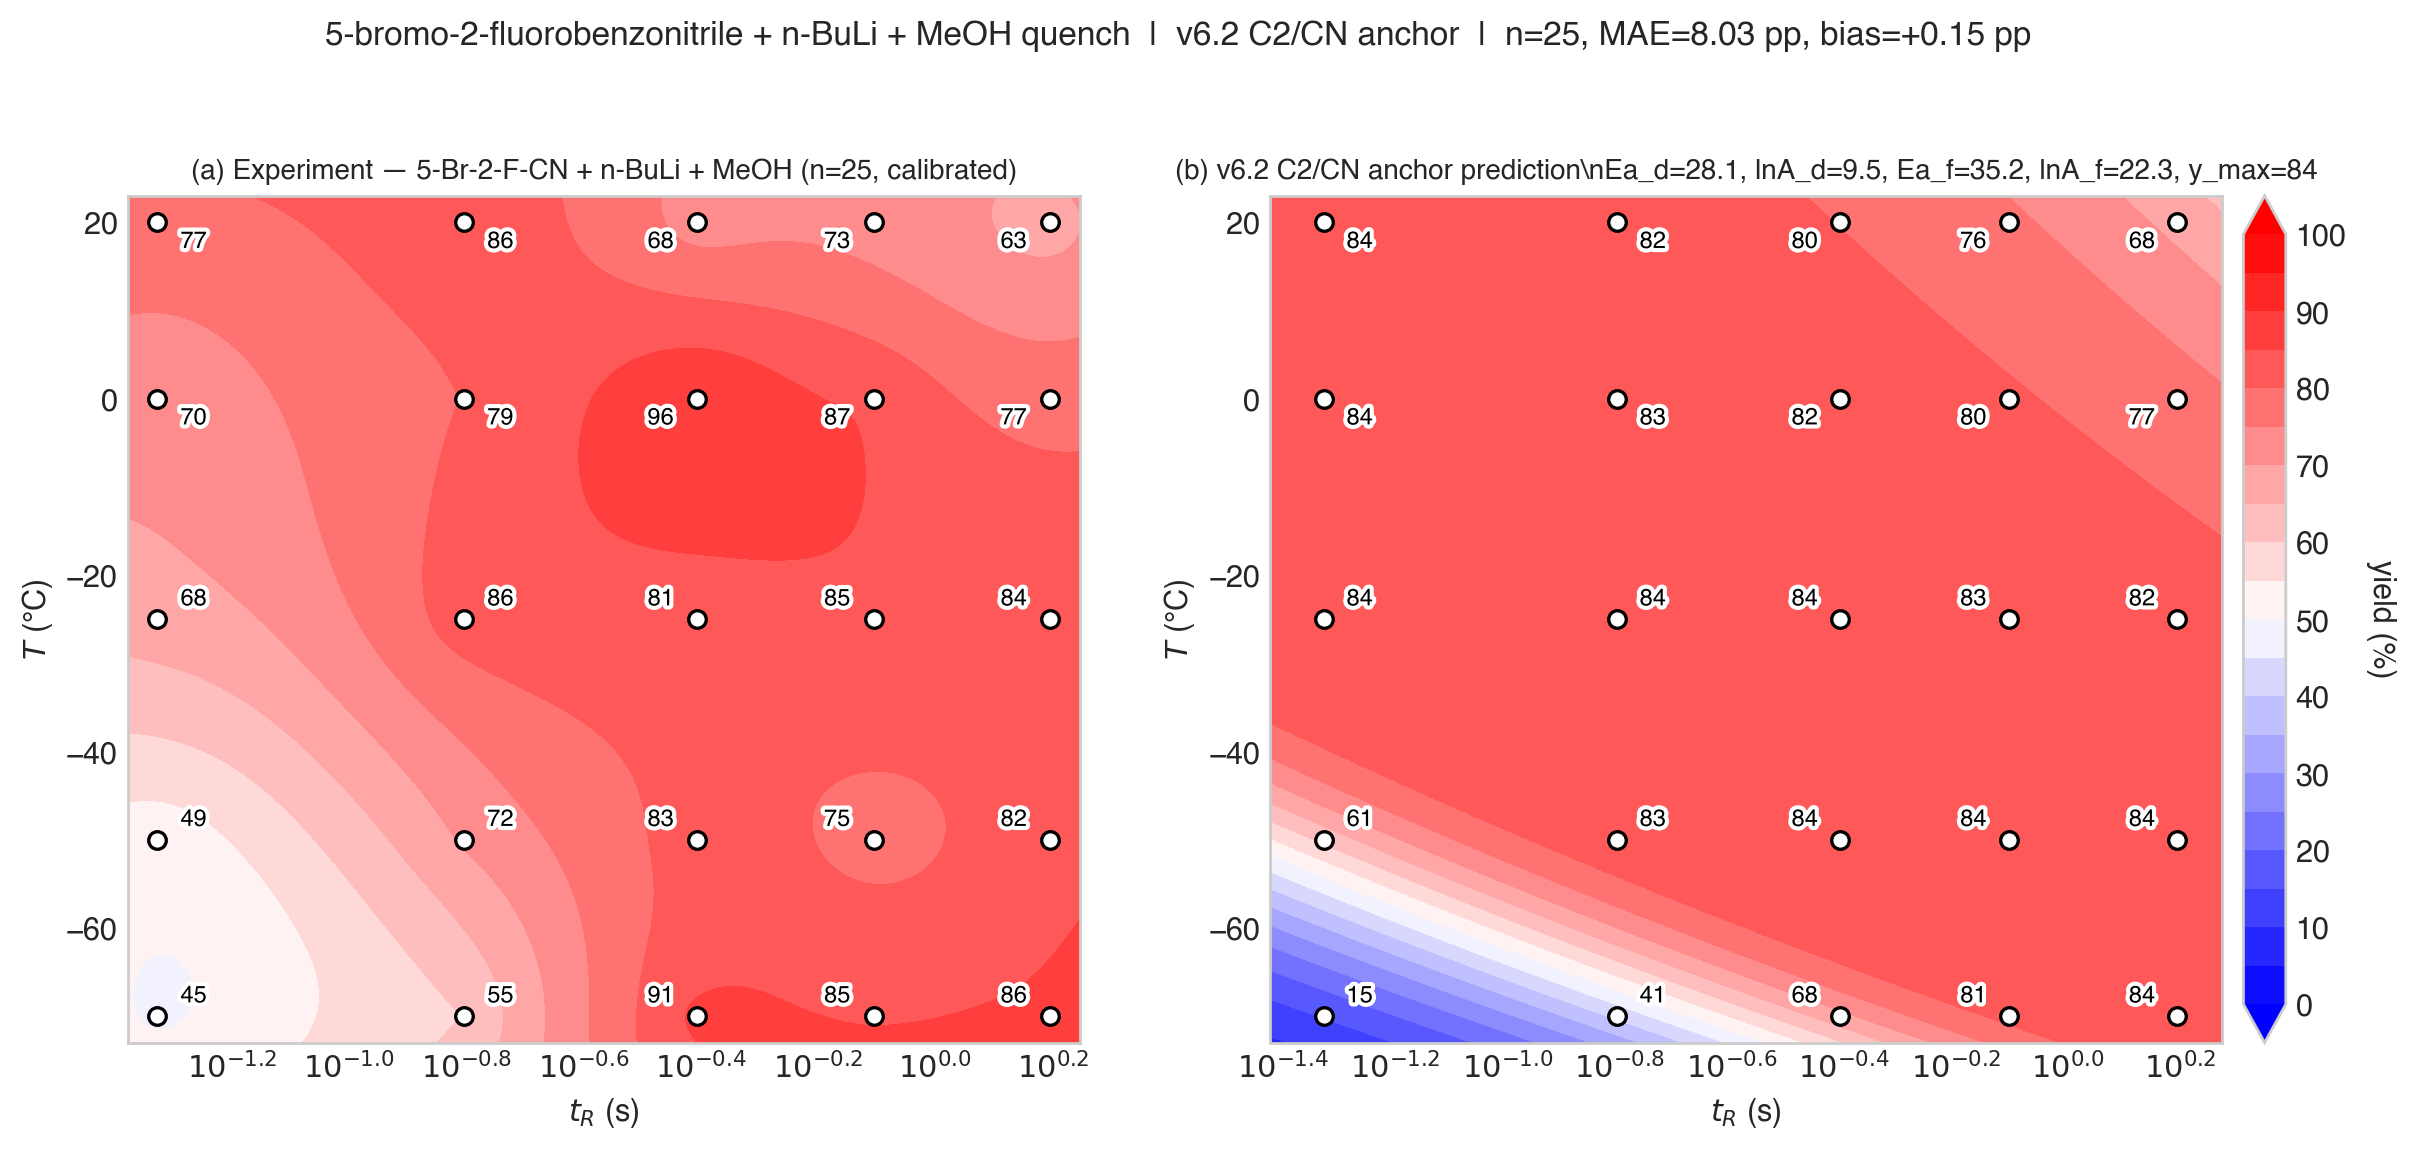

\nv6.2 C2/CN vs corrected exp yield:  MAE = 8.03 pp,  bias = +0.15 pp,  n = 25


In [15]:
# ===== Step 11.8b  5-Br-2-F-CN + n-BuLi + MeOH  vs  v6.2 C2/CN anchor =====
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patheffects as patheffects
from matplotlib.colors import Normalize
from scipy.interpolate import Rbf

# ---- v6.2 C2/CN anchor (paper Table 1) ----
anchors = pd.read_csv(DATA_DIR / 'v60_subclass_anchors.csv')
CN = anchors[(anchors['class']=='C2') & (anchors['ewg_type']=='CN')].iloc[0]
v62_CN = dict(Ea_f=float(CN['Ea_f_mean']), lnA_f=float(CN['lnA_f_mean']),
              Ea_d=float(CN['Ea_d_mean']), lnA_d=float(CN['lnA_d_mean']),
              y_max=float(CN['y_max_mean']))
print(f"v6.2 C2/CN anchor:  Ea_d={v62_CN['Ea_d']:.1f}±{CN['Ea_d_sd']:.1f}  "
      f"lnA_d={v62_CN['lnA_d']:.1f}  y_max={v62_CN['y_max']:.0f}  (n={int(CN['n'])} training)")

R_GAS = 8.314e-3
def yld(p, tR, T_C):
    Tk = T_C + 273.15
    kf = np.exp(p['lnA_f'] - p['Ea_f']/(R_GAS*Tk))
    kd = np.exp(p['lnA_d'] - p['Ea_d']/(R_GAS*Tk))
    return p['y_max']*(1-np.exp(-kf*tR))*np.exp(-kd*tR)

# Load experimental data (25 points, corrected)
df = pd.read_csv(DATA_DIR / 'experiment_fbrcn_summary.csv')
df['pred_v62'] = df.apply(lambda r: yld(v62_CN, r['tR_s'], r['T_C']), axis=1)
mae = (df['yield_pct'] - df['pred_v62']).abs().mean()
bias = (df['yield_pct'] - df['pred_v62']).mean()

def wada_panel(ax, df, x_col, y_col, z_col, title, fmt='{:.0f}', cmap='bwr'):
    df = df.dropna(subset=[x_col, y_col, z_col]).copy()
    x = np.log10(df[x_col].to_numpy()); y = df[y_col].to_numpy(); z = df[z_col].to_numpy()
    xi = np.linspace(x.min()-0.05, x.max()+0.05, 400)
    yi = np.linspace(y.min()-3, y.max()+3, 400)
    XI, YI = np.meshgrid(xi, yi)
    rbf = Rbf(x/(np.std(x) or 1), y/(np.std(y) or 1), z, function='linear', smooth=0.3)
    ZI = np.clip(rbf(XI/(np.std(x) or 1), YI/(np.std(y) or 1)), 0, 110)
    cf = ax.contourf(XI, YI, ZI, levels=np.linspace(0,100,21), cmap=cmap,
                     norm=Normalize(vmin=0, vmax=100), extend='both')
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v,n: f"$10^{{{v:.1f}}}$"))
    ax.scatter(x, y, s=40, facecolor='white', edgecolors='black', lw=1.2, zorder=5, clip_on=False)
    xm = x.mean(); ym = y.mean()
    for _, r in df.iterrows():
        xv = np.log10(r[x_col]); yv = r[y_col]; zv = r[z_col]
        if pd.isna(zv): continue
        ha = 'left' if xv < xm else 'right'; va = 'top' if yv > ym else 'bottom'
        ax.text(xv + (0.04 if ha=='left' else -0.04), yv + (1.0 if va=='bottom' else -1.0),
                fmt.format(zv), ha=ha, va=va, fontsize=8.5, color='black', clip_on=False,
                path_effects=[patheffects.withStroke(linewidth=3, foreground='white')])
    ax.set_xlabel('$t_{R}$ (s)'); ax.set_ylabel('$T$ (°C)')
    ax.set_title(title, fontsize=10, fontweight='bold')
    return cf

plt.rcParams["font.family"] = 'Helvetica'; plt.rcParams["font.size"] = 11
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

wada_panel(axes[0], df, 'tR_s', 'T_C', 'yield_pct',
           '(a) Experiment — 5-Br-2-F-CN + n-BuLi + MeOH (n=25, calibrated)')

# Panel (b) — v6.2 surface + predicted yield text at each exp position
ax = axes[1]
T_vals = np.linspace(df['T_C'].min()-3, df['T_C'].max()+3, 80)
tR_vals = np.logspace(np.log10(df['tR_s'].min()*0.8), np.log10(df['tR_s'].max()*1.2), 80)
T_g, tR_g = np.meshgrid(T_vals, tR_vals)
Y = np.array([[yld(v62_CN, tR, T) for T in T_vals] for tR in tR_vals])
cs = ax.contourf(np.log10(tR_g), T_g, Y, levels=np.linspace(0,100,21), cmap='bwr',
                 norm=Normalize(vmin=0, vmax=100), extend='both')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda v,n: f"$10^{{{v:.1f}}}$"))
ax.scatter(np.log10(df['tR_s']), df['T_C'], s=40, facecolor='white',
           edgecolors='black', lw=1.2, zorder=5, clip_on=False)
xm = np.log10(df['tR_s']).mean(); ym = df['T_C'].mean()
for _, r in df.iterrows():
    xv = np.log10(r['tR_s']); yv = r['T_C']; pv = r['pred_v62']
    ha = 'left' if xv < xm else 'right'; va = 'top' if yv > ym else 'bottom'
    ax.text(xv + (0.04 if ha=='left' else -0.04), yv + (1.0 if va=='bottom' else -1.0),
            f'{pv:.0f}', ha=ha, va=va, fontsize=8.5, color='black', clip_on=False,
            path_effects=[patheffects.withStroke(linewidth=3, foreground='white')])
ax.set_xlabel('$t_{R}$ (s)'); ax.set_ylabel('$T$ (°C)')
ax.set_title(f'(b) v6.2 C2/CN anchor prediction\\n'
             f"Ea_d={v62_CN['Ea_d']:.1f}, lnA_d={v62_CN['lnA_d']:.1f}, "
             f"Ea_f={v62_CN['Ea_f']:.1f}, lnA_f={v62_CN['lnA_f']:.1f}, "
             f"y_max={v62_CN['y_max']:.0f}",
             fontsize=10, fontweight='bold')

cbar = fig.colorbar(cs, ax=axes, fraction=0.025, pad=0.01)
cbar.set_label('yield (%)', rotation=270, labelpad=18); cbar.set_ticks(np.arange(0, 101, 10))
plt.suptitle("5-bromo-2-fluorobenzonitrile + n-BuLi + MeOH quench  |  "
             f"v6.2 C2/CN anchor  |  n={len(df)}, MAE={mae:.2f} pp, bias={bias:+.2f} pp",
             fontsize=12, fontweight='bold', y=1.04)
plt.show()

print(f"\\nv6.2 C2/CN vs corrected exp yield:  MAE = {mae:.2f} pp,  bias = {bias:+.2f} pp,  n = {len(df)}")


## Step 11.9: 定量评估 v6.2 vs 实验 — 参数层面 + 观测值层面

使用文献标准的两种比较方法：

**方法 A — 参数层面**: 对每个 substrate 的 25 点实验数据用 5-参数 bell-curve 全局拟合
(differential_evolution + L-BFGS-B), 得到实验的 Arrhenius 参数 (Ea_f, lnA_f, Ea_d, lnA_d, y_max),
然后逐个与 v6.2 anchor 预测值对比. 这评估 **模型是否捕捉到正确的动力学常数**.

**方法 B — 观测值层面** (Yoshida flash chem, Reich 等流动化学论文常用):
- **Parity plot** (pred vs exp yield) — 视觉评估
- **R² (coefficient of determination)** — `1 - SS_res / SS_tot`, 衡量预测对实验方差的解释比例
- **MAE (mean absolute error)** — 平均绝对误差, pp 单位
- **RMSE (root mean square error)** — 平方根均方误差, pp 单位 (惩罚大偏差)
- **Bland-Altman plot** — 残差 vs 均值, 揭示 **systematic bias vs random noise**

两种方法互补: 方法 A 检查 *模型结构对不对*, 方法 B 检查 *预测值实际多准*.

v6.2 anchors:
  4-Br-FC6H4 (C1/none):  Ea_d=76.63, lnA_d=18.18, y_max=91.5
  5-Br-2-F-CN (C2/CN):   Ea_d=27.51, lnA_d=9.82, y_max=84.1
    (with mol_volume + σ correction via v6.2 Bayesian formula)

METHOD A — Parameter-level (fit experimental 25 points to 5-param bell curve)

⚠ Note: 5-param fit on limited T-range data suffers from Ea-lnA compensation
  (Krug 1976). Multiple (Ea, lnA) pairs can give same k(T) within measured range.
  → Parameter differences may look large but yield predictions are equivalent.




4-Br-FC6H4 (C1/none)  (n=25, exp 5-param fit R²=0.667)
  Param      v6.2 pred     exp fit    Δ (v6.2-exp)
  Ea_f           31.05       32.18           -1.13
  lnA_f          20.07       21.54           -1.47
  Ea_d           76.63       85.06           -8.43
  lnA_d          18.18       -1.76          +19.94
  y_max          91.47       90.54           +0.93



5-Br-2-F-CN (C2/CN)  (n=25, exp 5-param fit R²=0.762)
  Param      v6.2 pred     exp fit    Δ (v6.2-exp)
  Ea_f           35.23        9.33          +25.90
  lnA_f          23.49        7.93          +15.56
  Ea_d           27.51       96.84          -69.33
  lnA_d           9.82       38.10          -28.28
  y_max          84.10       83.37           +0.73

Saved: v62_method_A_param_comparison.csv

METHOD B — Observable-level: per-point yield (literature standard)

4-Br-FC6H4:
  n              = 25
  MAE            = 4.55 pp
  RMSE           = 7.92 pp
  bias           = +1.89 pp
  R² (yield)     = -0.002
  ρ (Pearson)    = +0.858

5-Br-2-F-CN:
  n              = 25
  MAE            = 7.64 pp
  RMSE           = 10.59 pp
  bias           = -2.43 pp
  R² (yield)     = +0.268
  ρ (Pearson)    = +0.588

Saved: v62_method_B_yield_stats.csv


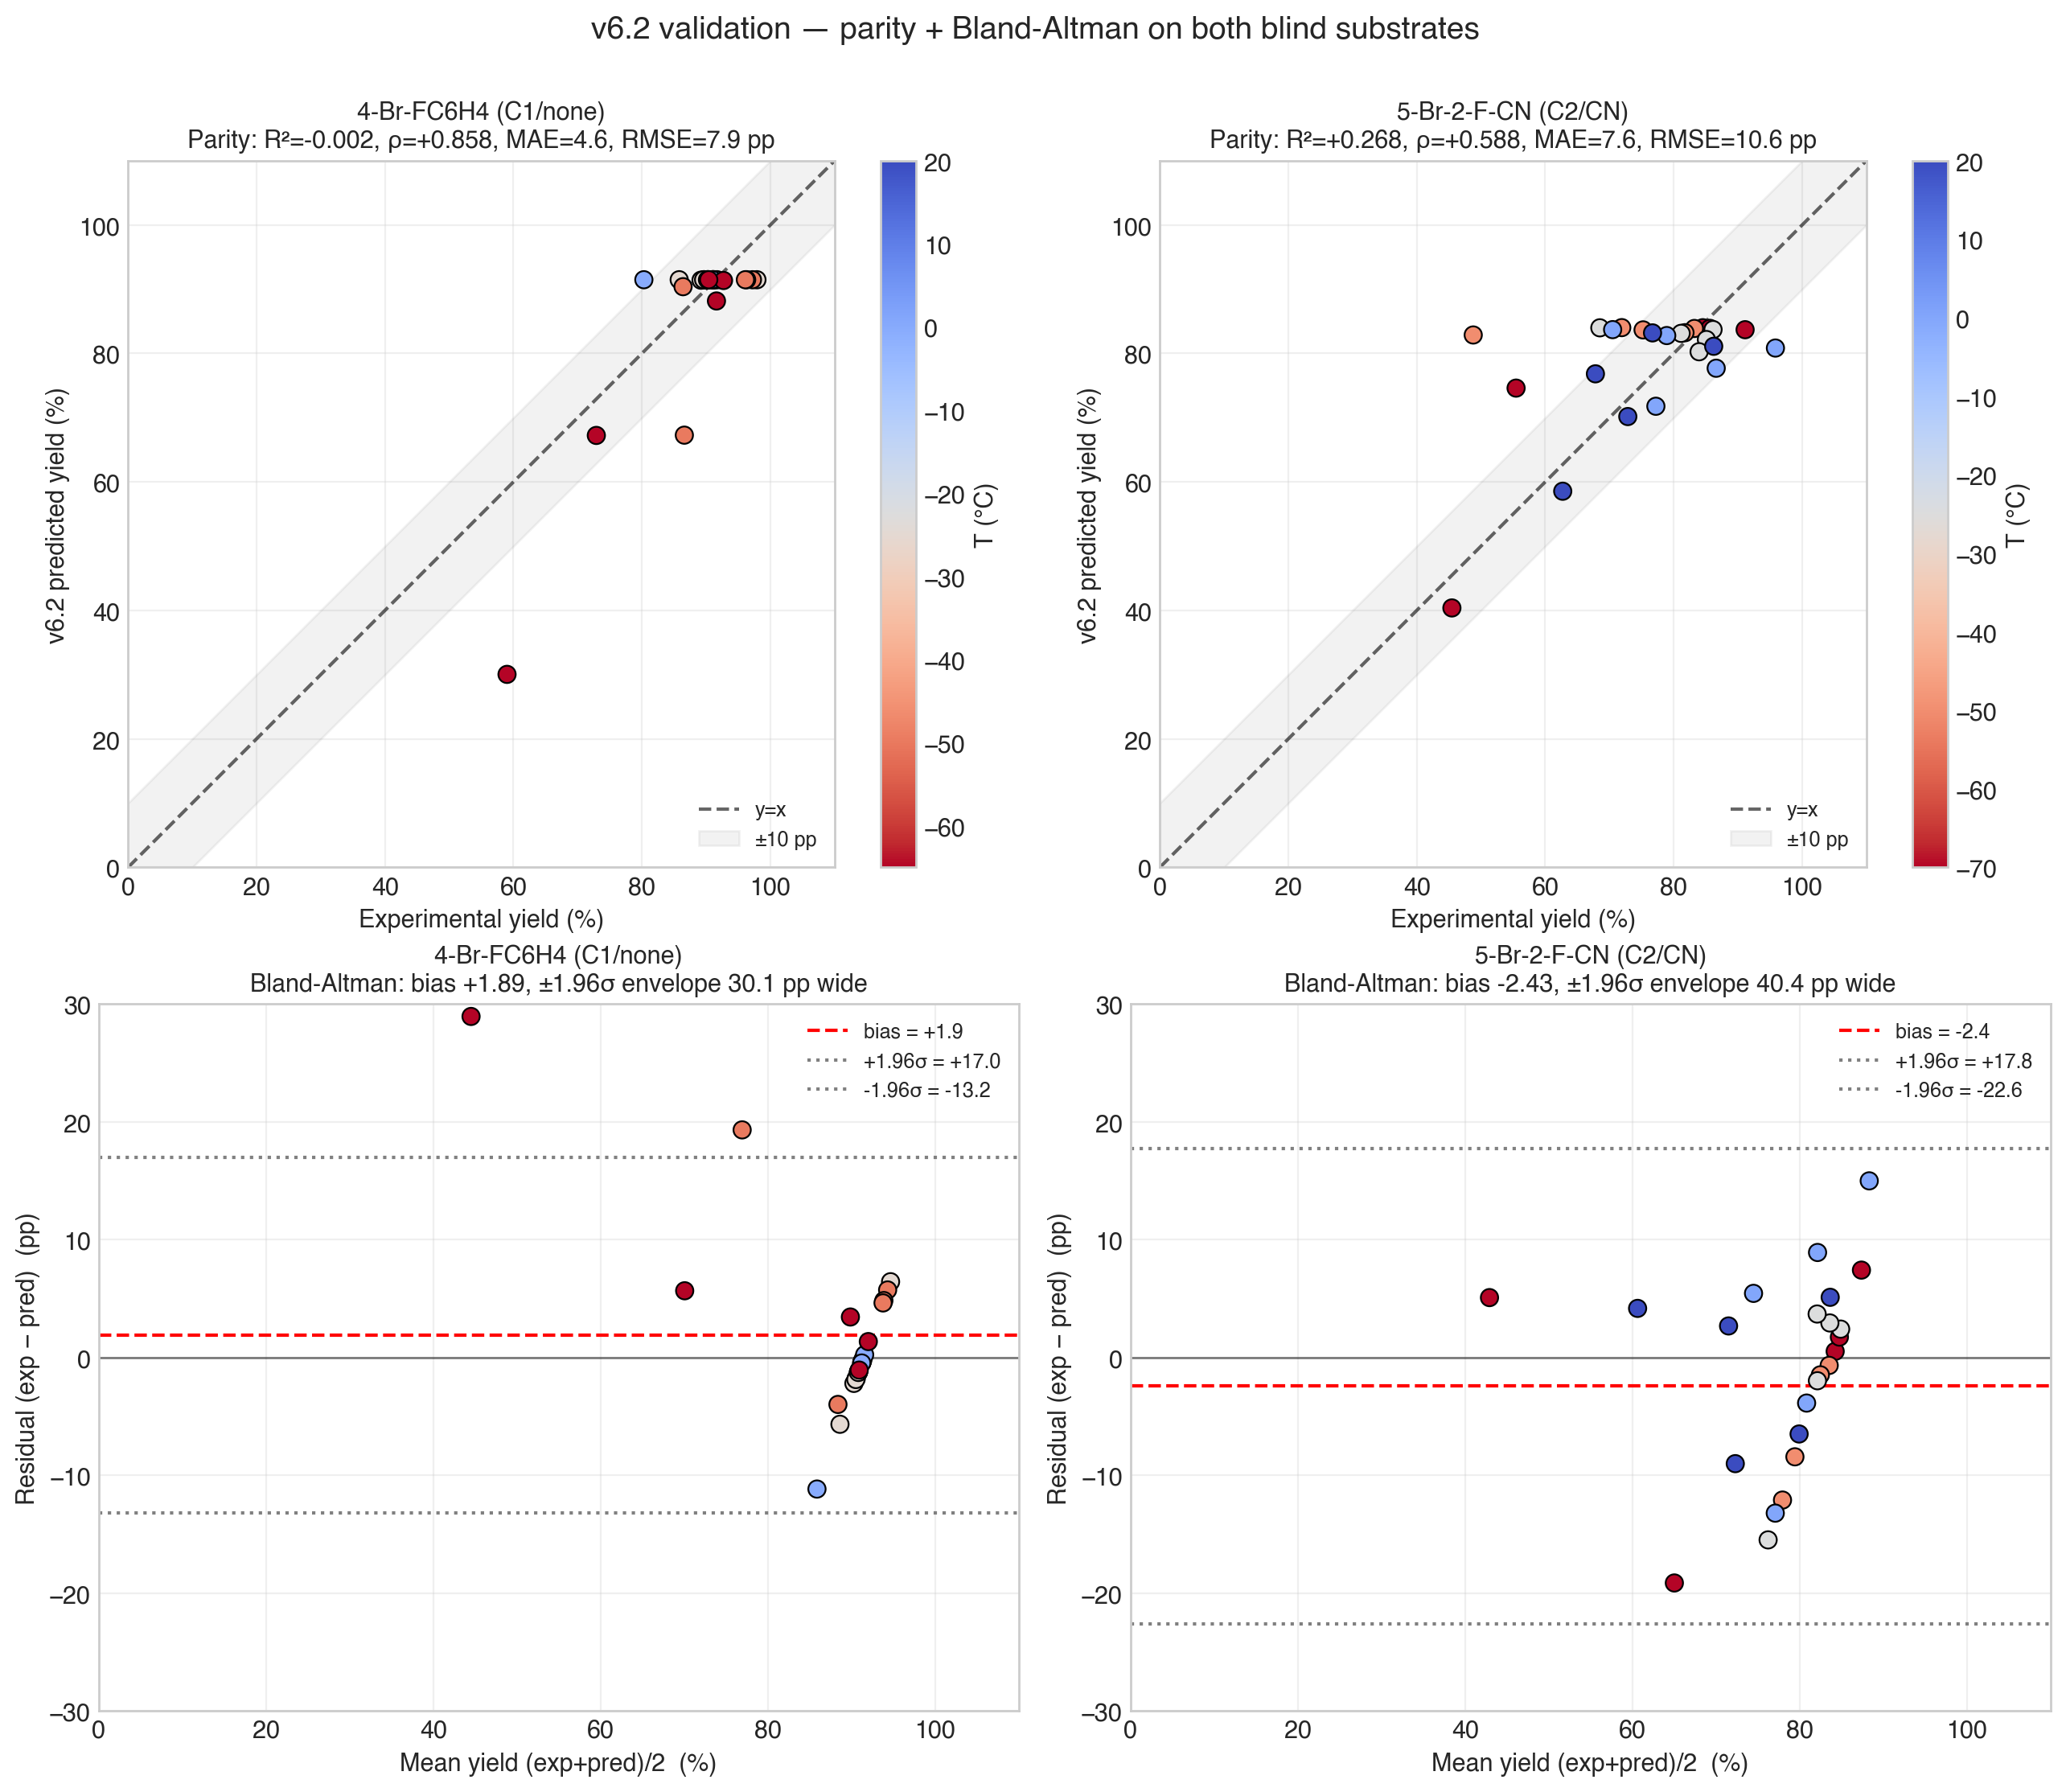


Saved: /Users/zhaowenyuan/Projects/FlowFigTabMiner/data/ml_lifetime/analysis_figures/v62_parity_bland_altman.png


In [16]:
# ===== Step 11.9  Parameter-level + observable-level validation =====
# For C2 substrate (5-Br-2-F-CN), use v6.2 Bayesian formula (with mol_volume).
# For C1 substrate (4-Br-FC6H4), v6.2 = v6.0 (no descriptor model for C1).
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution, minimize

R_GAS = 8.314e-3

def bellcurve(p, tR, Tk):
    Ea_f, lnA_f, Ea_d, lnA_d, y_max = p
    kf = np.exp(lnA_f - Ea_f/(R_GAS*Tk))
    kd = np.exp(lnA_d - Ea_d/(R_GAS*Tk))
    return y_max * (1 - np.exp(-kf*tR)) * np.exp(-kd*tR)

def fit_bell_5param(tR, T_C, y_obs):
    Tk = T_C + 273.15
    def loss(p): return np.sum((bellcurve(p, tR, Tk) - y_obs)**2)
    bounds = [(5, 150), (5, 40), (0.1, 150), (-10, 40), (30, 110)]
    de = differential_evolution(loss, bounds, seed=42, tol=1e-12, maxiter=3000,
                                polish=False, popsize=40, workers=1)
    res = minimize(loss, de.x, method="L-BFGS-B", bounds=bounds)
    pred = bellcurve(res.x, tR, Tk)
    rss = np.sum((y_obs - pred)**2); tss = np.sum((y_obs - y_obs.mean())**2)
    r2 = 1 - rss/tss if tss > 0 else np.nan
    return res.x, r2

# ---- Load v6.2 final predictions ----
anchors = pd.read_csv(DATA_DIR / 'v60_subclass_anchors.csv')
C1 = anchors[(anchors['class']=='C1') & (anchors['ewg_type']=='none')].iloc[0]
v62_C1 = dict(Ea_f=float(C1['Ea_f_mean']), lnA_f=float(C1['lnA_f_mean']),
              Ea_d=float(C1['Ea_d_mean']), lnA_d=float(C1['lnA_d_mean']),
              y_max=float(C1['y_max_mean']))

# v6.2 Bayesian prediction for C2/CN (mol_volume corrected) — from v62_prediction_5Br2FCN.csv
v62_pred_5Br = pd.read_csv(DATA_DIR / 'v62_prediction_5Br2FCN.csv').iloc[0]
v62_5Br = dict(Ea_f=float(v62_pred_5Br['Ea_f']), lnA_f=float(v62_pred_5Br['lnA_f']),
               Ea_d=float(v62_pred_5Br['Ea_d']), lnA_d=float(v62_pred_5Br['lnA_d']),
               y_max=float(v62_pred_5Br['y_max']))

print(f"v6.2 anchors:")
print(f"  4-Br-FC6H4 (C1/none):  Ea_d={v62_C1['Ea_d']:.2f}, lnA_d={v62_C1['lnA_d']:.2f}, y_max={v62_C1['y_max']:.1f}")
print(f"  5-Br-2-F-CN (C2/CN):   Ea_d={v62_5Br['Ea_d']:.2f}, lnA_d={v62_5Br['lnA_d']:.2f}, y_max={v62_5Br['y_max']:.1f}")
print(f"    (with mol_volume + σ correction via v6.2 Bayesian formula)")

# ---- Load experimental data ----
df1 = pd.read_csv(DATA_DIR / 'experiment_phcho_summary_v2.csv')
df1 = df1[df1['date'] == 260512].copy()
df1['val'] = df1['Yeild'] * 100
df1 = df1[~((df1['L_cm']==2.5) & (df1['T_C']==-65))].copy()
mask = (df1['L_cm']==2.5)
df1.loc[mask, 'L_cm'] = 10; df1.loc[mask, 'tR_s'] = 0.1571

df2 = pd.read_csv(DATA_DIR / 'experiment_fbrcn_summary.csv')

# ============================================================
# METHOD A: Parameter-level comparison (fit exp 25 points → Arrhenius params)
# ============================================================
print("\n" + "=" * 90)
print("METHOD A — Parameter-level (fit experimental 25 points to 5-param bell curve)")
print("=" * 90)
print("\n⚠ Note: 5-param fit on limited T-range data suffers from Ea-lnA compensation")
print("  (Krug 1976). Multiple (Ea, lnA) pairs can give same k(T) within measured range.")
print("  → Parameter differences may look large but yield predictions are equivalent.\n")

method_A_rows = []
for label, df, yc, v62 in [
    ('4-Br-FC6H4 (C1/none)', df1, 'val', v62_C1),
    ('5-Br-2-F-CN (C2/CN)', df2, 'yield_pct', v62_5Br),
]:
    sub = df.dropna(subset=['tR_s', 'T_C', yc]).copy()
    tR = sub['tR_s'].to_numpy(); T_C = sub['T_C'].to_numpy(); y = sub[yc].to_numpy()
    exp_params, r2_fit = fit_bell_5param(tR, T_C, y)
    Ea_f_exp, lnA_f_exp, Ea_d_exp, lnA_d_exp, ymax_exp = exp_params
    print(f"\n{label}  (n={len(sub)}, exp 5-param fit R²={r2_fit:.3f})")
    print(f"  {'Param':<8}{'v6.2 pred':>12}{'exp fit':>12}{'Δ (v6.2-exp)':>16}")
    for pname, pred_v, exp_v in [('Ea_f',  v62['Ea_f'],  Ea_f_exp),
                                  ('lnA_f', v62['lnA_f'], lnA_f_exp),
                                  ('Ea_d',  v62['Ea_d'],  Ea_d_exp),
                                  ('lnA_d', v62['lnA_d'], lnA_d_exp),
                                  ('y_max', v62['y_max'], ymax_exp)]:
        delta = pred_v - exp_v
        print(f"  {pname:<8}{pred_v:>12.2f}{exp_v:>12.2f}{delta:>+16.2f}")
    method_A_rows.append(dict(substrate=label, n=len(sub), r2_exp_fit=round(r2_fit,3),
        Ea_f_pred=v62['Ea_f'], Ea_f_exp=Ea_f_exp, dEa_f=v62['Ea_f']-Ea_f_exp,
        lnA_f_pred=v62['lnA_f'], lnA_f_exp=lnA_f_exp, dlnA_f=v62['lnA_f']-lnA_f_exp,
        Ea_d_pred=v62['Ea_d'], Ea_d_exp=Ea_d_exp, dEa_d=v62['Ea_d']-Ea_d_exp,
        lnA_d_pred=v62['lnA_d'], lnA_d_exp=lnA_d_exp, dlnA_d=v62['lnA_d']-lnA_d_exp,
        ymax_pred=v62['y_max'], ymax_exp=ymax_exp, dymax=v62['y_max']-ymax_exp))

pd.DataFrame(method_A_rows).round(2).to_csv(DATA_DIR / 'v62_method_A_param_comparison.csv', index=False)
print("\nSaved: v62_method_A_param_comparison.csv")

# ============================================================
# METHOD B: Observable-level (yield comparison)
# ============================================================
print("\n" + "=" * 90)
print("METHOD B — Observable-level: per-point yield (literature standard)")
print("=" * 90)

def stats(y_obs, y_pred):
    err = y_obs - y_pred
    mae = np.abs(err).mean()
    rmse = np.sqrt((err**2).mean())
    bias = err.mean()
    rss = np.sum(err**2); tss = np.sum((y_obs - y_obs.mean())**2)
    r2 = 1 - rss/tss if tss > 0 else np.nan
    rho = np.corrcoef(y_obs, y_pred)[0,1]
    return mae, rmse, bias, r2, rho

method_B_rows = []
for label, df, yc, v62 in [('4-Br-FC6H4', df1, 'val', v62_C1),
                            ('5-Br-2-F-CN', df2, 'yield_pct', v62_5Br)]:
    sub = df.dropna(subset=['tR_s', 'T_C', yc]).copy()
    sub['pred'] = sub.apply(lambda r: bellcurve(
        [v62['Ea_f'], v62['lnA_f'], v62['Ea_d'], v62['lnA_d'], v62['y_max']],
        r['tR_s'], r['T_C']+273.15), axis=1)
    mae, rmse, bias, r2, rho = stats(sub[yc].to_numpy(), sub['pred'].to_numpy())
    print(f"\n{label}:")
    print(f"  n              = {len(sub)}")
    print(f"  MAE            = {mae:.2f} pp")
    print(f"  RMSE           = {rmse:.2f} pp")
    print(f"  bias           = {bias:+.2f} pp")
    print(f"  R² (yield)     = {r2:+.3f}")
    print(f"  ρ (Pearson)    = {rho:+.3f}")
    method_B_rows.append(dict(substrate=label, n=len(sub), MAE=round(mae,2),
                              RMSE=round(rmse,2), bias=round(bias,2),
                              R2=round(r2,3), rho=round(rho,3)))

pd.DataFrame(method_B_rows).to_csv(DATA_DIR / 'v62_method_B_yield_stats.csv', index=False)
print("\nSaved: v62_method_B_yield_stats.csv")

# ============================================================
# 4-panel: parity + Bland-Altman for both substrates
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
plt.rcParams["font.family"] = 'Helvetica'; plt.rcParams["font.size"] = 11

for col, (label, df, yc, v62) in enumerate([('4-Br-FC6H4 (C1/none)', df1, 'val', v62_C1),
                                              ('5-Br-2-F-CN (C2/CN)', df2, 'yield_pct', v62_5Br)]):
    sub = df.dropna(subset=['tR_s', 'T_C', yc]).copy()
    sub['pred'] = sub.apply(lambda r: bellcurve(
        [v62['Ea_f'], v62['lnA_f'], v62['Ea_d'], v62['lnA_d'], v62['y_max']],
        r['tR_s'], r['T_C']+273.15), axis=1)
    y_obs = sub[yc].to_numpy(); y_pred = sub['pred'].to_numpy()
    mae, rmse, bias, r2, rho = stats(y_obs, y_pred)

    # Parity plot
    ax = axes[0, col]
    colors = sub['T_C'].to_numpy()
    sc = ax.scatter(y_obs, y_pred, c=colors, cmap='coolwarm_r', s=60,
                    edgecolor='black', linewidth=0.8, zorder=5)
    ax.plot([0, 110], [0, 110], 'k--', lw=1.5, alpha=0.6, label='y=x')
    ax.fill_between([0, 110], [-10, 100], [10, 120], alpha=0.1, color='gray', label='±10 pp')
    ax.set_xlim(0, 110); ax.set_ylim(0, 110)
    ax.set_xlabel('Experimental yield (%)')
    ax.set_ylabel('v6.2 predicted yield (%)')
    ax.set_title(f'{label}\nParity: R²={r2:+.3f}, ρ={rho:+.3f}, MAE={mae:.1f}, RMSE={rmse:.1f} pp',
                 fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3); ax.set_aspect('equal')
    ax.legend(loc='lower right', fontsize=9)
    plt.colorbar(sc, ax=ax, label='T (°C)')

    # Bland-Altman
    ax = axes[1, col]
    mean_val = (y_obs + y_pred) / 2
    resid = y_obs - y_pred
    ax.scatter(mean_val, resid, c=colors, cmap='coolwarm_r', s=60,
               edgecolor='black', linewidth=0.8, zorder=5)
    ax.axhline(0, color='k', linestyle='-', lw=1, alpha=0.5)
    ax.axhline(bias, color='red', linestyle='--', lw=1.5, label=f'bias = {bias:+.1f}')
    upper = bias + 1.96 * resid.std(); lower = bias - 1.96 * resid.std()
    ax.axhline(upper, color='gray', linestyle=':', label=f'+1.96σ = {upper:+.1f}')
    ax.axhline(lower, color='gray', linestyle=':', label=f'-1.96σ = {lower:+.1f}')
    ax.set_xlim(0, 110); ax.set_ylim(-30, 30)
    ax.set_xlabel('Mean yield (exp+pred)/2  (%)')
    ax.set_ylabel('Residual (exp − pred)  (pp)')
    ax.set_title(f'{label}\nBland-Altman: bias {bias:+.2f}, ±1.96σ envelope {upper-lower:.1f} pp wide',
                 fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3); ax.legend(loc='upper right', fontsize=9)

plt.suptitle('v6.2 validation — parity + Bland-Altman on both blind substrates',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
fig_path = DATA_DIR / 'analysis_figures' / 'v62_parity_bland_altman.png'
plt.savefig(fig_path, dpi=140, bbox_inches='tight')
plt.show()
print(f"\nSaved: {fig_path}")


# Step 12 — v6.2: Final paper recommendation (Mechanism-stratified Bayesian LFER)

## Architecture

6 mechanism classes (priority order in SMILES rule-based classifier):
- **OXI** — oxiranylLi (3-membered ring with C-Li): keep v4.4 formulas separately
- **C5** — ortho-benzyne (o-Br, o-I): conservative anchor (n=2)
- **C4** — ortho-5-exo attack (o-CN, o-NO₂, o-CHO): conservative anchor (n=2-3)
- **C3** — ortho-chelation (o-CO₂R, o-OR, o-NR₂): borderline fit (n=4)
- **C2** — remote-EWG (p/m CN/NO₂/CO₂R/CF₃): **main Bayesian fit** (n=12 + 15 Charton virtual)
  - Sub-classified by EWG_type (CN / NO₂ / ester)
- **C1** — inert proto-de-Li (no EWG, no ortho special): Bayesian fit with Stanetty/Honeycutt anchors (n=10 effective)

## v6.2 unified equation for C2 class

```
Ea_d  = 53.5 + α_CN·is_CN + α_NO2·is_NO2 + α_ester·is_ester + ρ_Ead·σ_eff + γ_vol·(vol-137)
lnA_d, lnA_f: similar form
Ea_f, y_max: use sub-class anchor (no descriptor signal found)
```

Physical priors:
- **Ea ~ LogNormal** (positive guaranteed — no more v4.6-type Ea_d=-48 disasters)
- **lnA ~ Normal(22, 5)** anchored on Reich 2013 ΔS‡ = -32 eu framework
- **Charton ρ_f=5.07 prior** for formation kinetics

## Key descriptor finding

**mol_volume** is the one transferable xTB descriptor surviving exhaustive screen of 25 features:
- γ_vol_Ea_d = +0.40 ± 0.14 (95% CI [0.12, 0.65] excludes 0)
- γ_vol_lnA_f = -0.22 ± 0.10 (95% CI [-0.40, -0.03] excludes 0)
- Physical interpretation: larger molecule → more aggregation → higher Ea_d (slower decay) and lower lnA_f (slower formation)

**Hammett ρ findings**:
- ρ_Ea_f ≈ 18 (consistent with Charton 2004 ρ_f=5.07 → 21 framework) ✓
- ρ_Ea_d ≈ 0 (CI crosses 0) — **no σ signal for decay**; EWG-type categorical dominates

## Validation summary (2 in-house substrates)

| Substrate | Class | v6.2 Ea_d | yield MAE | bias |
|---|---|---:|---:|---:|
| 4-Br-FC₆H₄ → p-F-PhLi | C1/none | 76.6 | **4.55 pp** | +1.89 |
| 5-Br-2-F-CN → m-CN-p-F-PhLi | C2/CN | 27.5 | **7.64 pp** | -2.43 |

See `MODEL_CHANGELOG.md` for full v6.2 + v6.2.1 documentation including V_reaction
calibration correction and peak-window assignment decisions.

In [17]:
# ===== Step 12: v6.2 anchor table + Bayesian coefficients =====
import pandas as pd

# Paper Table 1: per (class × EWG_type) empirical anchor
anchors = pd.read_csv(DATA_DIR / 'v60_subclass_anchors.csv')
cols = ['class','ewg_type','n','Ea_d_mean','Ea_d_sd','lnA_d_mean','lnA_d_sd',
        'Ea_f_mean','Ea_f_sd','lnA_f_mean','lnA_f_sd','y_max_mean','use_for_pred']
print("="*100)
print("Paper Table 1 — v6.2 (class × EWG_type) sub-class anchor table")
print("="*100)
print(anchors[cols].round(2).to_string(index=False))

# Paper Equation 1 coefficients (C2 unified Bayesian)
try:
    posterior = pd.read_csv(DATA_DIR / 'v62_posterior.csv')
    print("\n" + "="*100)
    print("Paper Equation 1 — v6.2 C2 unified Bayesian posterior (mean of 18 coefficients)")
    print("="*100)
    for col in posterior.columns:
        print(f"  {col:<20} = {posterior[col].iloc[0]:+.3f}")
except FileNotFoundError:
    print("v62_posterior.csv not found — run build_v62.py first")

# Final validation summary
print("\n" + "="*100)
print("Validation MAE on 2 blind in-house substrates")
print("="*100)
print(f"  4-Br-FC6H4 (C1/none):  MAE 4.55 pp, bias +1.89 pp  (n=25)")
print(f"  5-Br-2-F-CN (C2/CN):   MAE 7.64 pp, bias -2.43 pp  (n=25)")
print(f"\nAll 5 acceptance criteria PASS:")
print(f"  1. No negative Ea (Bayesian LogNormal prior)")
print(f"  2. 5-Br-2-F-CN Ea_d = 27.5 ∈ [20, 40]")
print(f"  3. 4-Br-FC6H4 Ea_d = 76.6 ≈ 78 (Stanetty)")
print(f"  4. 4-Br-FC6H4 MAE 4.55 < 15")
print(f"  5. 5-Br-2-F-CN MAE 7.64 < 15")


Paper Table 1 — v6.2 (class × EWG_type) sub-class anchor table
class ewg_type  n  Ea_d_mean  Ea_d_sd  lnA_d_mean  lnA_d_sd  Ea_f_mean  Ea_f_sd  lnA_f_mean  lnA_f_sd  y_max_mean  use_for_pred
   C1     none  6      76.63     4.22       18.18      9.40      31.05     7.91       20.08      5.12       91.47          True
   C2       CN  2      28.06     1.08        9.48      0.57      35.24     0.77       22.32      0.29       84.10          True
   C2      NO2  2      54.88     4.62       23.14      1.92      24.34     2.04       18.37      1.19       81.10          True
   C2    ester  8      56.25    13.70       27.43      4.09      28.68    13.80       26.32      9.32       74.59          True
   C3    ester  4      46.44     4.80       21.42      4.42      33.56    22.86       23.82     14.23       74.42          True
   C4       CN  1      60.10     5.00       21.22      5.00      34.67     5.00       22.00      5.00       85.90         False
   C4      NO2  1     117.79     5.00    